# **Data Mining I | <span style="color: steelblue;">Segmentation</span>**

## A Clustering-Based Exploration of WorkplaceAbsence Patterns

*Group 07*

*Group members* : Francisco Gomes (20221810), Margarida Marchão (20221901), Pedro Coimbras (20211573) and Marta Alves (20221890).

In [4]:
# ==============================
# Core scientific stack
# ==============================
import numpy as np
import pandas as pd

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import seaborn as sns
import plotly.express as px

from pylab import rcParams
rcParams['figure.figsize'] = (30, 15)

# ==============================
# Clustering algorithms
# ==============================
from sklearn.cluster import KMeans, AgglomerativeClustering

# ==============================
# Preprocessing & scaling
# ==============================
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# ==============================
# Dimensionality reduction (visualization only)
# ==============================
import umap

# ==============================
# Clustering evaluation & hierarchy
# ==============================
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage

# ==============================
# Utilities
# ==============================
from tqdm.auto import tqdm
import warnings

# ==============================
# Project-specific functions
# ==============================
from modeling_pipeline import (
    compare_cluster_solutions,
    calculate_group_means,
    create_dendrogram,
    visualize_inertia_silhouette,
    plot_dimensionality_reduction_results,
    plot_cluster_by_coordinates,
    plot_r2_hc
)

# ==============================
# Global settings
# ==============================å
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)


In [5]:
worker = pd.read_csv('Processed Absenteeism Dataset.csv')
display(worker.head())

,Age,Transportation expense,Distance from Residence to Work,Service time,Years until retirement,Disciplinary failure,Number of children,Social drinker,Social smoker,Number of pets,Weight,Height,Absenteeism time in hours,Day of the week_Monday,Day of the week_Saturday,Day of the week_Thursday,Day of the week_Tuesday,Day of the week_Wednesday,Seasons_Spring,Seasons_Summer,Seasons_Winter,Education_High School,Education_Master’s or PhD,Education_Postgraduate,bmi_category_Obesity Class I,bmi_category_Obesity Class II,bmi_category_Overweight,Month_sin,Month_cos,Reason_for_abs_freq
0,33,289,36,13.0,32.0,0,2,1,0,1,90.0,172,4,0,0,0,1,0,0,1,0,1,0,0,1,0,0,-0.5,-0.866025,0.04125
1,50,118,13,18.0,15.0,1,1,1,0,0,98.0,178,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,-0.5,-0.866025,0.05375
2,38,179,51,18.0,27.0,0,0,1,0,0,89.0,170,2,0,0,0,0,1,0,1,0,1,0,0,1,0,0,-0.5,-0.866025,0.26125
3,39,279,5,14.0,26.0,0,2,1,1,0,68.0,168,4,0,0,1,0,0,1,0,0,1,0,0,0,0,0,-0.5,-0.866025,0.01875
4,33,289,36,13.0,32.0,0,2,1,0,1,90.0,172,2,0,0,1,0,0,0,1,0,1,0,0,1,0,0,-0.5,-0.866025,0.26125


In [6]:
worker.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              800 non-null    int64  
 1   Transportation expense           800 non-null    int64  
 2   Distance from Residence to Work  800 non-null    int64  
 3   Service time                     800 non-null    float64
 4   Years until retirement           800 non-null    float64
 5   Disciplinary failure             800 non-null    int64  
 6   Number of children               800 non-null    int64  
 7   Social drinker                   800 non-null    int64  
 8   Social smoker                    800 non-null    int64  
 9   Number of pets                   800 non-null    int64  
 10  Weight                           800 non-null    float64
 11  Height                           800 non-null    int64  
 12  Absenteeism time in ho

# **Scaling**

Clustering algorithms based on distance metrics are highly sensitive to feature scale.  
Given the heterogeneous nature of the variables in this dataset (e.g., demographic, behavioral, and absenteeism-related measures), different scaling strategies were evaluated to assess their impact on cluster structure and stability.

The following approaches are considered:

- **No scaling**:  
  Used as a baseline to understand how raw feature magnitudes influence clustering results.

- **Standard Scaling (Z-score normalization)**:  
  Centers variables to zero mean and unit variance, ensuring that all features contribute equally to Euclidean distance calculations.

- **Min–Max Scaling**:  
  Rescales features to a fixed range \([0, 1]\), preserving relative distances while reducing the influence of extreme values.

- **Robust Scaling**:  
  Scales features using median and interquartile range, making it less sensitive to outliers.

Each scaled dataset is analyzed independently in the clustering stage to evaluate the robustness of the resulting segmentation and to ensure that conclusions are not driven by a particular preprocessing choice.



In [7]:
# No scaling
worker_no_scl = worker.copy()
# StandardScaler
worker_st_scl = pd.DataFrame(StandardScaler().fit_transform(worker),columns=worker.columns,index=worker.index,)
# MinMaxScaler
worker_mm_scl = pd.DataFrame(MinMaxScaler().fit_transform(worker),columns=worker.columns,index=worker.index,)
# RobustScaler
worker_rb_scl = pd.DataFrame(RobustScaler().fit_transform(worker),columns=worker.columns,index=worker.index,)

# **Clustering**

In the notebook, the cluster analysis is grouped by data inputs: no scaling,standard scaler, minmax scaler, and robust scaler. In each group, the following methods of clustering were used and are presented in this order:

1. KMeans
2. Ward (Hierarchical)

Given that the Ward method consistently outperforms the other methods in terms of the R2 metric across all cluster numbers, it is justifiable to focus on analyzing the Ward method for hierarchical clustering in this context. The Ward method provides a superior explanation of the variance within the data, making it the most reliable choice for this analysis.

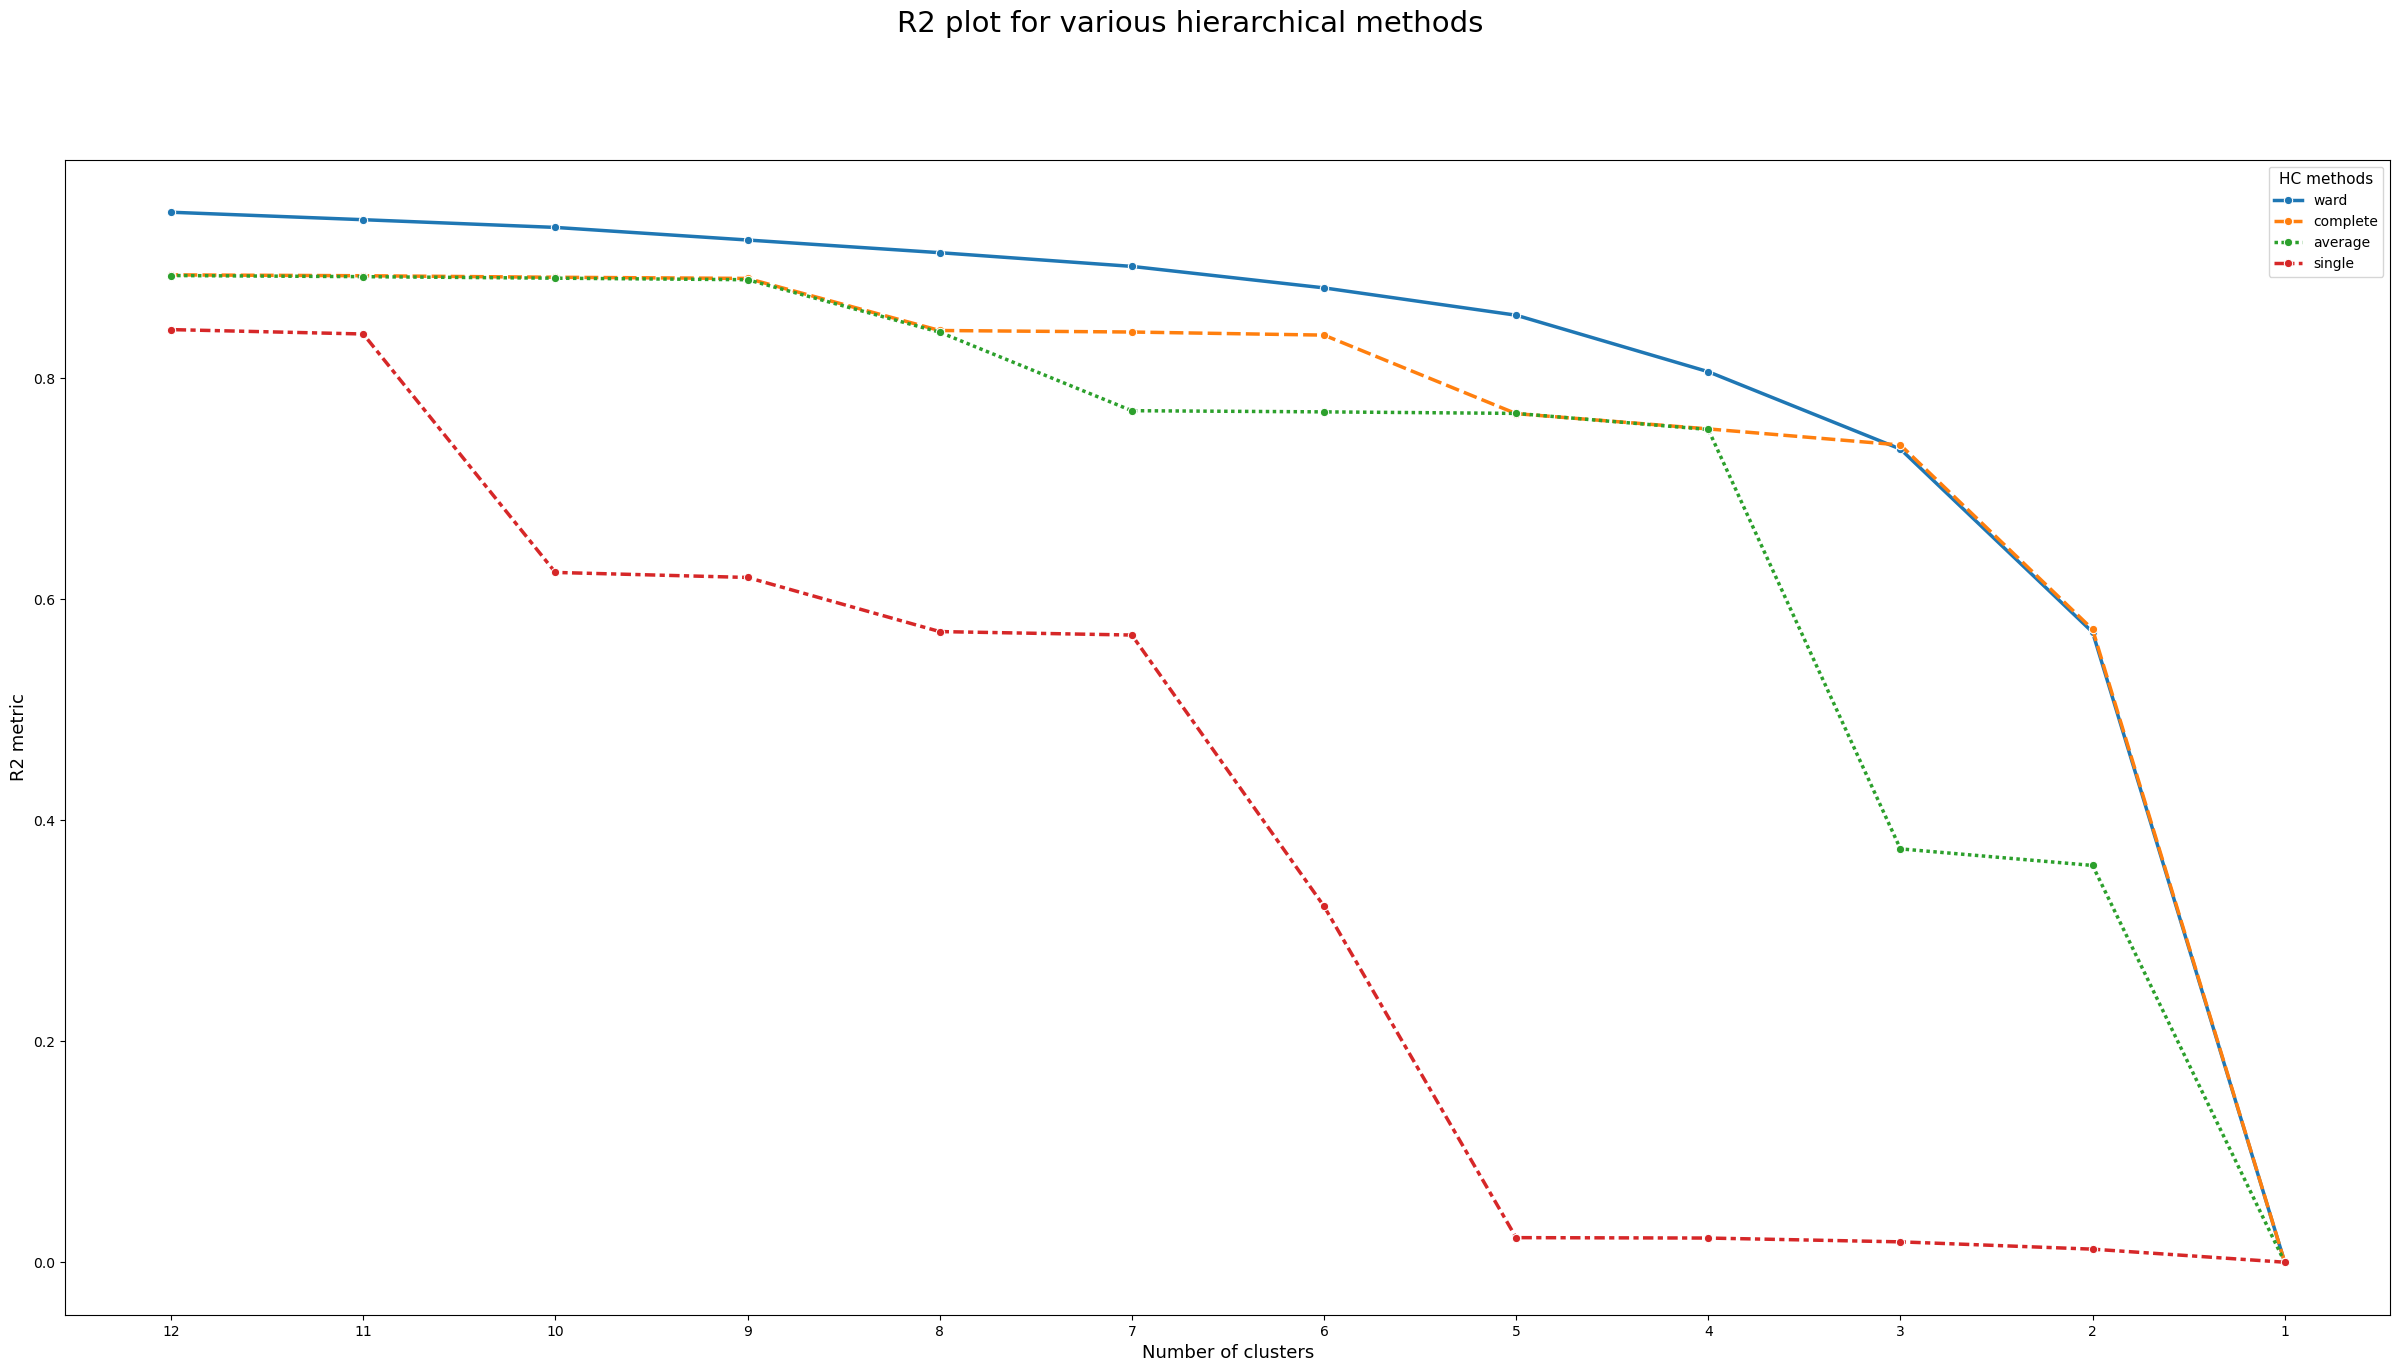

In [8]:
plot_r2_hc(worker_no_scl, max_nclus=12)

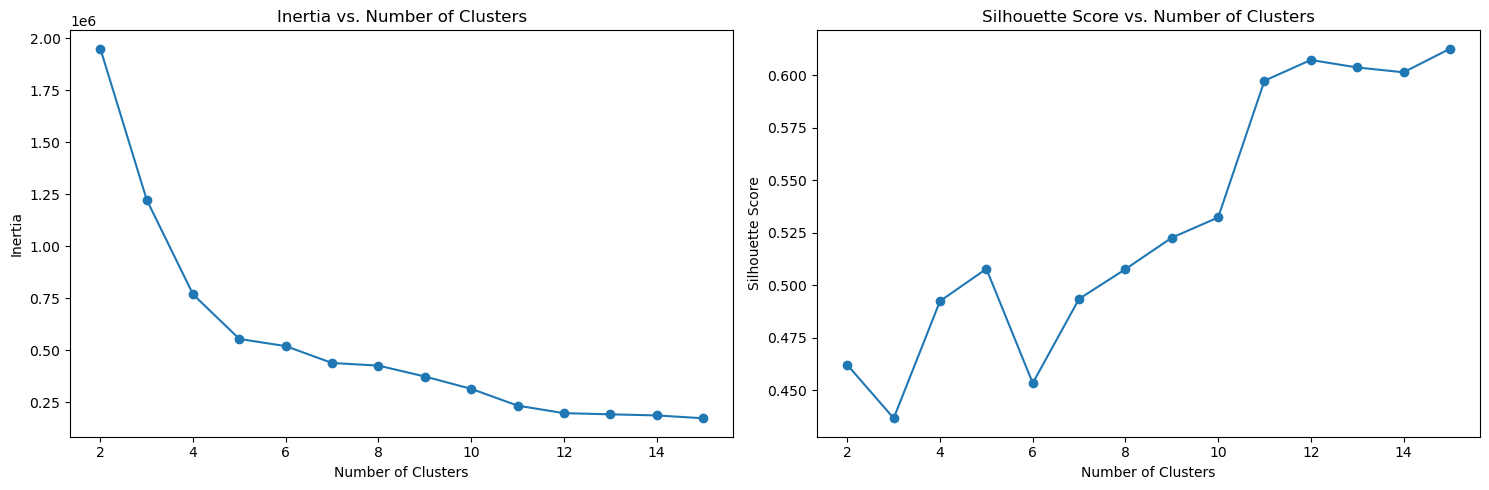

In [9]:
visualize_inertia_silhouette(worker_no_scl)

In [10]:
kmeans = KMeans(n_clusters = 5, random_state = 0).fit(worker_no_scl)
worker['no_kmeans5'] = kmeans.predict(worker_no_scl)

In [11]:
calculate_group_means(worker, 'no_kmeans5')

no_kmeans5,0,1,2,3,4
Age,36.710183,42.041237,30.513889,35.846890,33.102564
Transportation expense,252.462141,118.000000,358.583333,179.550239,155.358974
Distance from Residence to Work,29.297650,11.257732,33.361111,40.913876,14.692308
Service time,12.031332,13.288660,6.500000,15.205742,12.564103
Years until retirement,28.154047,22.958763,34.486111,29.224880,31.897436
Disciplinary failure,0.070496,0.061856,0.111111,0.009569,0.025641
Number of children,1.501305,0.422680,1.305556,0.291866,1.641026
Social drinker,0.558747,0.402062,0.611111,0.583732,1.000000
Social smoker,0.044386,0.020619,0.111111,0.105263,0.179487
Number of pets,1.125326,0.082474,1.944444,0.081340,0.000000


0. **Generalist Mid-Age Workforce**

1. **Veteran Local Employees**

2. **Lifestyle-Constrained Young Employees**

3. **Stable Professional Core**

4. **Physically Strained High-Risk Employees**


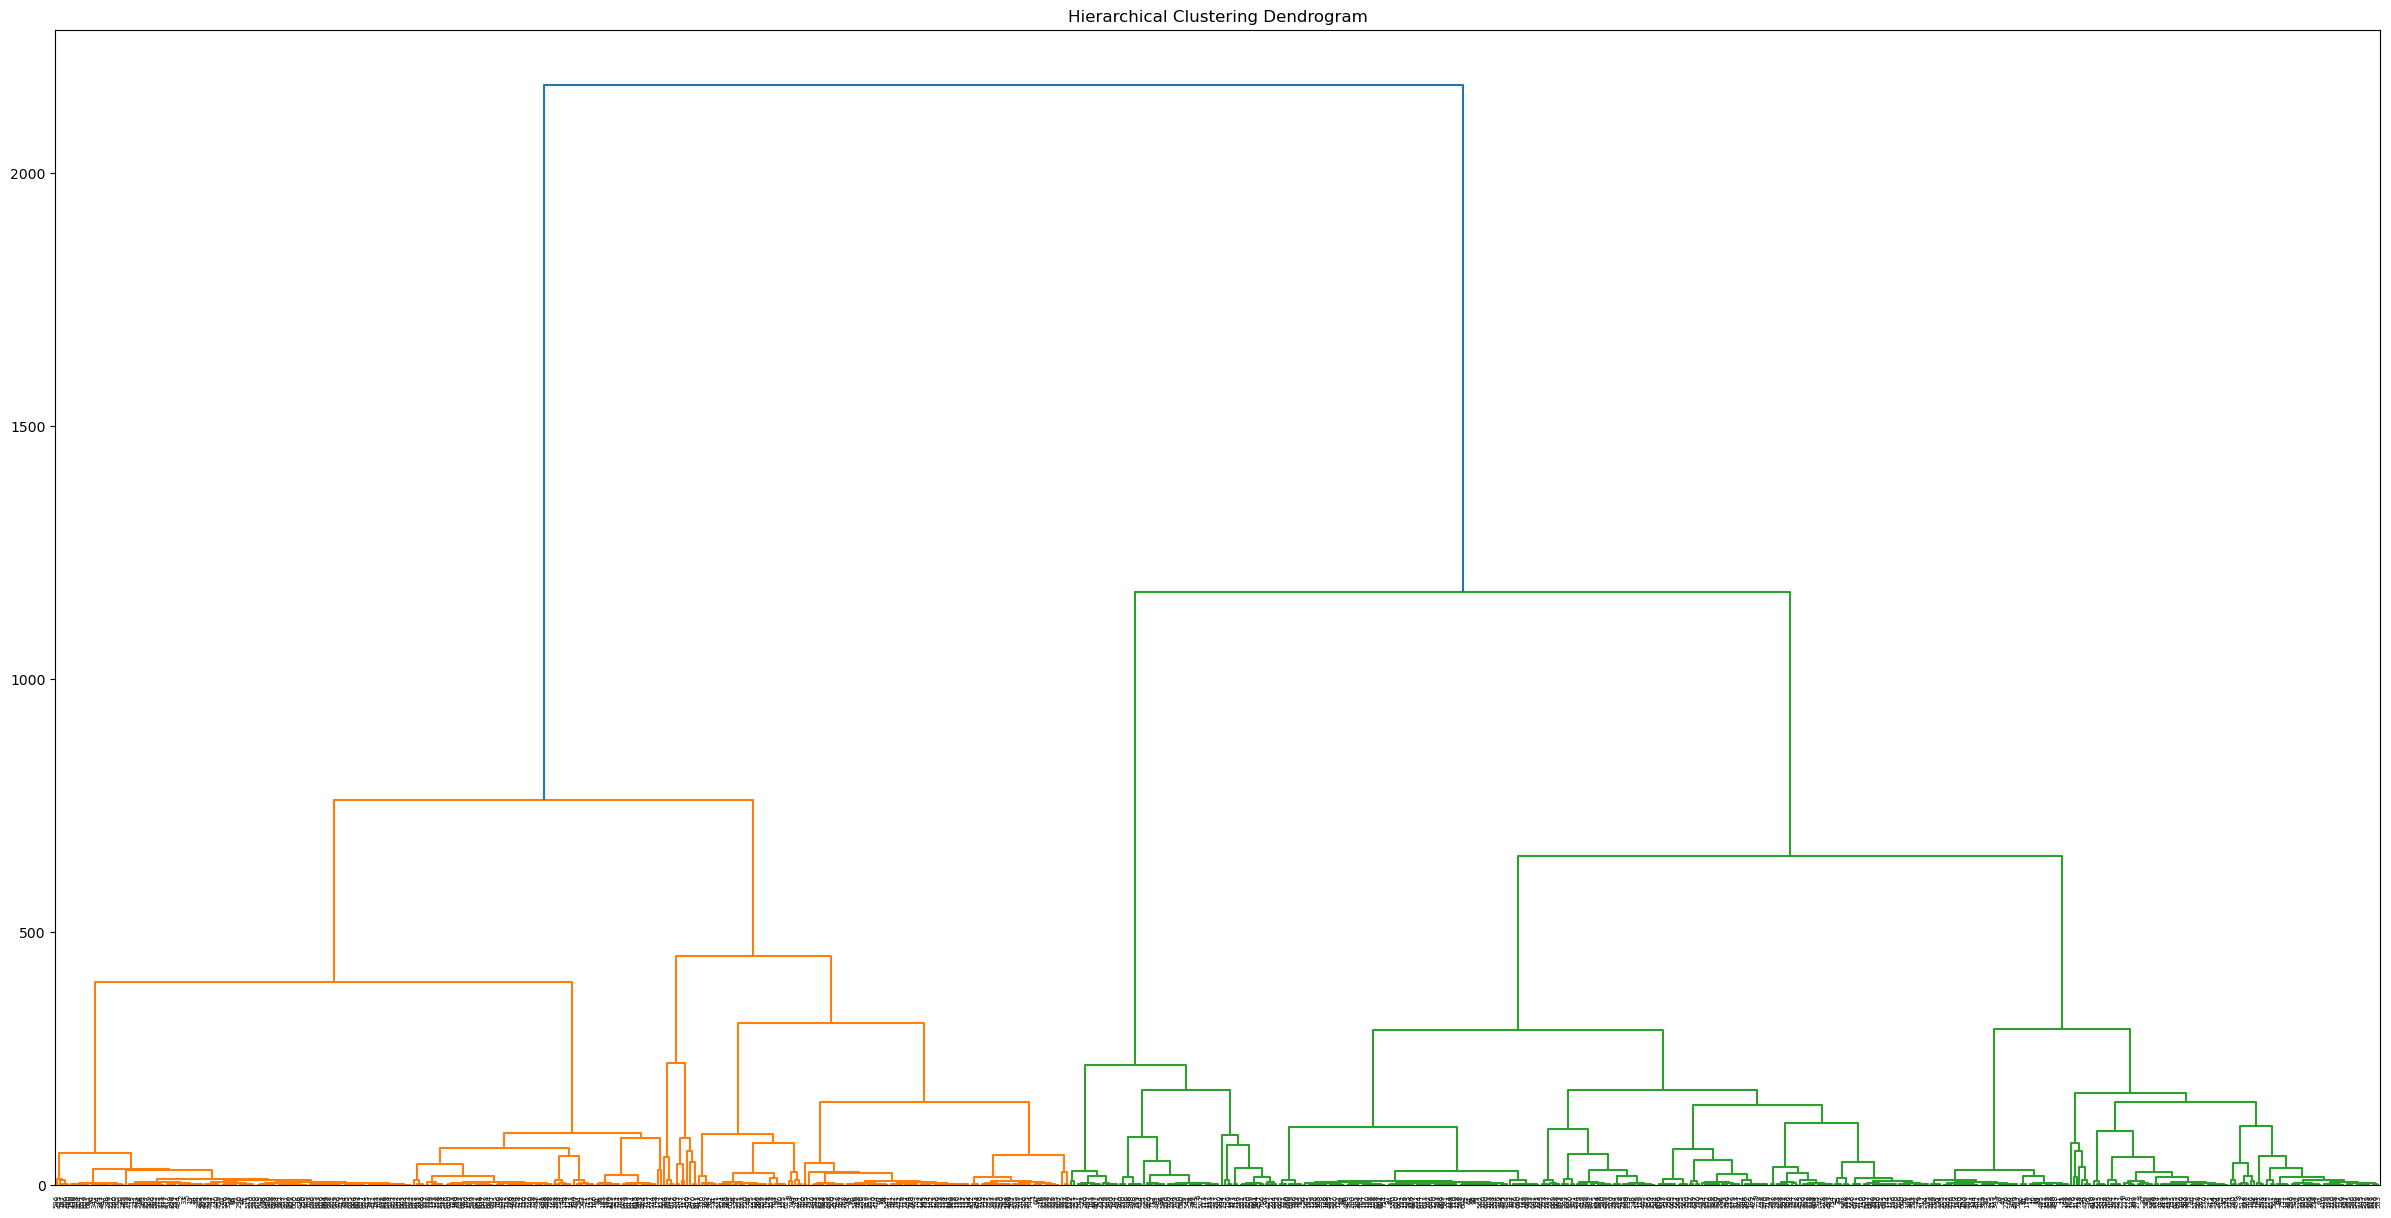

In [14]:
create_dendrogram(worker_no_scl, 'ward')

In [15]:
worker['no_ward5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(worker_no_scl)

In [16]:
calculate_group_means(worker, 'no_ward5')

no_ward5,0,1,2,3,4
Age,39.792857,35.846890,30.513889,36.825806,36.383929
Transportation expense,131.528571,179.550239,358.583333,279.761290,234.022321
Distance from Residence to Work,12.378571,40.913876,33.361111,37.877419,23.580357
Service time,13.114286,15.205742,6.500000,12.535484,11.642857
Years until retirement,25.207143,29.224880,34.486111,28.174194,28.383929
Disciplinary failure,0.050000,0.009569,0.111111,0.090323,0.058036
Number of children,0.800000,0.291866,1.305556,2.245161,0.982143
Social drinker,0.557143,0.583732,0.611111,0.948387,0.299107
Social smoker,0.064286,0.105263,0.111111,0.070968,0.026786
Number of pets,0.092857,0.081340,1.944444,0.632258,1.464286


0. **Veteran Local High-Absence Employees**

1. **Stable Long-Distance Professionals**

2. **Young Lifestyle-Constrained Employees**

3. **Family-Oriented Social Workforce**

4. **Balanced Mid-Career Employees**


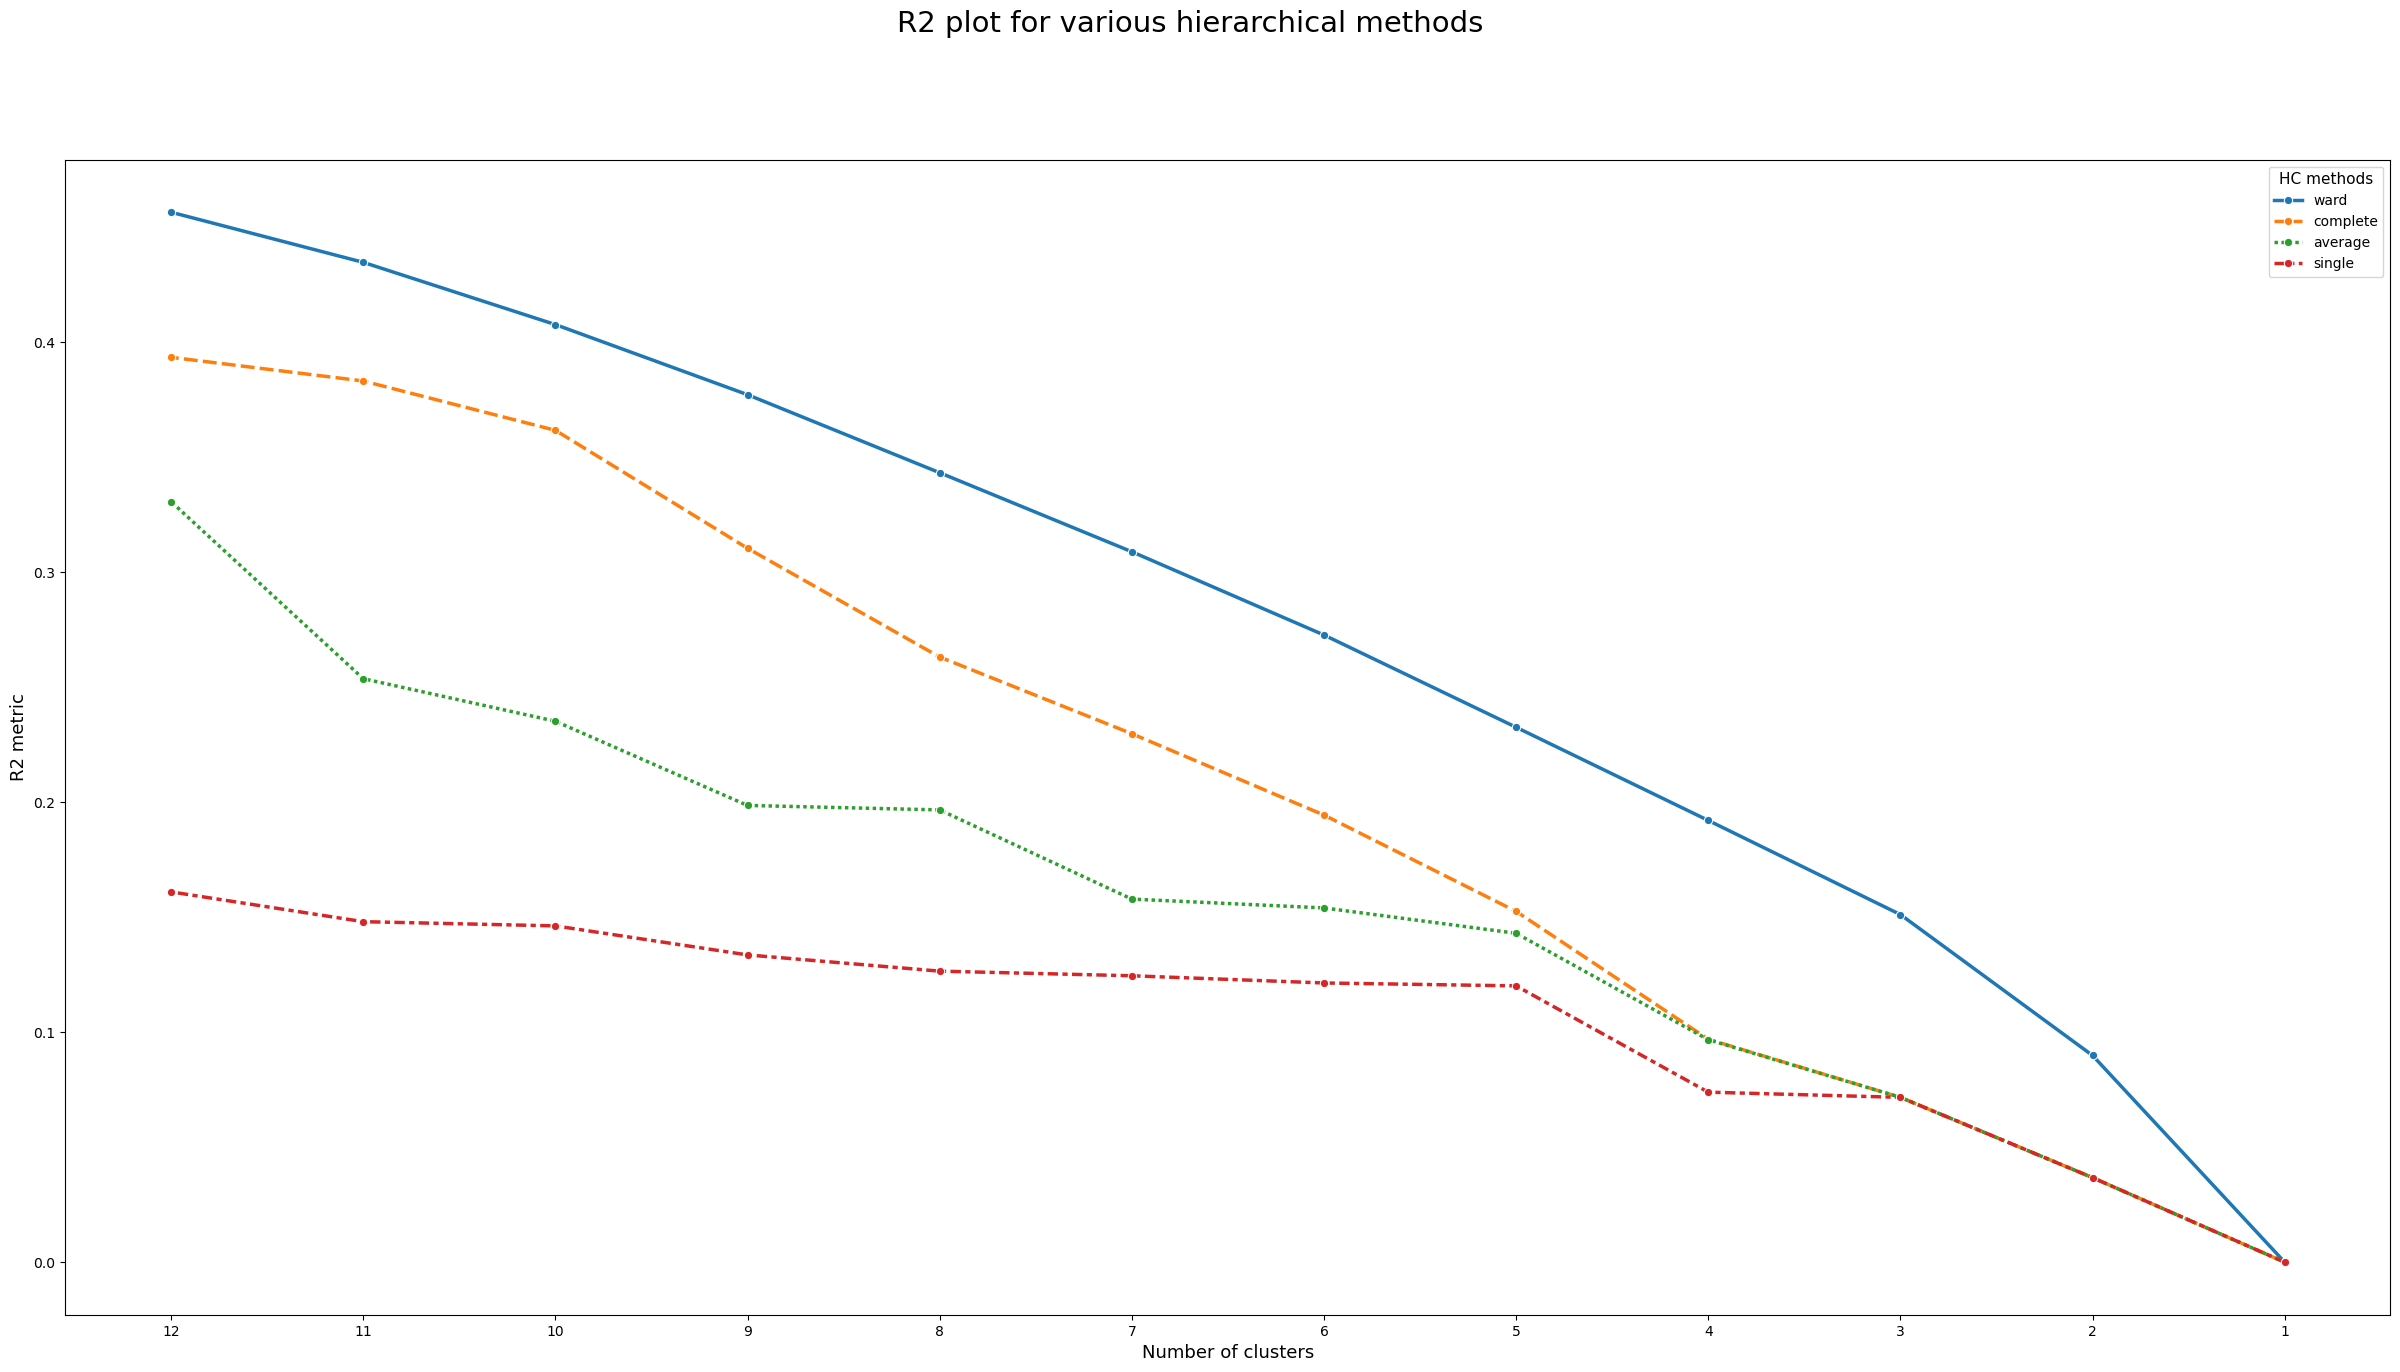

In [12]:
plot_r2_hc(worker_st_scl, max_nclus=12)

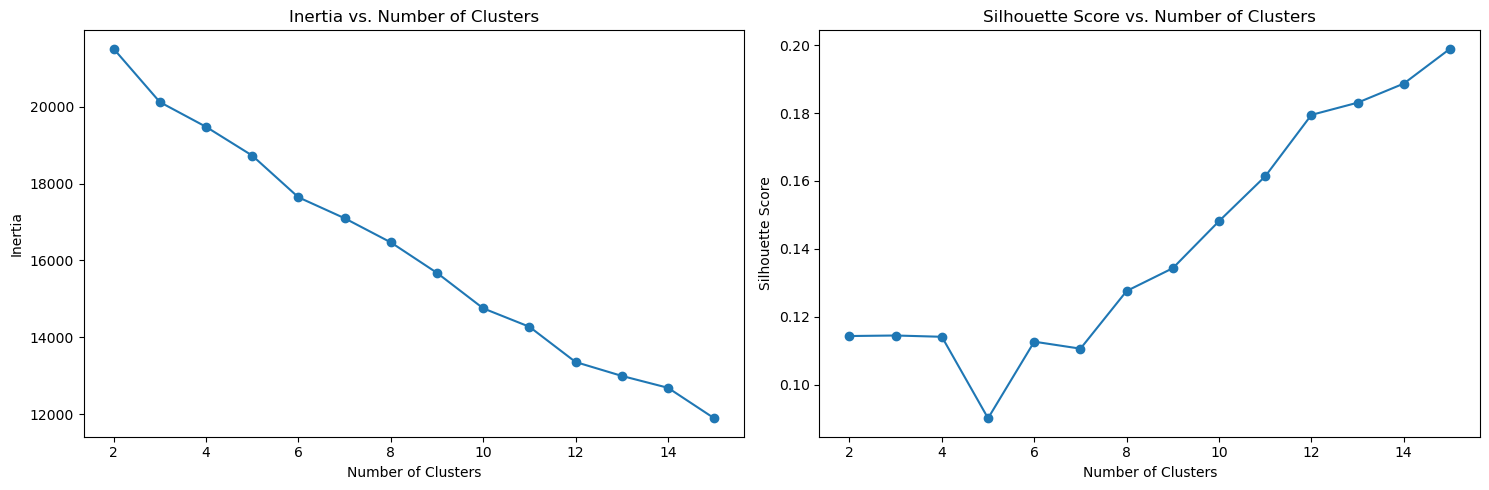

In [13]:
visualize_inertia_silhouette(worker_st_scl)

In [17]:
kmeans = KMeans(n_clusters = 8, random_state = 0).fit(worker_st_scl)
worker['st_kmeans8'] = kmeans.predict(worker_st_scl)

In [18]:
calculate_group_means(worker, 'st_kmeans8')

st_kmeans8,0,1,2,3,4,5,6,7
Age,44.563025,35.365591,31.637255,38.534483,31.333333,28.684615,40.632258,35.394161
Transportation expense,241.369748,133.666667,224.519608,243.258621,233.000000,252.615385,165.619355,288.094891
Distance from Residence to Work,23.369748,11.967742,19.382353,25.827586,32.500000,34.276923,42.664516,38.000000
Service time,15.193277,11.075269,9.254902,13.706897,10.000000,7.461538,18.000000,11.941606
Years until retirement,20.563025,29.634409,33.362745,25.568966,33.666667,36.315385,24.367742,29.605839
Disciplinary failure,0.100840,0.010753,0.039216,0.051724,0.000000,0.023077,0.051613,0.094891
Number of children,1.201681,0.688172,0.235294,1.413793,1.000000,1.030769,0.219355,2.540146
Social drinker,0.478992,0.419355,0.000000,0.551724,0.333333,0.276923,1.000000,1.000000
Social smoker,0.260504,0.075269,0.000000,0.258621,0.000000,0.023077,0.000000,0.000000
Number of pets,0.672269,0.000000,0.235294,0.948276,0.666667,2.784615,0.000000,0.518248


0. **Veteran Physically Strained Employees**

1. **Local Overweight Stable Workforce**

2. **Young Highly Educated Professionals**

3. **Seasonal Long-Term Employees**

4. **Saturday-Oriented Low-Absence Workers**

5. **Young Pet-Oriented Lifestyle Employees**

6. **Experienced Reliable Workforce**

7. **Family-Oriented Commuter Employees**


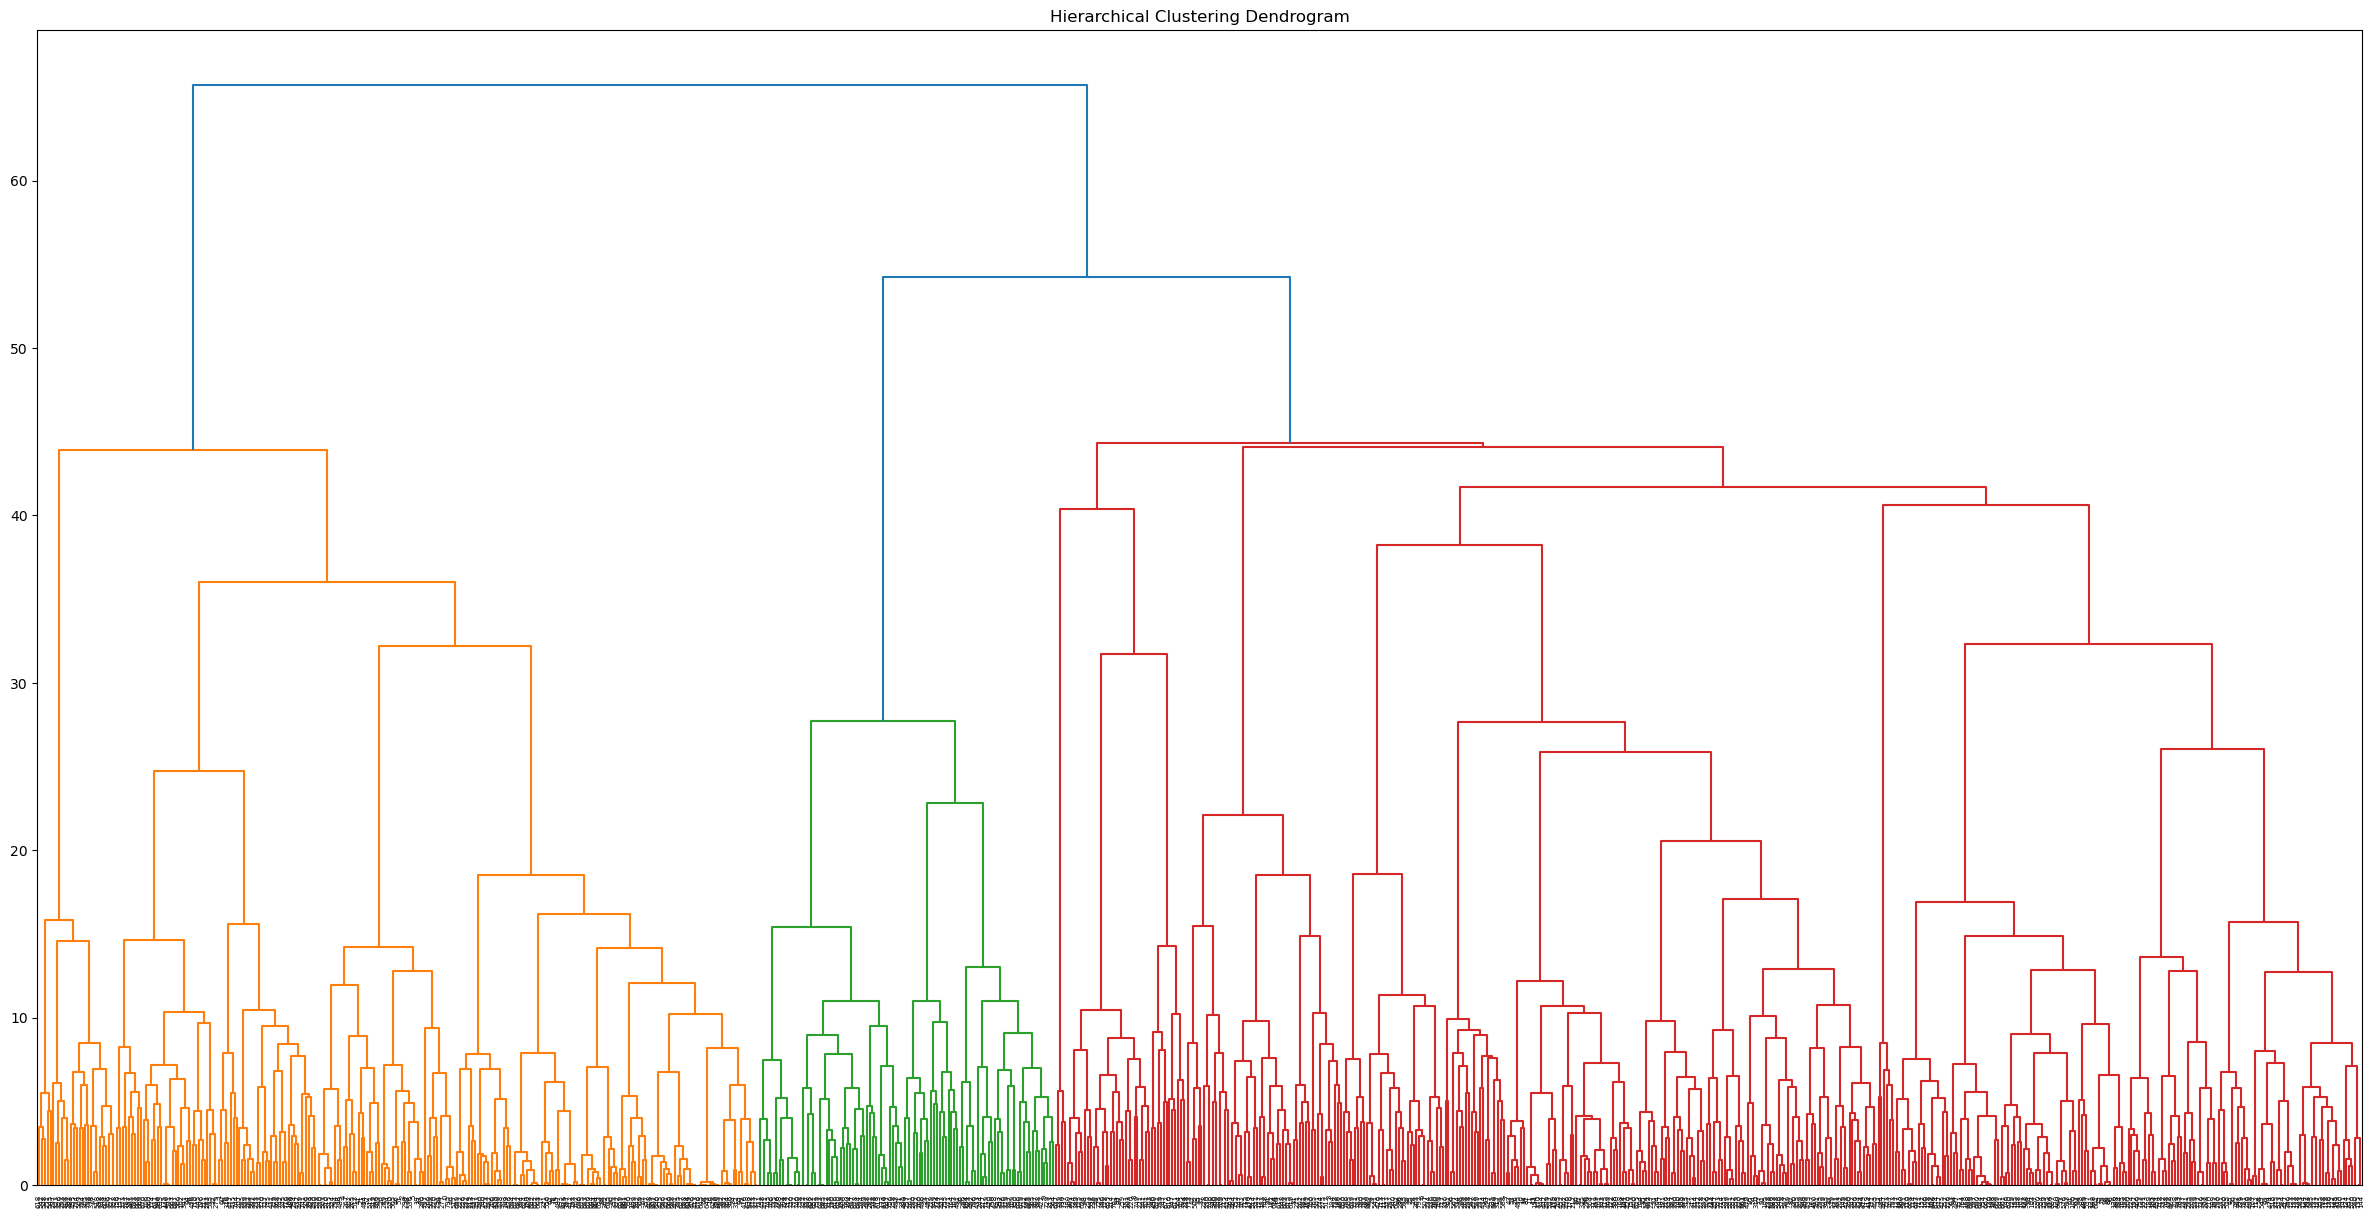

In [14]:
create_dendrogram(worker_st_scl, 'ward')

In [19]:
worker['st_ward8'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 8
    ).fit_predict(worker_st_scl)

In [20]:
calculate_group_means(worker, 'st_ward8')

st_ward8,0,1,2,3,4,5,6,7
Age,35.911111,41.334842,34.945652,32.341615,39.481481,43.814815,31.637255,31.333333
Transportation expense,172.911111,194.665158,289.902174,186.627329,230.462963,244.703704,224.519608,233.000000
Distance from Residence to Work,13.422222,37.855204,38.961957,21.248447,25.870370,26.296296,19.382353,32.500000
Service time,14.311111,16.714932,10.478261,9.795031,13.944444,16.037037,9.254902,10.000000
Years until retirement,27.933333,23.665158,30.135870,32.658385,25.518519,21.185185,33.362745,33.666667
Disciplinary failure,0.000000,0.031674,0.114130,0.000000,0.111111,0.222222,0.039216,0.000000
Number of children,1.933333,0.624434,2.000000,0.608696,1.666667,0.888889,0.235294,1.000000
Social drinker,0.911111,0.832579,0.972826,0.074534,0.333333,0.814815,0.000000,0.333333
Social smoker,0.000000,0.000000,0.010870,0.000000,1.000000,0.000000,0.000000,0.000000
Number of pets,0.311111,0.294118,1.266304,1.086957,1.240741,0.518519,0.235294,0.666667


0. **High-Absence Physically Strained Employees**

1. **Stable Local Overweight Workforce**

2. **Family-Oriented Long-Distance Employees**

3. **Low-Risk Young Stable Employees**

4. **Moderate Absenteeism Balanced Workforce**

5. **Severely Obese High-Risk Employees**

6. **Young Highly Educated Professionals**

7. **Saturday-Oriented Young Workforce**


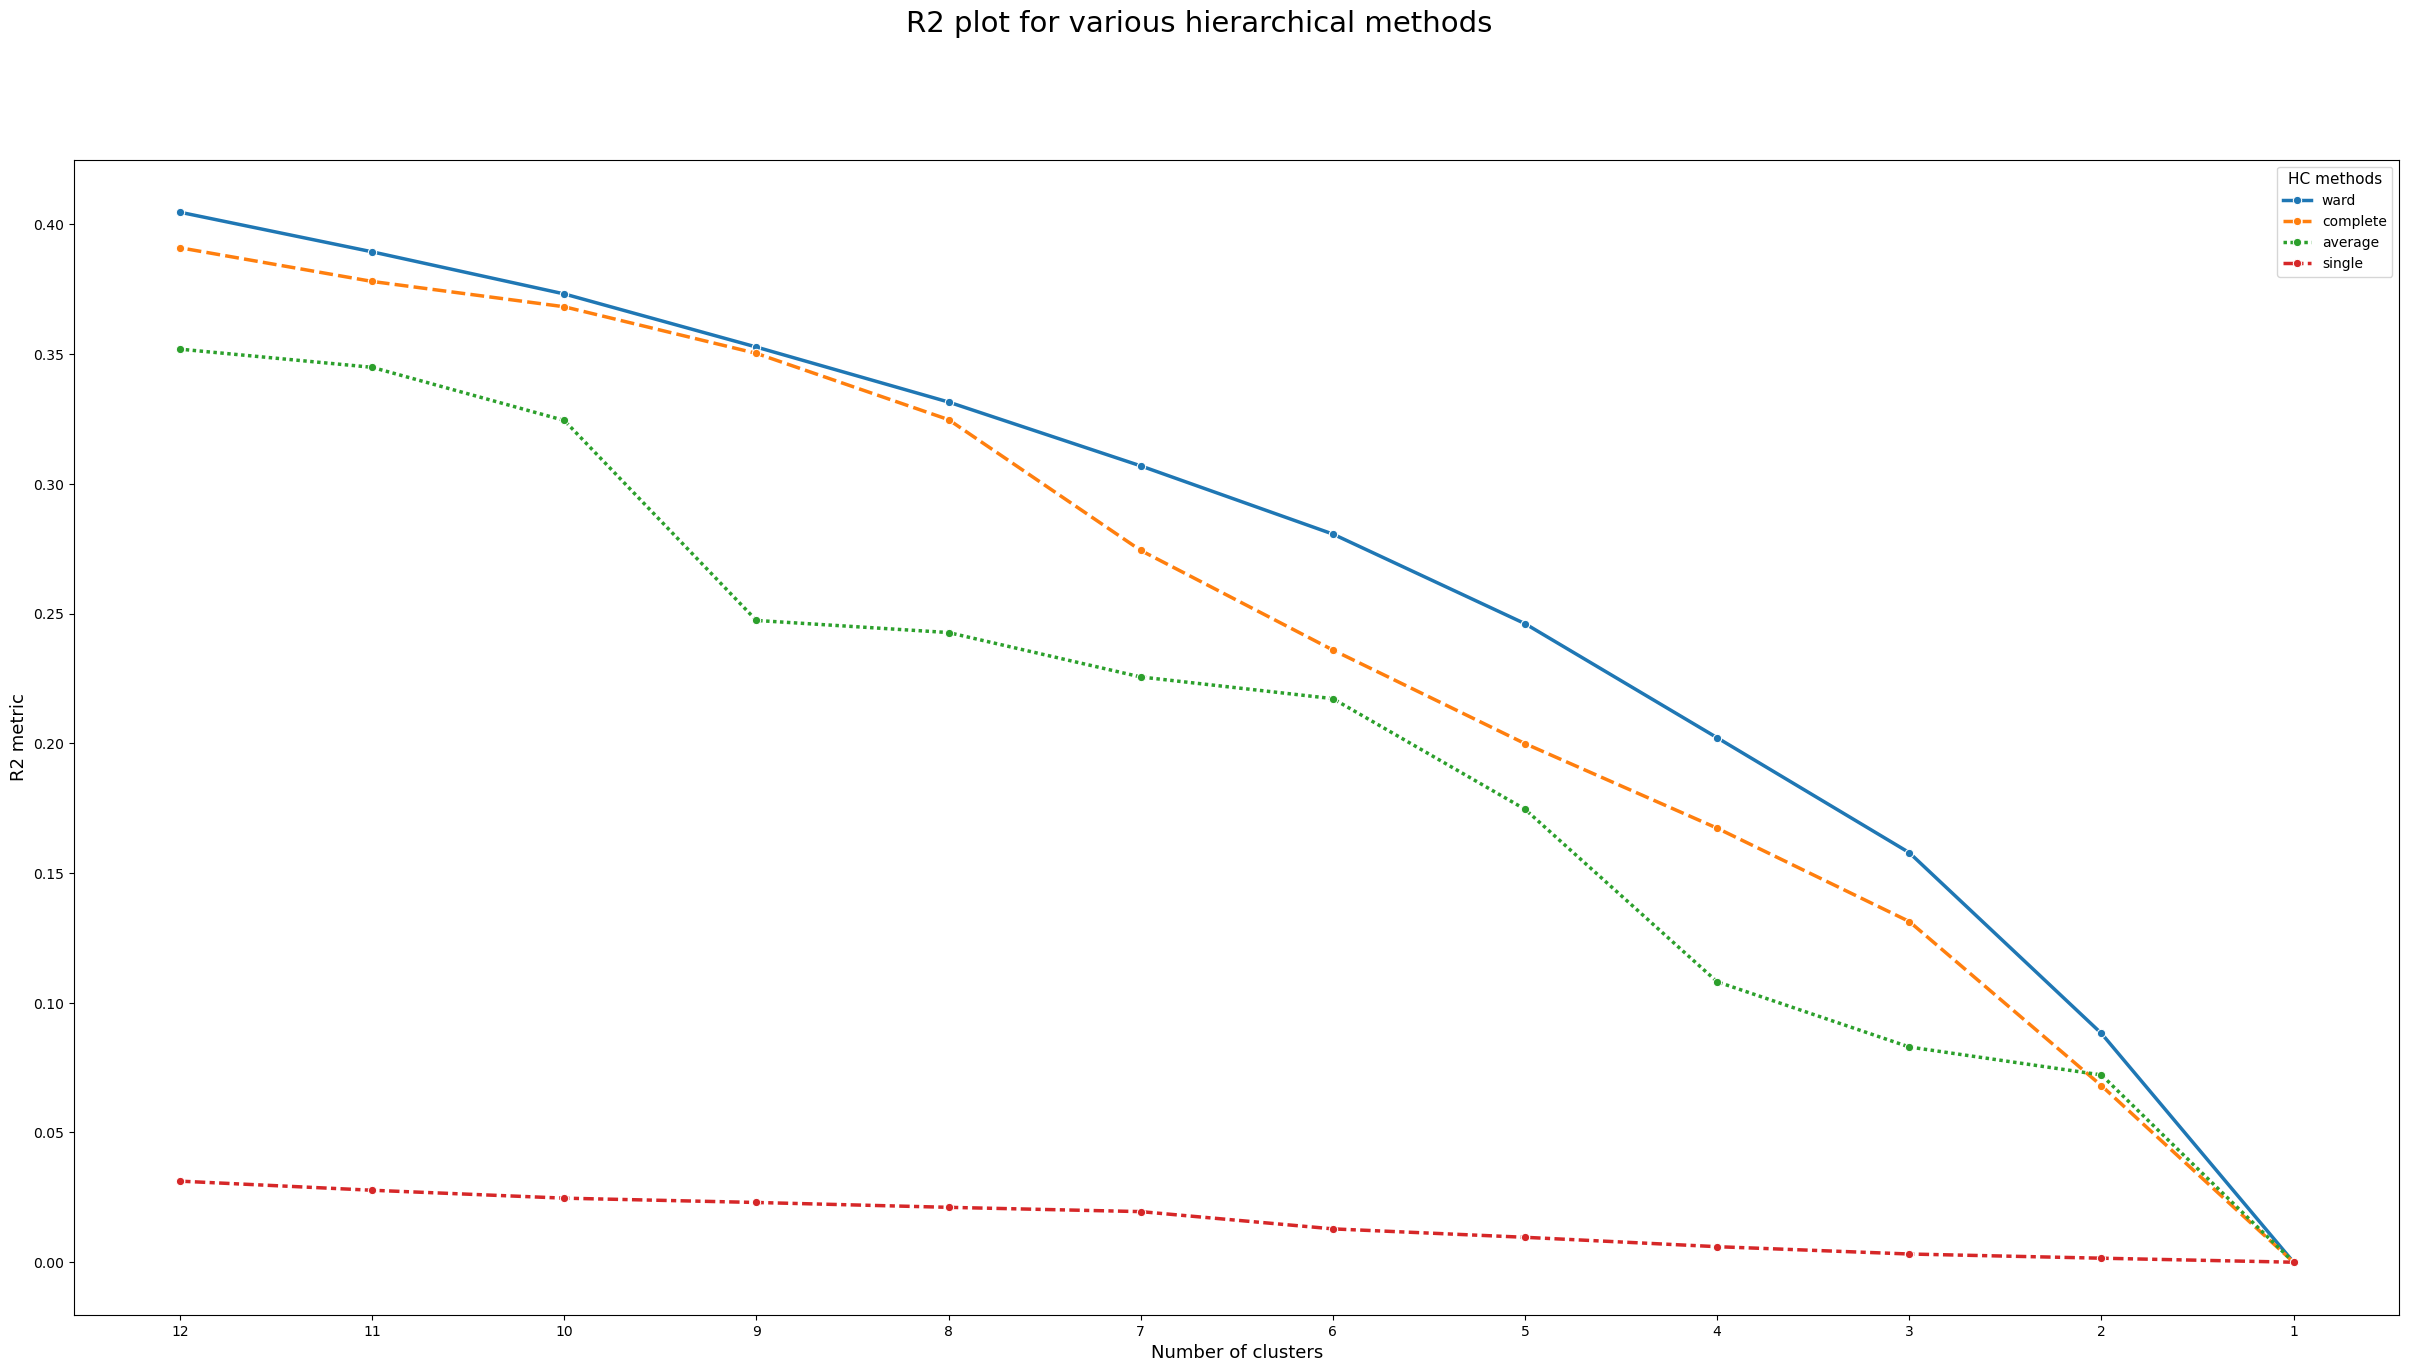

In [15]:
plot_r2_hc(worker_mm_scl, max_nclus=12)

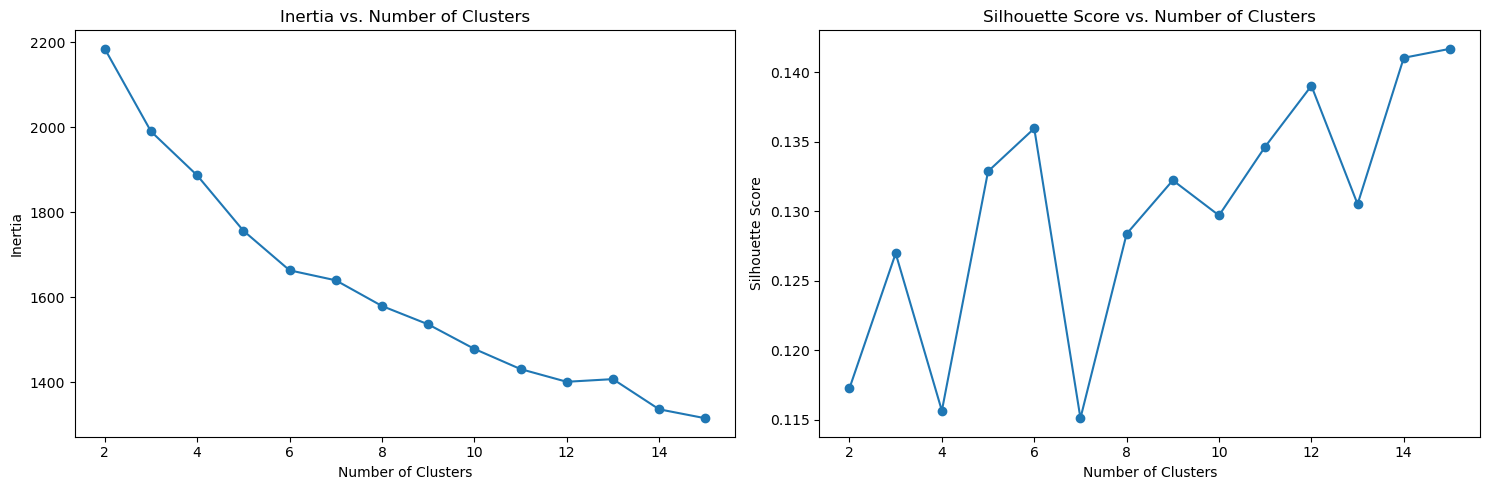

In [16]:
visualize_inertia_silhouette(worker_mm_scl)

In [21]:
kmeans = KMeans(n_clusters = 6, random_state = 0).fit(worker_mm_scl)
worker['mm_kmeans6'] = kmeans.predict(worker_mm_scl)

In [22]:
calculate_group_means(worker, 'mm_kmeans6')

mm_kmeans6,0,1,2,3,4,5
Age,36.099379,38.043478,36.652542,33.184211,40.000000,33.651852
Transportation expense,264.534161,216.400000,232.398305,210.219298,199.796178,202.296296
Distance from Residence to Work,31.391304,29.286957,32.347458,20.201754,39.700637,22.696296
Service time,11.403727,13.313043,12.093220,10.842105,16.496815,10.466667
Years until retirement,28.739130,26.730435,28.347458,31.815789,25.000000,31.459259
Disciplinary failure,0.093168,0.052174,0.033898,0.026316,0.070064,0.037037
Number of children,1.919255,1.095652,1.042373,0.543860,0.745223,0.725926
Social drinker,1.000000,0.713043,0.677966,0.000000,0.859873,0.000000
Social smoker,0.055901,0.104348,0.076271,0.166667,0.025478,0.022222
Number of pets,0.807453,0.834783,0.872881,0.210526,0.420382,1.311111


0. **Socially Active Mid-Career Employees**

1. **Stable Winter-Oriented Workforce**

2. **Seasonal Summer Commuters**

3. **Young Educated Low-Risk Professionals**

4. **Physically Strained High-BMI Employees**

5. **Young Pet-Oriented Reliable Employees**


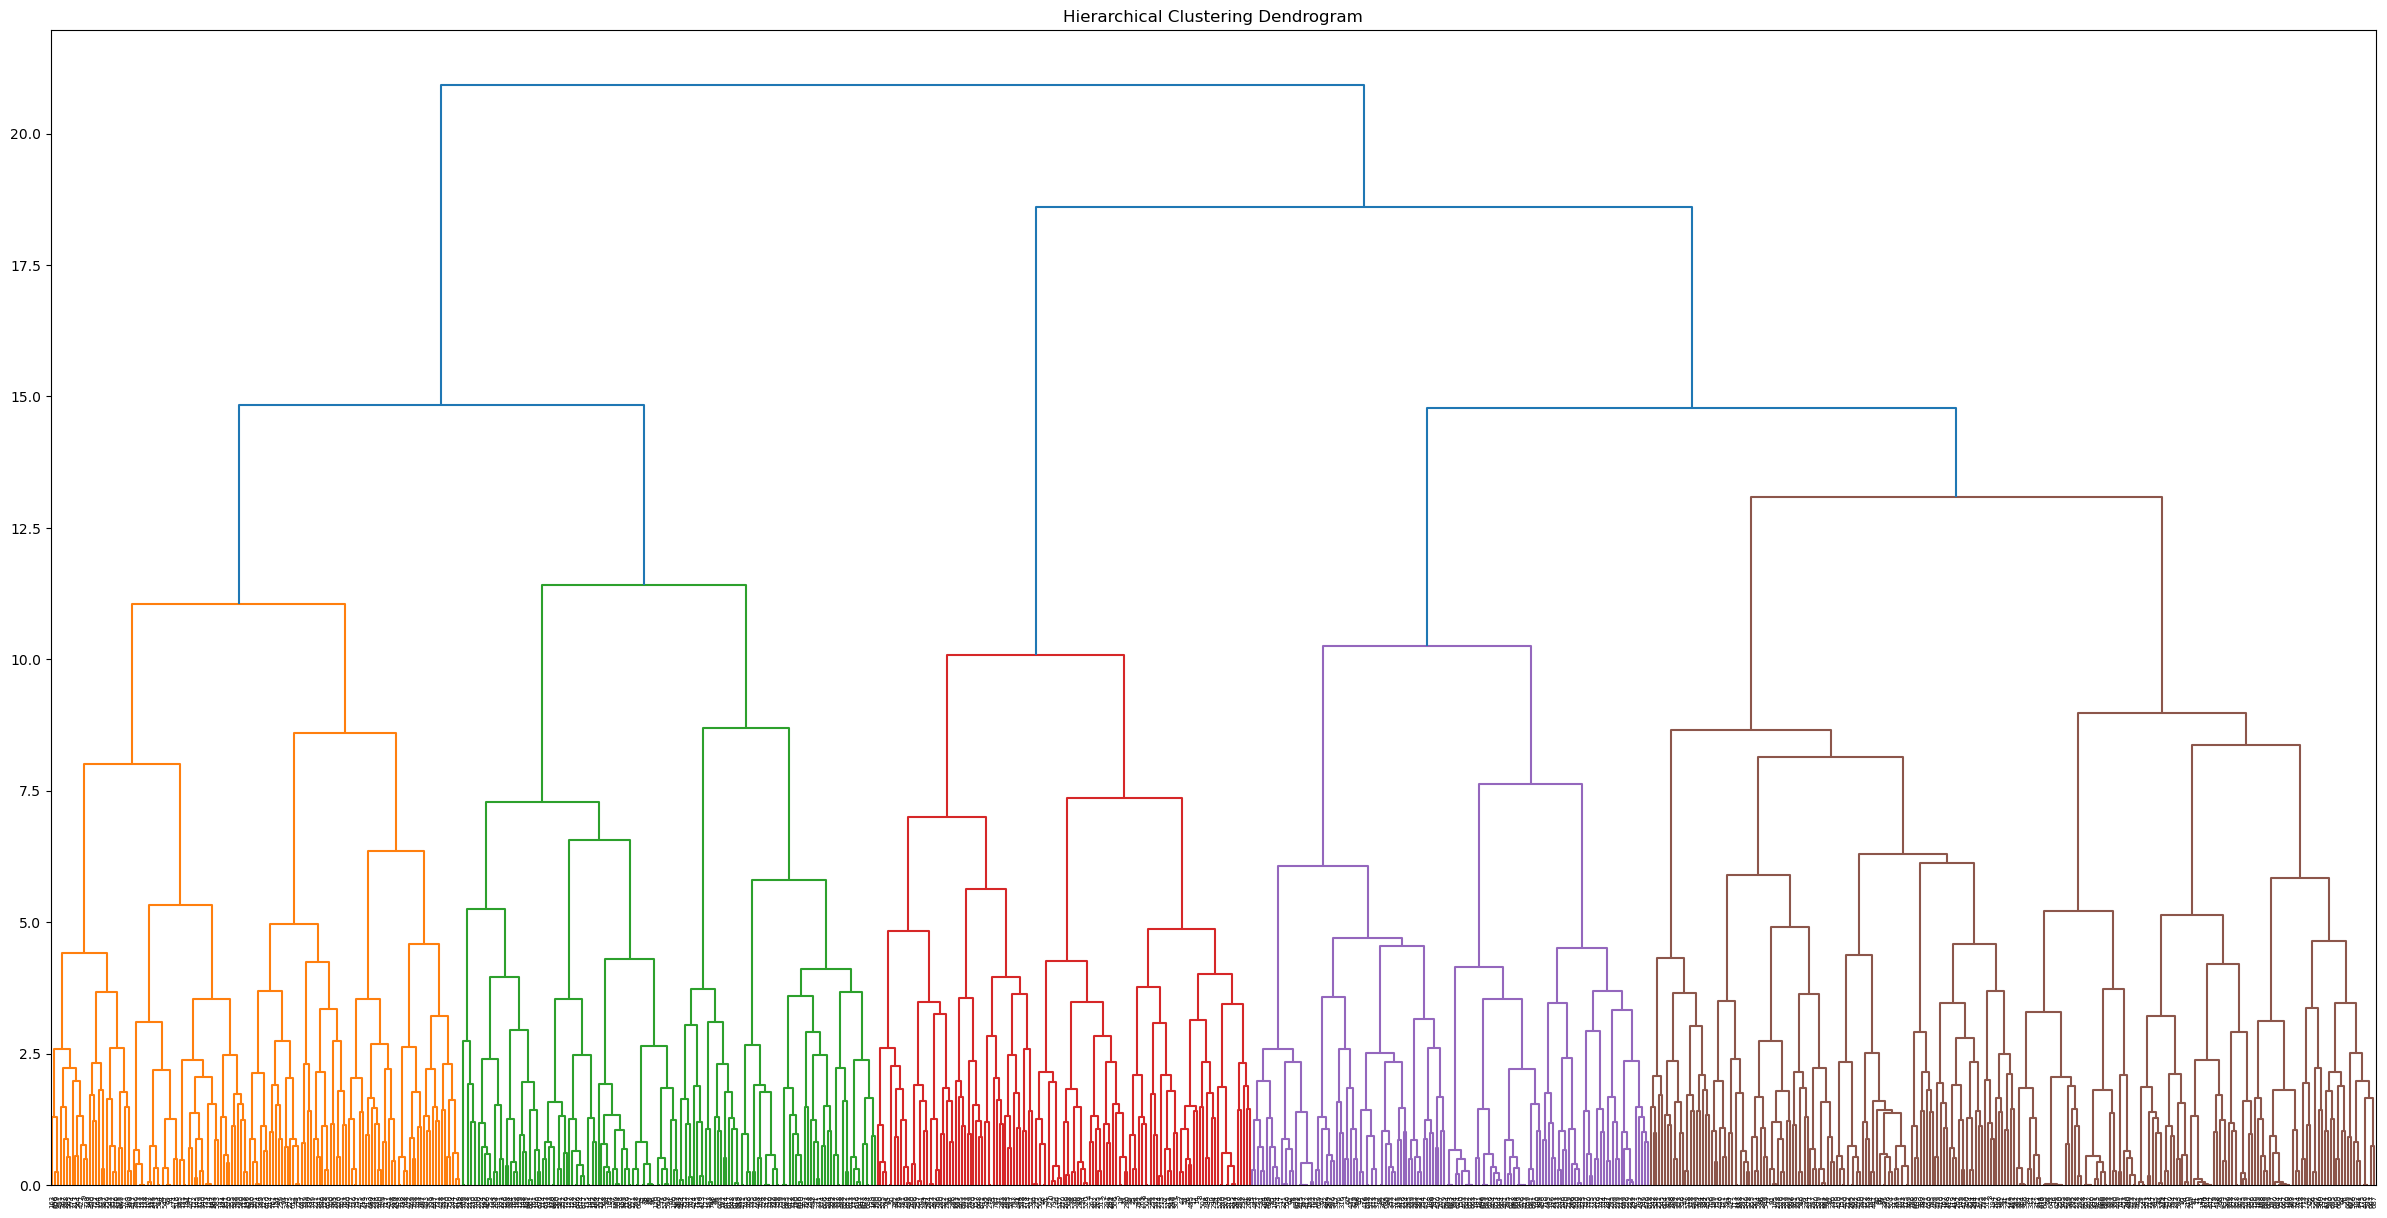

In [17]:
create_dendrogram(worker_mm_scl, 'ward')

In [23]:
worker['mm_ward8'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 8
    ).fit_predict(worker_mm_scl)

In [24]:
calculate_group_means(worker, 'mm_ward8')

mm_ward8,0,1,2,3,4,5,6,7
Age,40.576642,37.830645,37.736434,34.054795,33.000000,37.134921,28.986667,35.544118
Transportation expense,186.277372,244.951613,234.759690,211.287671,182.602941,270.976190,229.373333,179.073529
Distance from Residence to Work,37.846715,35.572581,30.155039,18.383562,25.161765,34.341270,27.973333,12.867647
Service time,17.021898,13.225806,12.480620,11.643836,11.382353,11.523810,9.200000,10.073529
Years until retirement,24.423358,27.169355,27.263566,30.232877,32.000000,27.865079,36.013333,29.676471
Disciplinary failure,0.065693,0.080645,0.038760,0.027397,0.000000,0.103175,0.040000,0.029412
Number of children,0.613139,1.370968,1.062016,1.301370,0.632353,1.674603,1.013333,0.279412
Social drinker,0.956204,0.661290,0.573643,0.671233,0.000000,0.960317,0.013333,0.000000
Social smoker,0.000000,0.048387,0.054264,0.041096,0.308824,0.103175,0.080000,0.000000
Number of pets,0.189781,0.943548,0.767442,0.726027,0.088235,1.047619,1.920000,0.279412


0. **Obese Senior Long-Tenure Employees**

1. **Spring-Oriented Family Workforce**

2. **Seasonal Summer Commuters**

3. **Overweight Long-Distance Professionals**

4. **Highly Educated Lightweight Employees**

5. **Socially Active Mid-Career Employees**

6. **Young Pet-Oriented Workforce**

7. **Stable Local Overweight Employees**


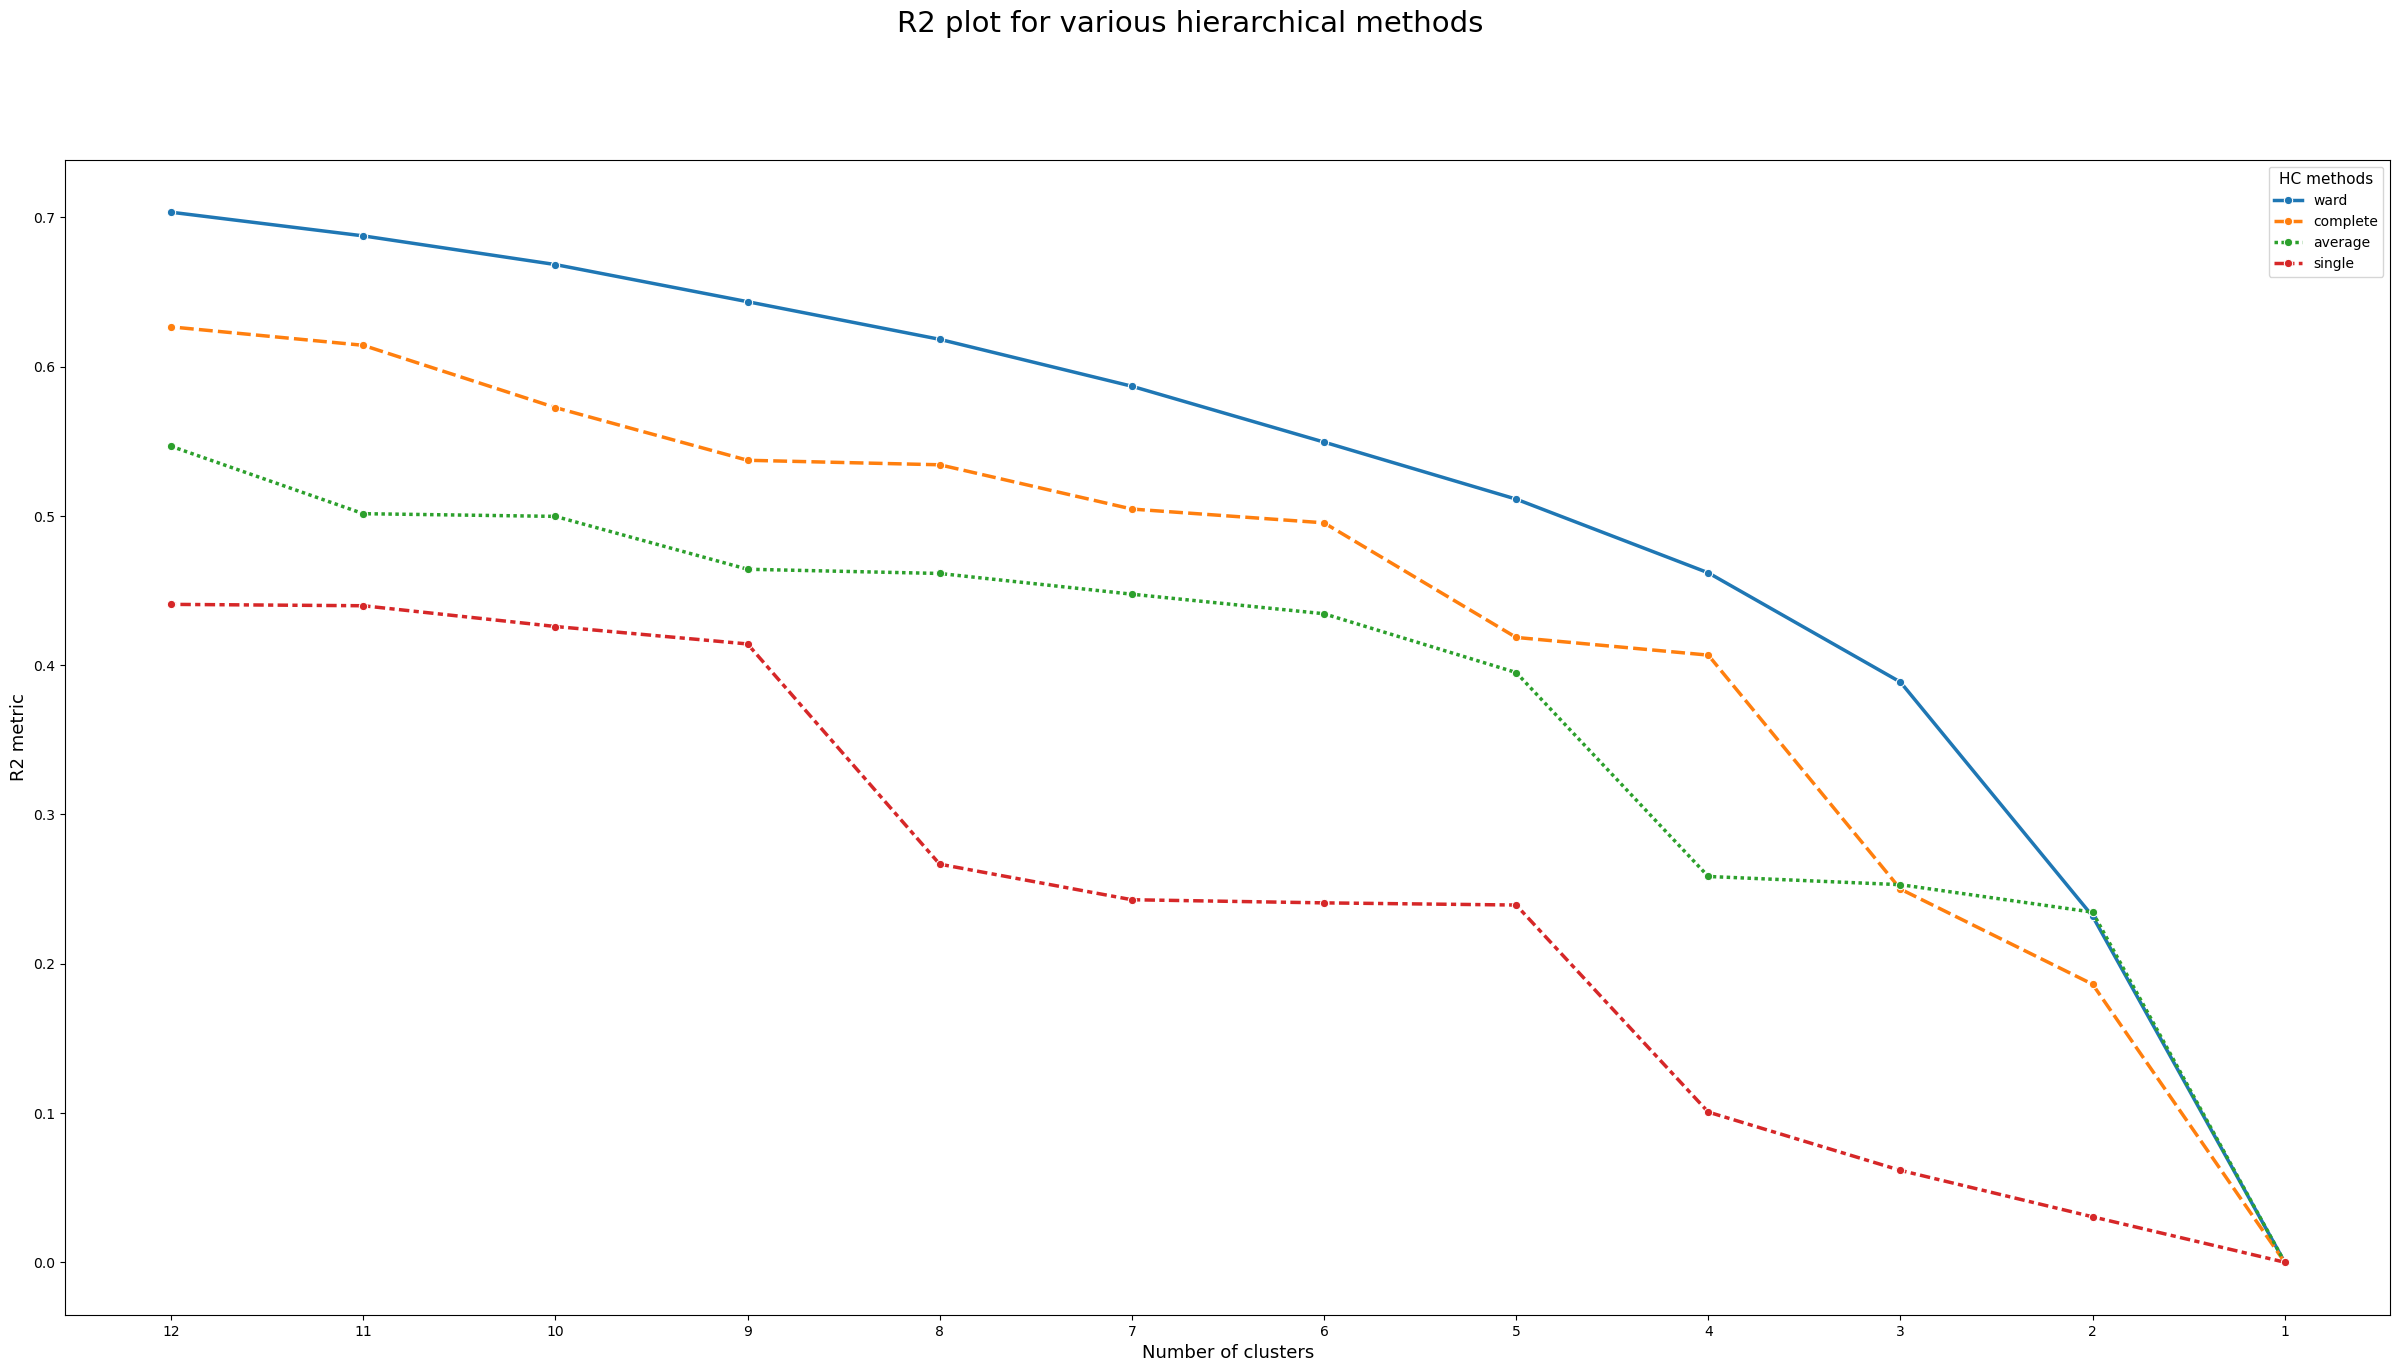

In [18]:
plot_r2_hc(worker_rb_scl, max_nclus=12)

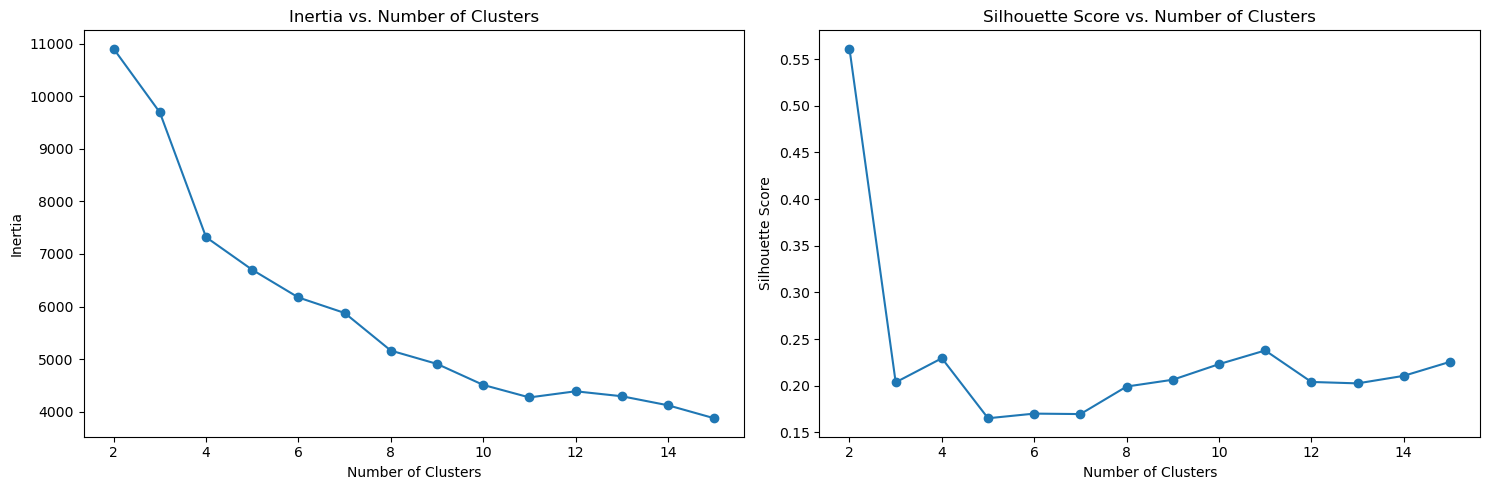

In [19]:
visualize_inertia_silhouette(worker_rb_scl)

In [25]:
kmeans = KMeans(n_clusters = 4, random_state = 0).fit(worker_rb_scl)
worker['rb_kmeans4'] = kmeans.predict(worker_rb_scl)

In [26]:
calculate_group_means(worker, 'rb_kmeans4')

rb_kmeans4,0,1,2,3
Age,38.327645,31.175439,29.857143,41.235294
Transportation expense,214.935154,212.350877,258.035714,197.705882
Distance from Residence to Work,30.539249,15.245614,33.971429,18.705882
Service time,13.860068,10.105263,7.885714,13.588235
Years until retirement,26.697952,32.912281,35.142857,23.764706
Disciplinary failure,0.058020,0.052632,0.050000,0.000000
Number of children,1.000000,1.157895,1.114286,1.588235
Social drinker,0.634812,0.701754,0.257143,0.588235
Social smoker,0.058020,0.122807,0.100000,0.058824
Number of pets,0.271331,0.140351,3.014286,0.411765


0. **Balanced Mid-Career Workforce**

1. **Young Overweight Local Employees**

2. **Young Pet-Oriented Low-Absence Employees**

3. **Older High-Absenteeism Workforce**


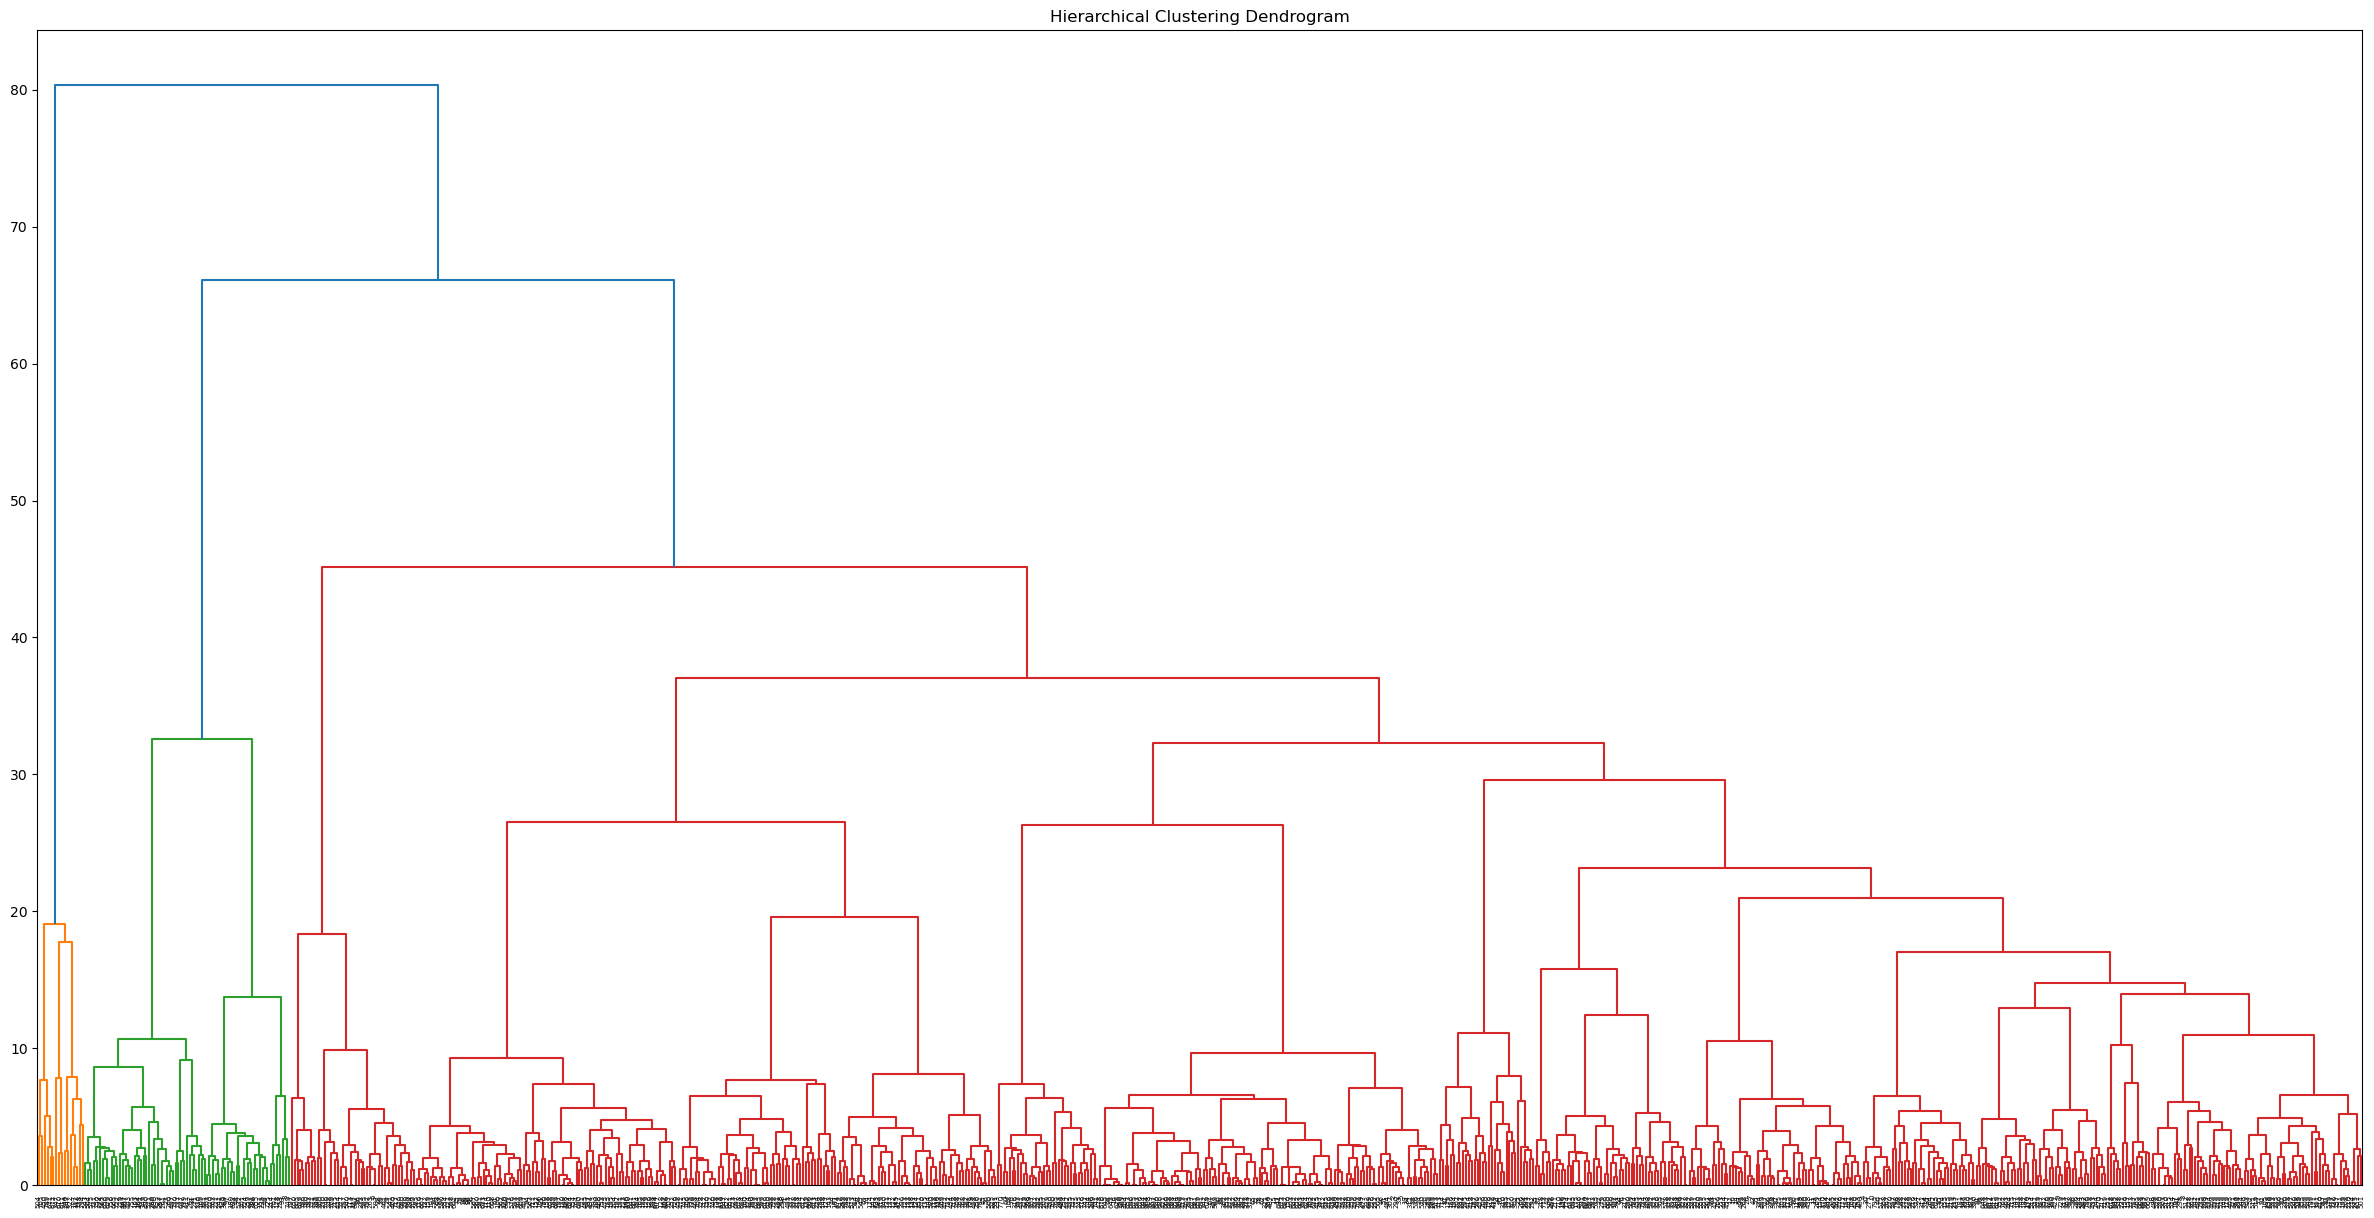

In [20]:
create_dendrogram(worker_rb_scl, 'ward')

In [21]:
worker['rb_ward9'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 9
    ).fit_predict(worker_rb_scl)

In [22]:
worker['rb_ward10'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 10
    ).fit_predict(worker_rb_scl)

In [23]:
worker['rb_ward11'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 11
    ).fit_predict(worker_rb_scl)

In [24]:
calculate_group_means(worker, 'rb_ward10')

rb_ward10,0,1,2,3,4,5,6,7,8,9
Age,39.568421,41.562500,33.309091,30.325581,38.000000,29.571429,34.000000,37.333333,28.444444,49.771429
Transportation expense,262.052632,193.812500,148.818182,334.697674,179.000000,261.857143,155.000000,256.545455,221.800000,118.000000
Distance from Residence to Work,29.326316,16.750000,19.018182,50.372093,51.000000,17.380952,12.000000,32.939394,26.266667,13.114286
Service time,13.543860,13.750000,9.372727,4.348837,18.000000,6.714286,14.000000,13.848485,9.355556,18.342857
Years until retirement,25.484211,23.437500,31.690909,34.674419,27.000000,34.190476,31.000000,27.666667,36.555556,15.228571
Disciplinary failure,0.094737,0.000000,0.000000,0.069767,0.017094,0.095238,0.000000,0.000000,0.022222,0.171429
Number of children,1.814035,1.437500,0.000000,1.186047,0.000000,0.190476,2.000000,1.303030,1.088889,1.057143
Social drinker,0.670175,0.562500,0.000000,0.813953,1.000000,0.261905,1.000000,0.939394,0.000000,1.000000
Social smoker,0.122807,0.062500,0.000000,0.186047,0.000000,0.166667,0.000000,0.090909,0.000000,0.057143
Number of pets,0.631579,0.437500,0.000000,4.837209,0.000000,0.190476,0.000000,0.393939,2.000000,0.000000


0. **Mid-Age Stable Employees**

1. **Employees with Chronic Absenteeism**

2. **Young Low-Burned Preformers**

3. **Pet Lovers Employees**

4. **Long-Distance Commuters with Pet Constraints**

5. **Early-Career Unstable Workers**

6. **Physically Strained Operational Staff**

7. **Socially Driven High-Absence Group**

8. **Healthy Young Reliable Employees**

9. **Veteran Reliable Workforce**

----


# **Dimensionality Reduction for Cluster Visualization (UMAP)**

To facilitate the visual inspection of the clustering results, a non-linear dimensionality reduction technique was applied to project the high-dimensional feature space into two dimensions.

Uniform Manifold Approximation and Projection (UMAP) was used exclusively for **visualization purposes**, allowing the preservation of local neighborhood structure while providing an intuitive representation of cluster separation. Importantly, dimensionality reduction was **not applied prior to clustering**, ensuring that cluster formation remained grounded in the original feature space.

The UMAP embedding is therefore used to visually assess cluster cohesion and separation for the selected clustering solutions.


In [25]:
umap_object = umap.UMAP(n_neighbors = 30, min_dist = 0.15, random_state = 42)

In [26]:
umap_embedding = umap_object.fit_transform(worker_rb_scl)

/Users/franciscogomes/anaconda3/envs/data_mining/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/franciscogomes/Desktop/Faculdade/Master/Data Mining/Project/reasons_for_absenteeism/code/modeling_pipeline.py:180: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=cmap(norm(i)), label=label) for i, label in enumerate(labels)]


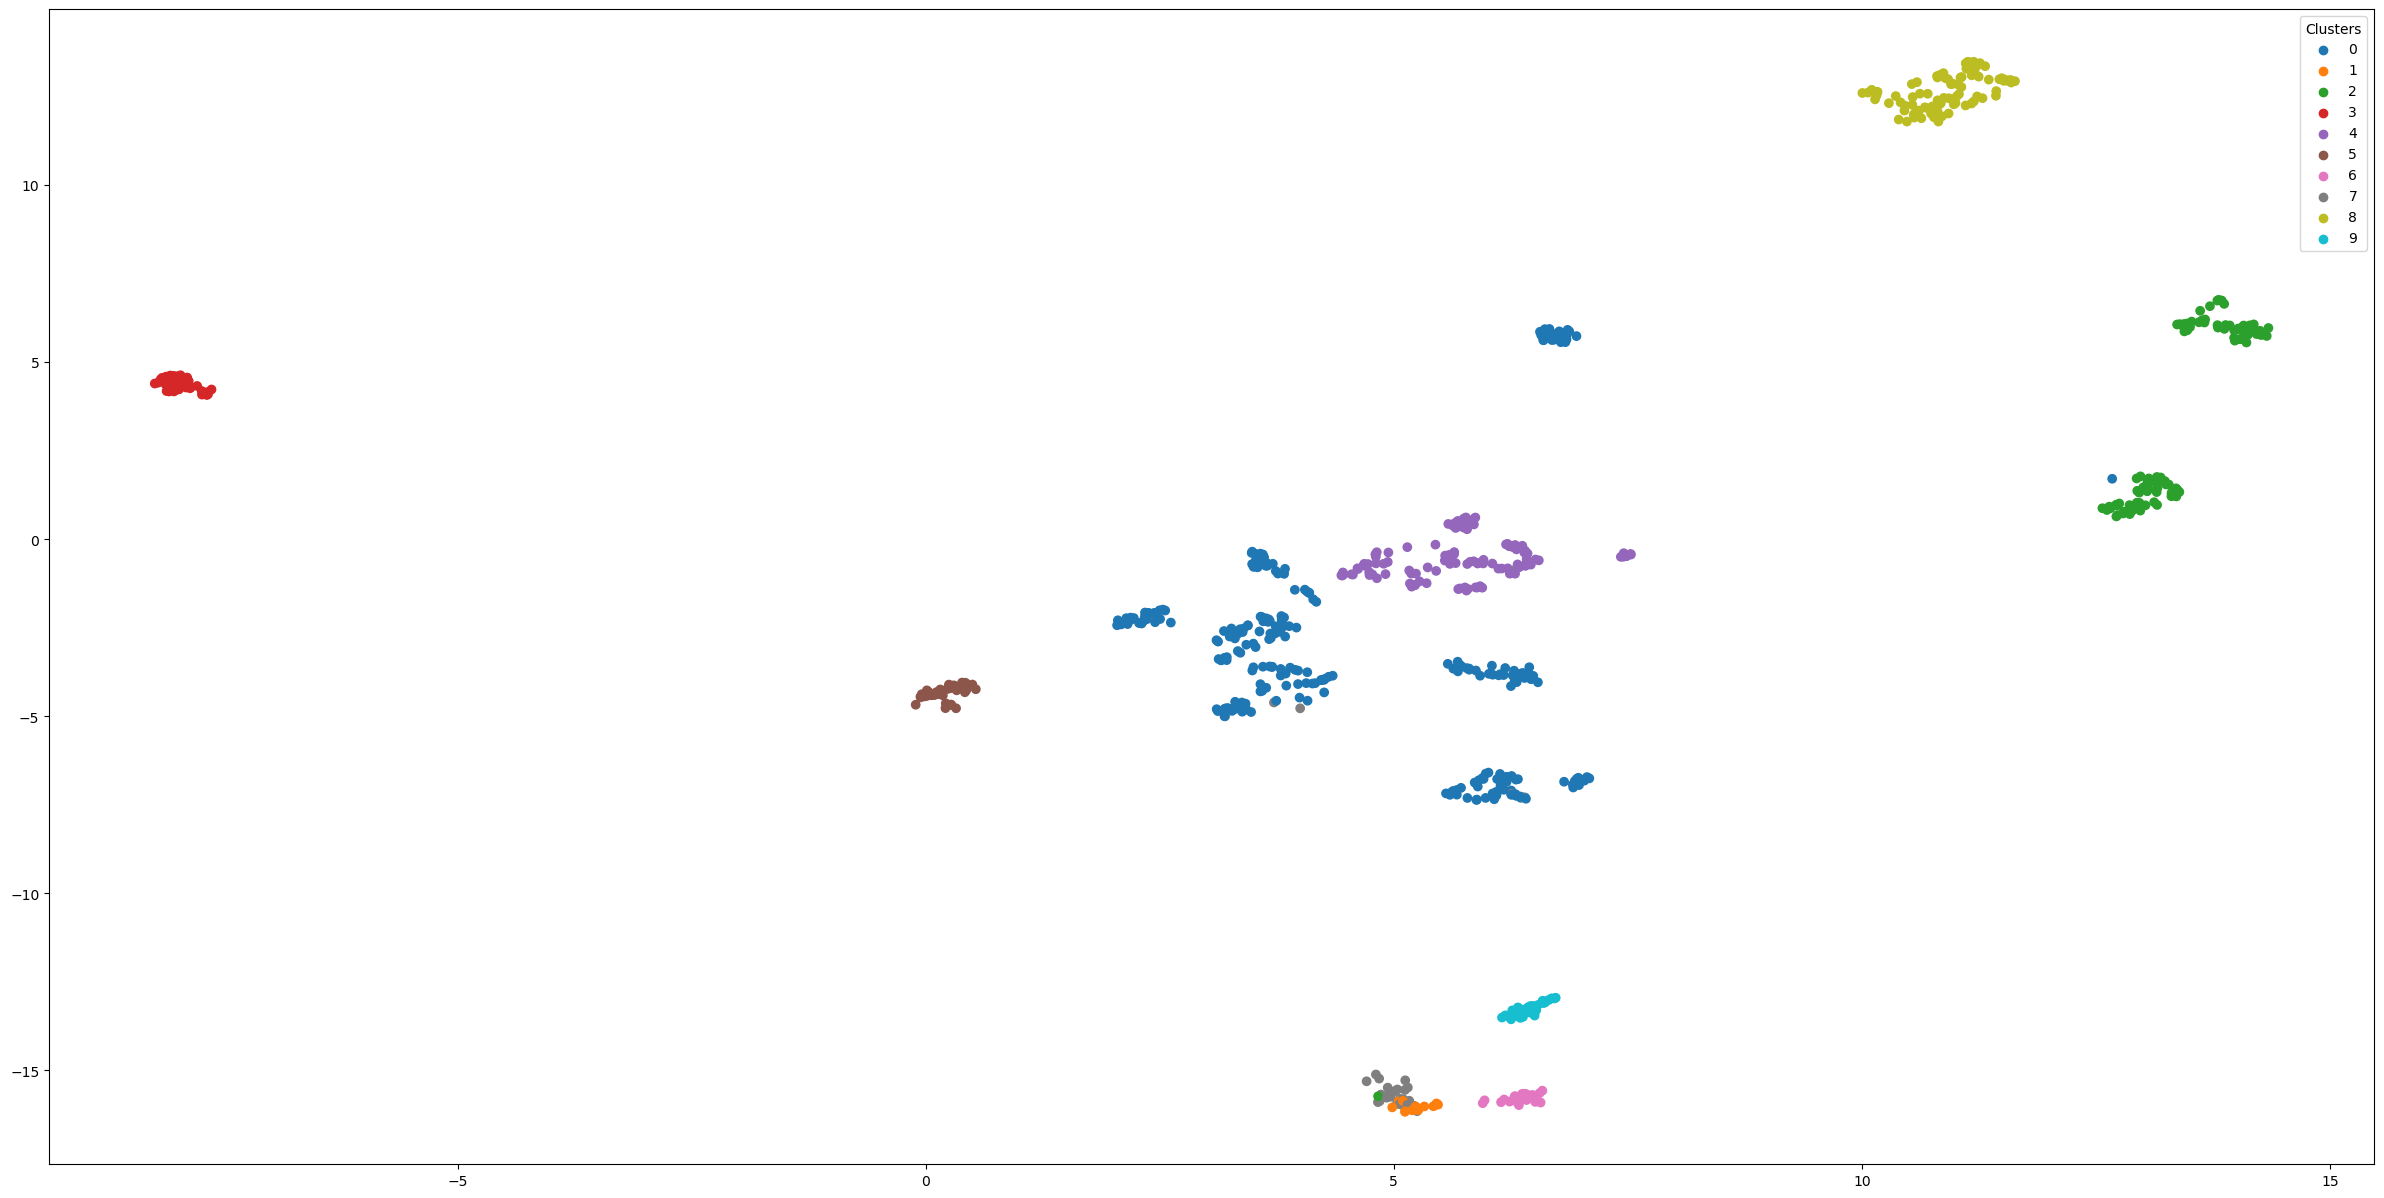

In [27]:
plot_dimensionality_reduction_results(umap_embedding, worker['rb_ward10'])

# **Final Cluster Labeling and Segment Distribution**

Following the selection of the final clustering solution, numerical cluster identifiers were mapped to descriptive and interpretable segment labels. This step enables clearer communication of results and facilitates downstream analysis and interpretation.

The final cluster assignments are stored in a dedicated column, and the distribution of observations across segments is examined to assess the relative size and representativeness of each employee group.


In [28]:
clusters_mapping = {
    0: "Mid-Age Stable Employees",
    1: "Employees with Chronic Absenteeism",
    2: "Young Low-Burden Performers",
    3: "Pet Lovers Employees",
    4: "Long-Distance Commuters with Pet Constraints",
    5: "Early-Career Unstable Workers",
    6: "Physically Strained Operational Staff",
    7: "Socially Driven High-Absence Group",
    8: "Healthy Young Reliable Employees",
    9: "Veteran Reliable Workforce"
}

In [29]:
# Create the final solution column
worker['final_solution'] = worker['rb_ward10']
# Map the cluster numbers to names
worker['Final_Cluster'] = [clusters_mapping[value] for value in worker['final_solution']]

In [30]:
worker[['Final_Cluster']].value_counts()

Final_Cluster                               
Mid-Age Stable Employees                        285
Long-Distance Commuters with Pet Constraints    117
Young Low-Burden Performers                     110
Healthy Young Reliable Employees                 90
Pet Lovers Employees                             43
Early-Career Unstable Workers                    42
Veteran Reliable Workforce                       35
Socially Driven High-Absence Group               33
Physically Strained Operational Staff            29
Employees with Chronic Absenteeism               16
Name: count, dtype: int64

# **Univariate Distribution Analysis by Cluster**

To further characterize and interpret the identified employee segments, univariate distributions of key variables are examined across the final clusters. Histograms with kernel density estimates are used to compare how each feature is distributed within and across clusters.

This analysis supports the qualitative interpretation of clusters by highlighting differences in demographic, behavioral, and absenteeism-related variables, and helps validate the coherence and distinctiveness of the final segmentation.

In [31]:
cluster_colors = {
    0: 'blue',          
    1: 'orange',      
    2: 'green',      
    3: 'red',       
    4: 'purple',      
    5: 'brown',    
    6: 'pink',      
    7: 'grey',  
    8: 'yellow',  
    9: 'deepskyblue'   
}

cols_to_plot = [
    'Age',
    'Transportation expense',
    'Distance from Residence to Work',
    'Service time',
    'Years until retirement',
    'Disciplinary failure',
    'Number of children',
    'Social drinker',
    'Social smoker',
    'Number of pets',
    'Weight',
    'Height',
    'Absenteeism time in hours',
    'Reason_for_abs_freq',
    'Final_Cluster'
]


  0%|          | 0/15 [00:00<?, ?it/s]

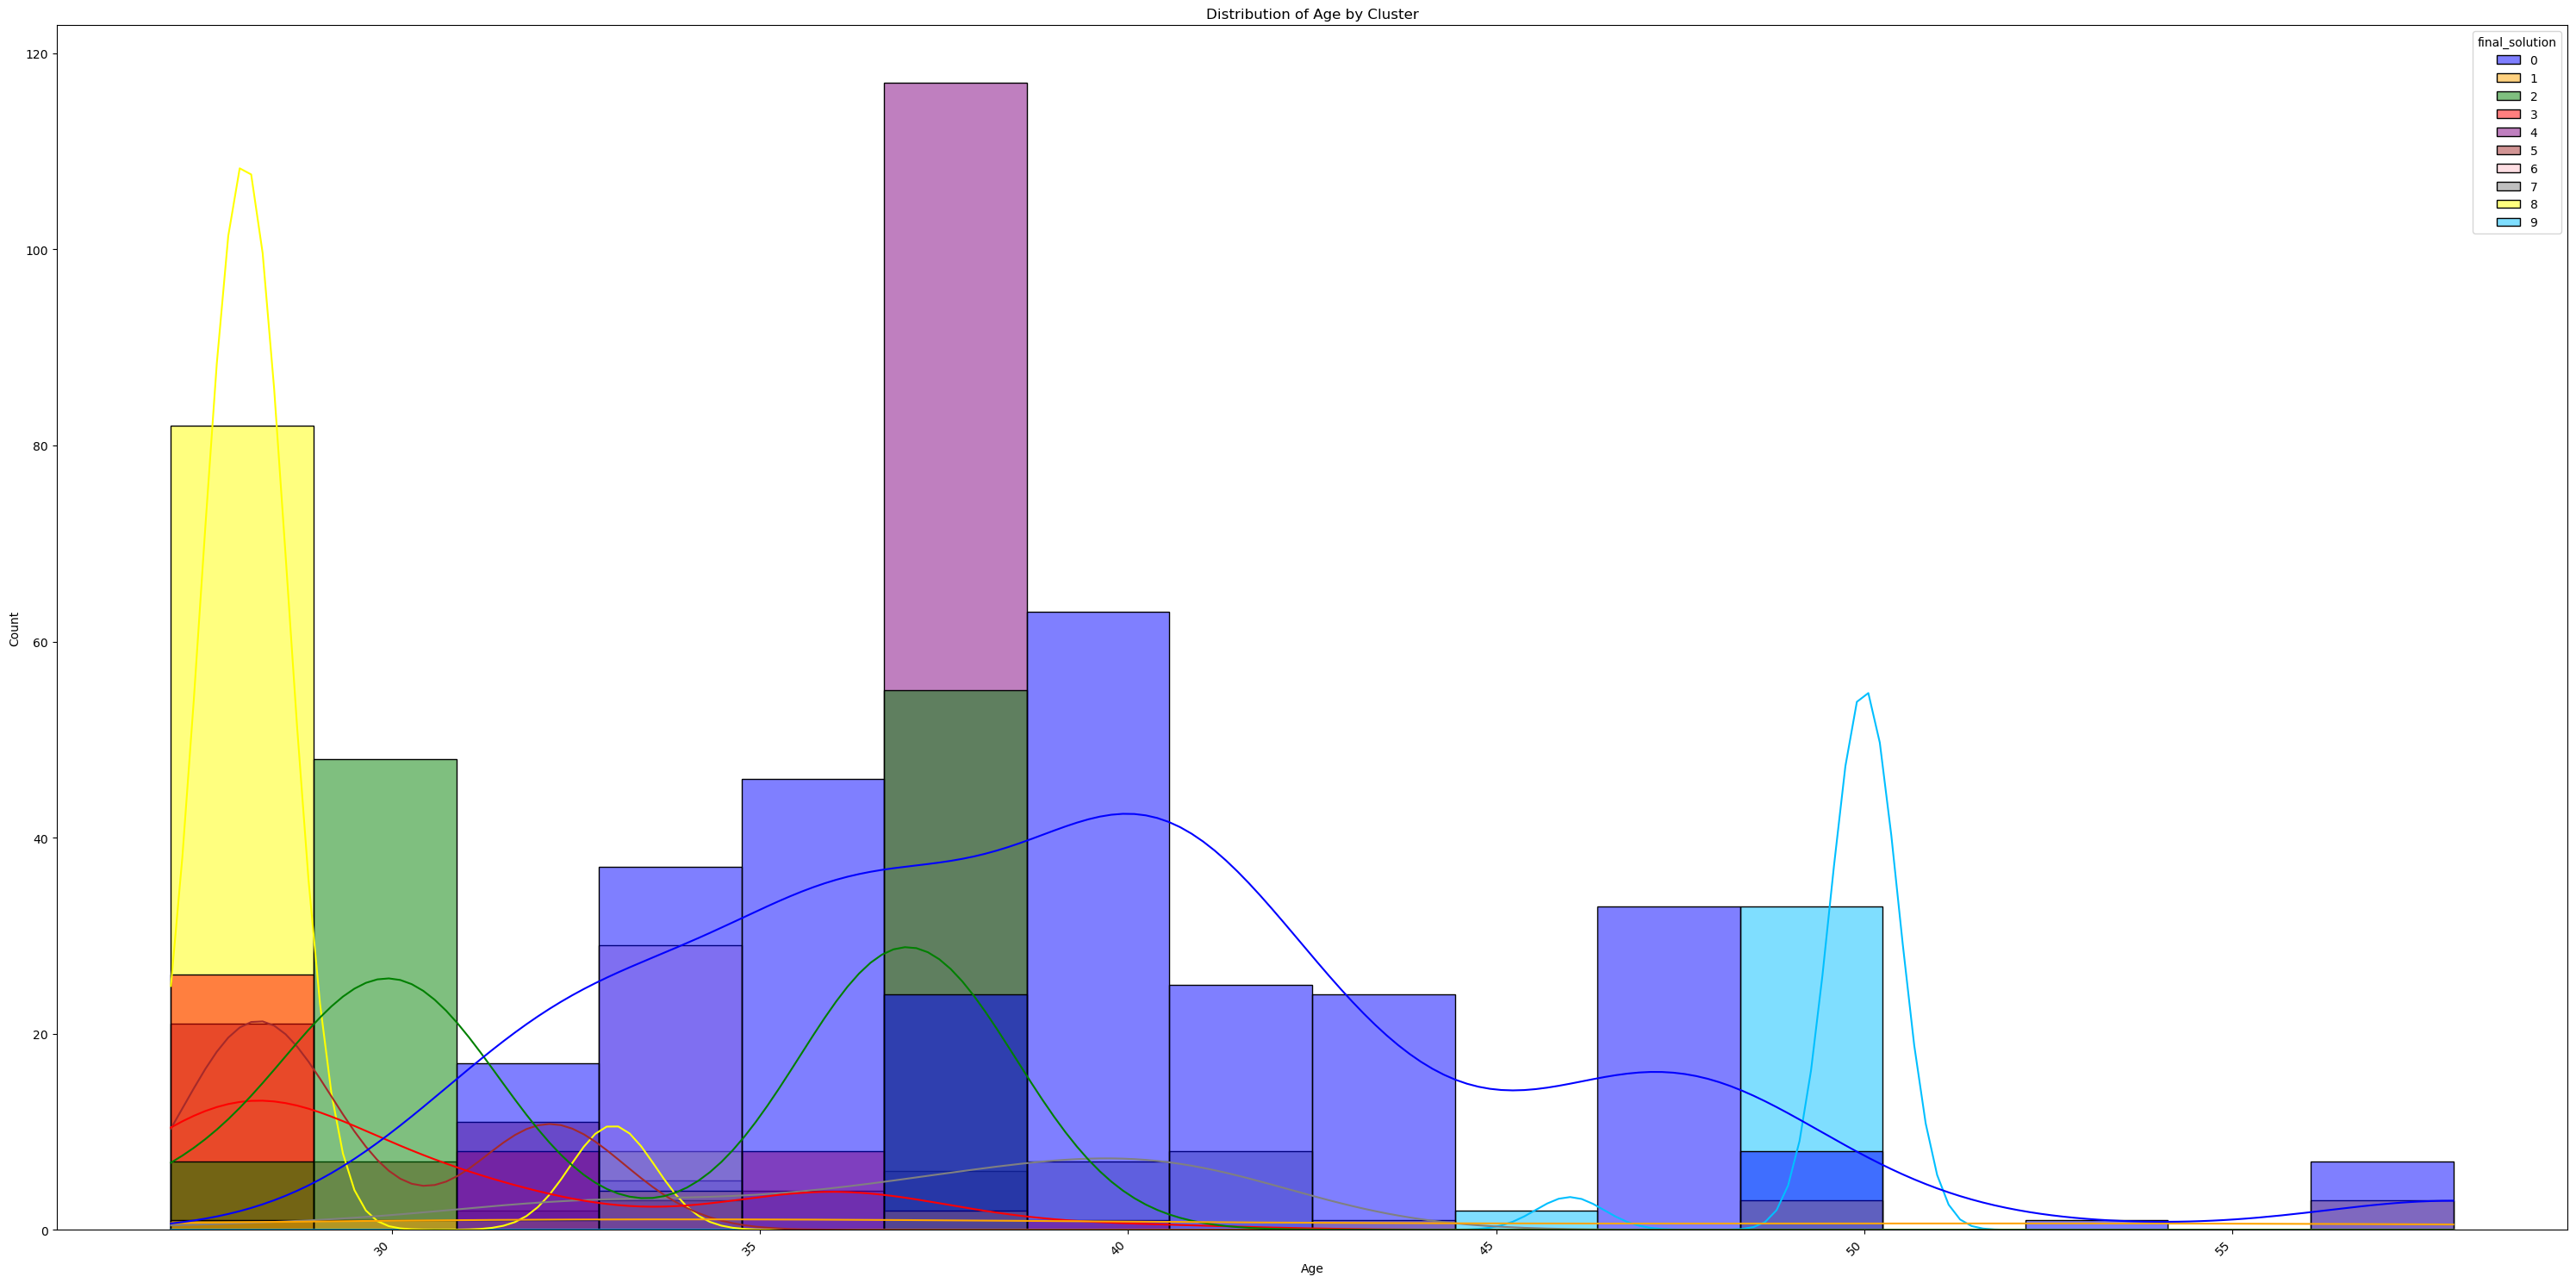

  7%|▋         | 1/15 [00:00<00:04,  3.01it/s]

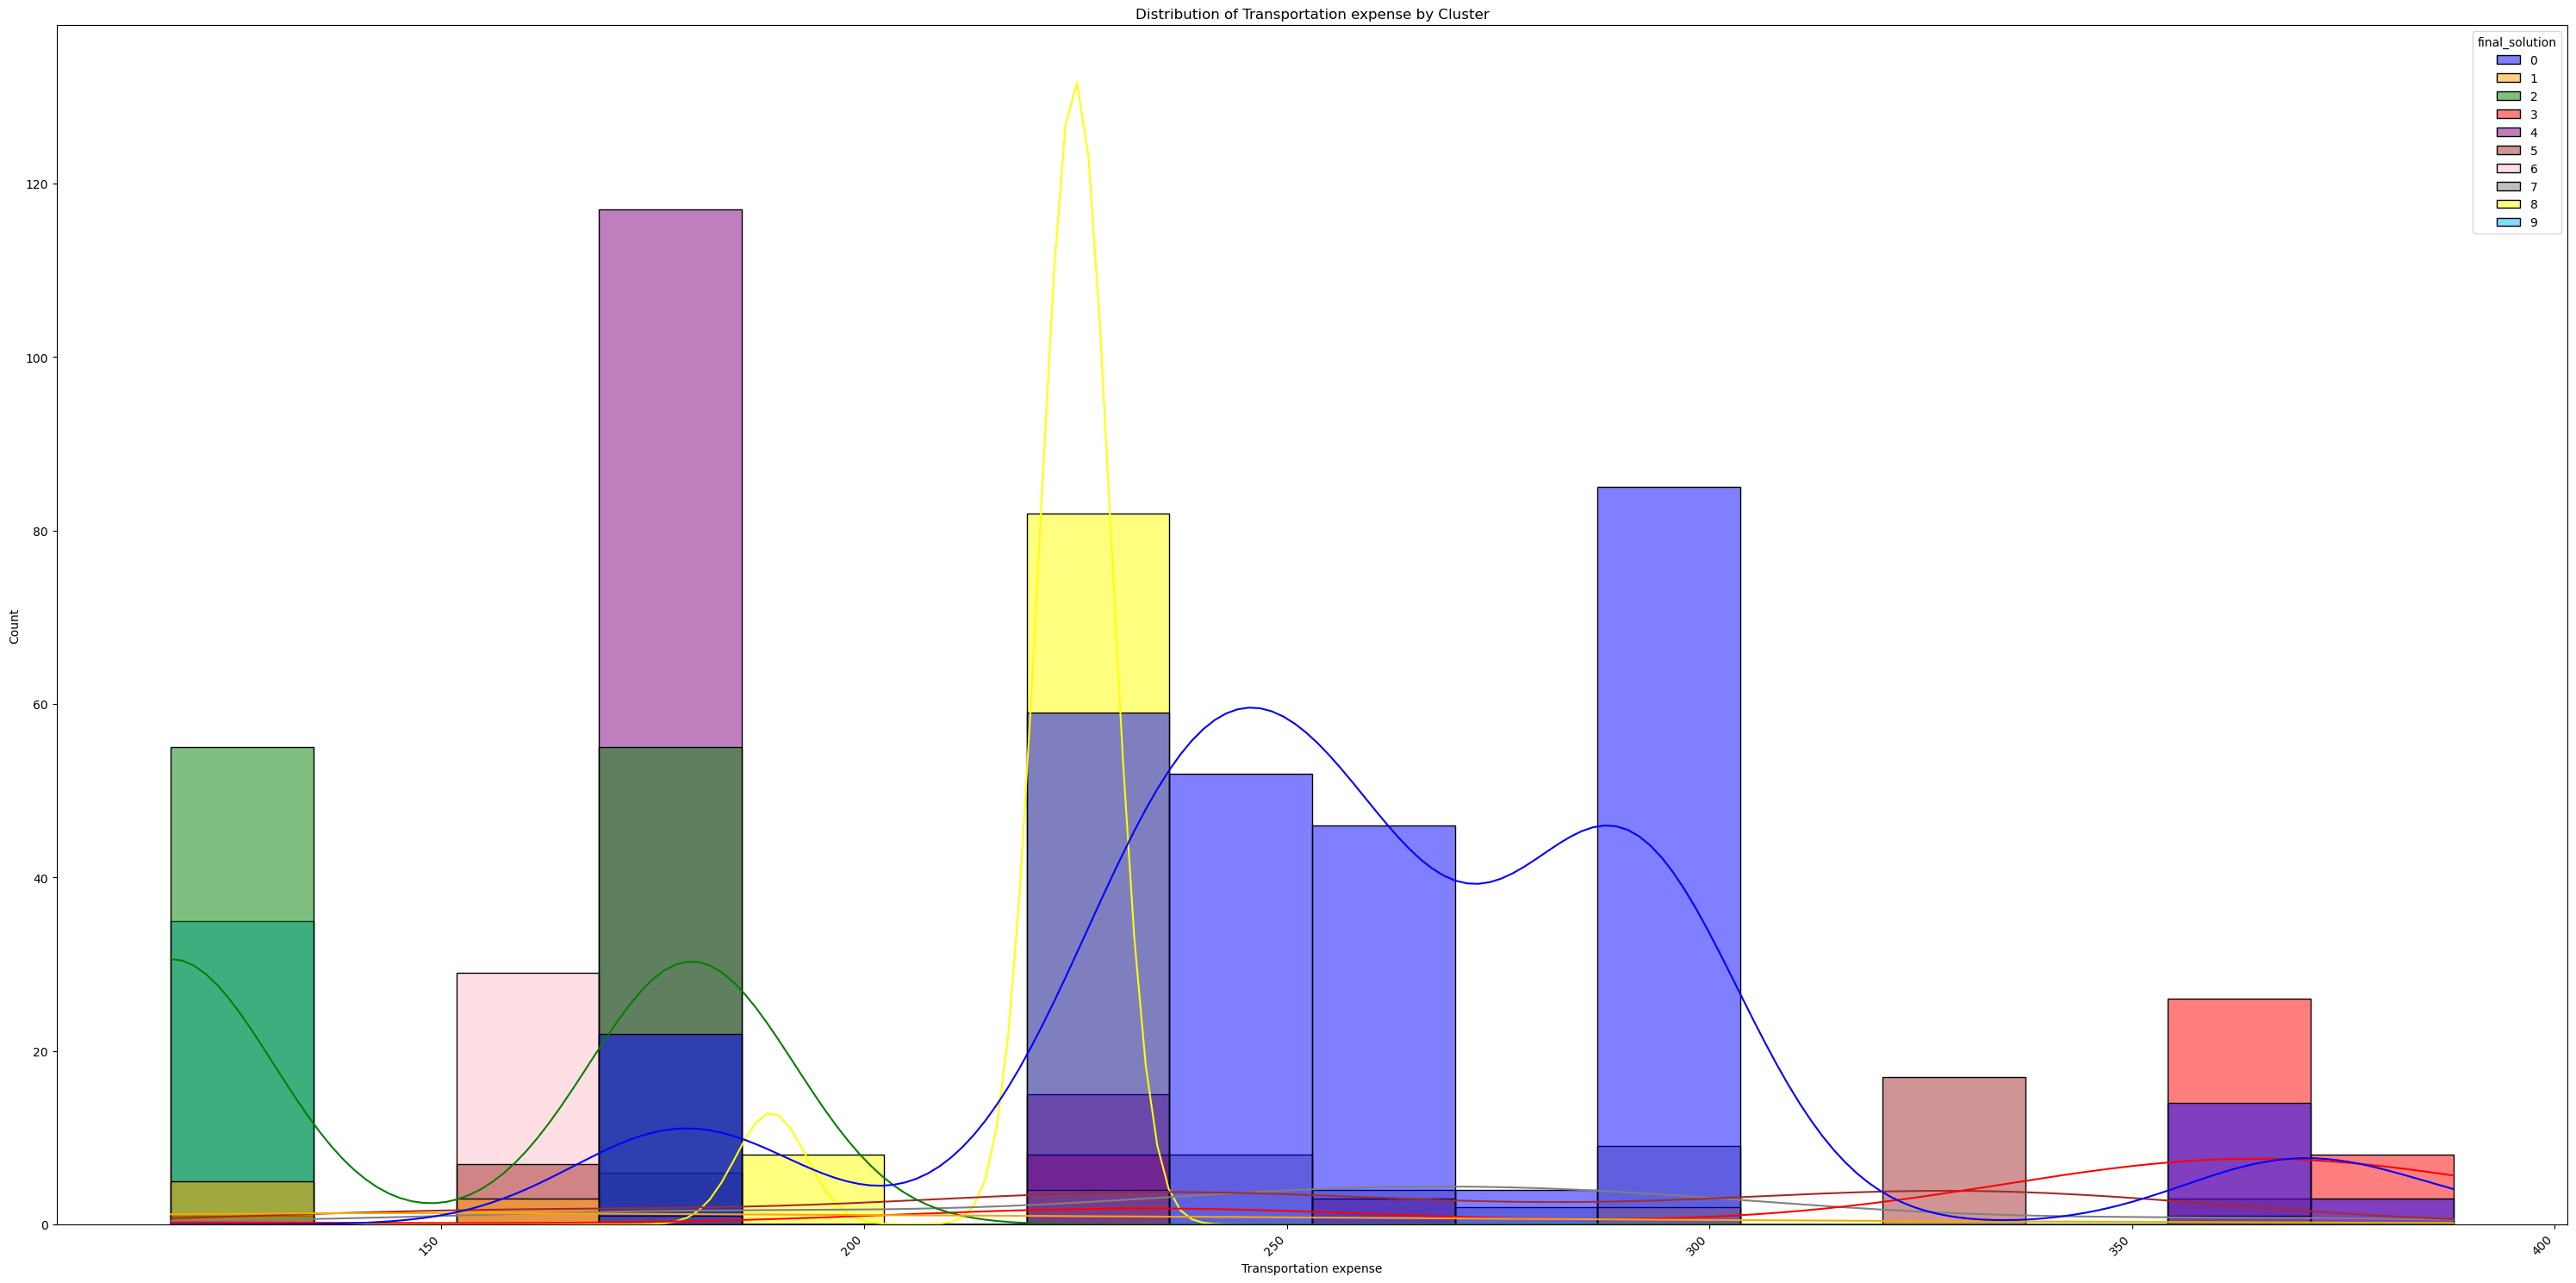

 13%|█▎        | 2/15 [00:00<00:03,  3.37it/s]

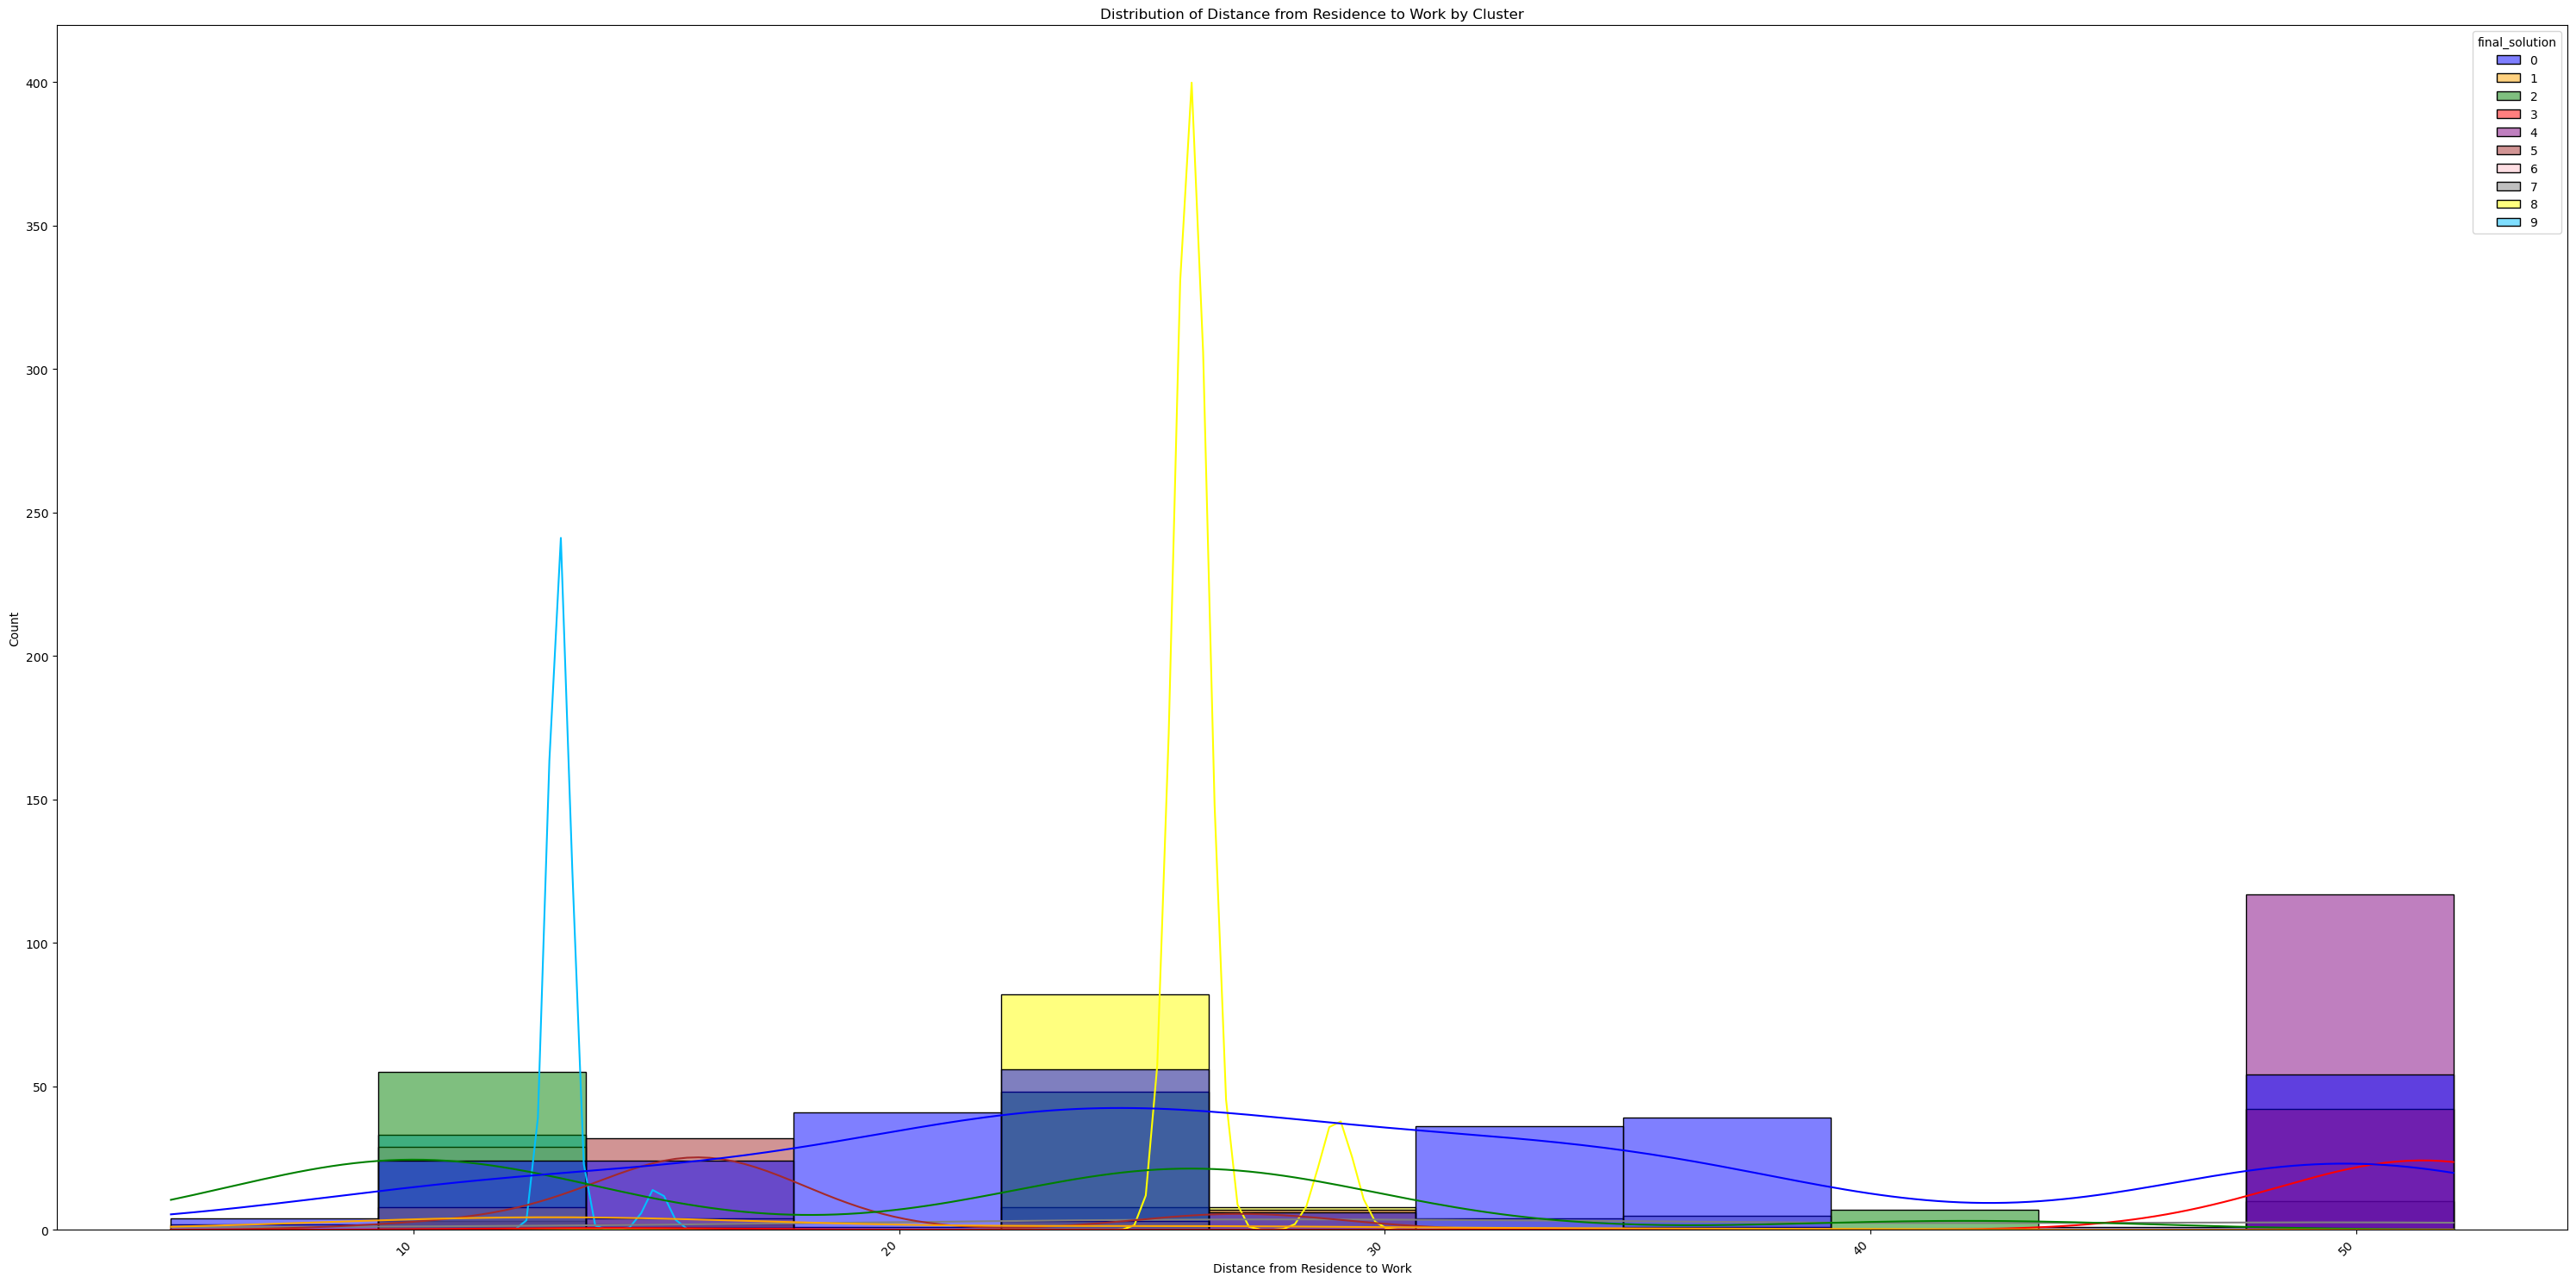

 20%|██        | 3/15 [00:00<00:03,  3.69it/s]

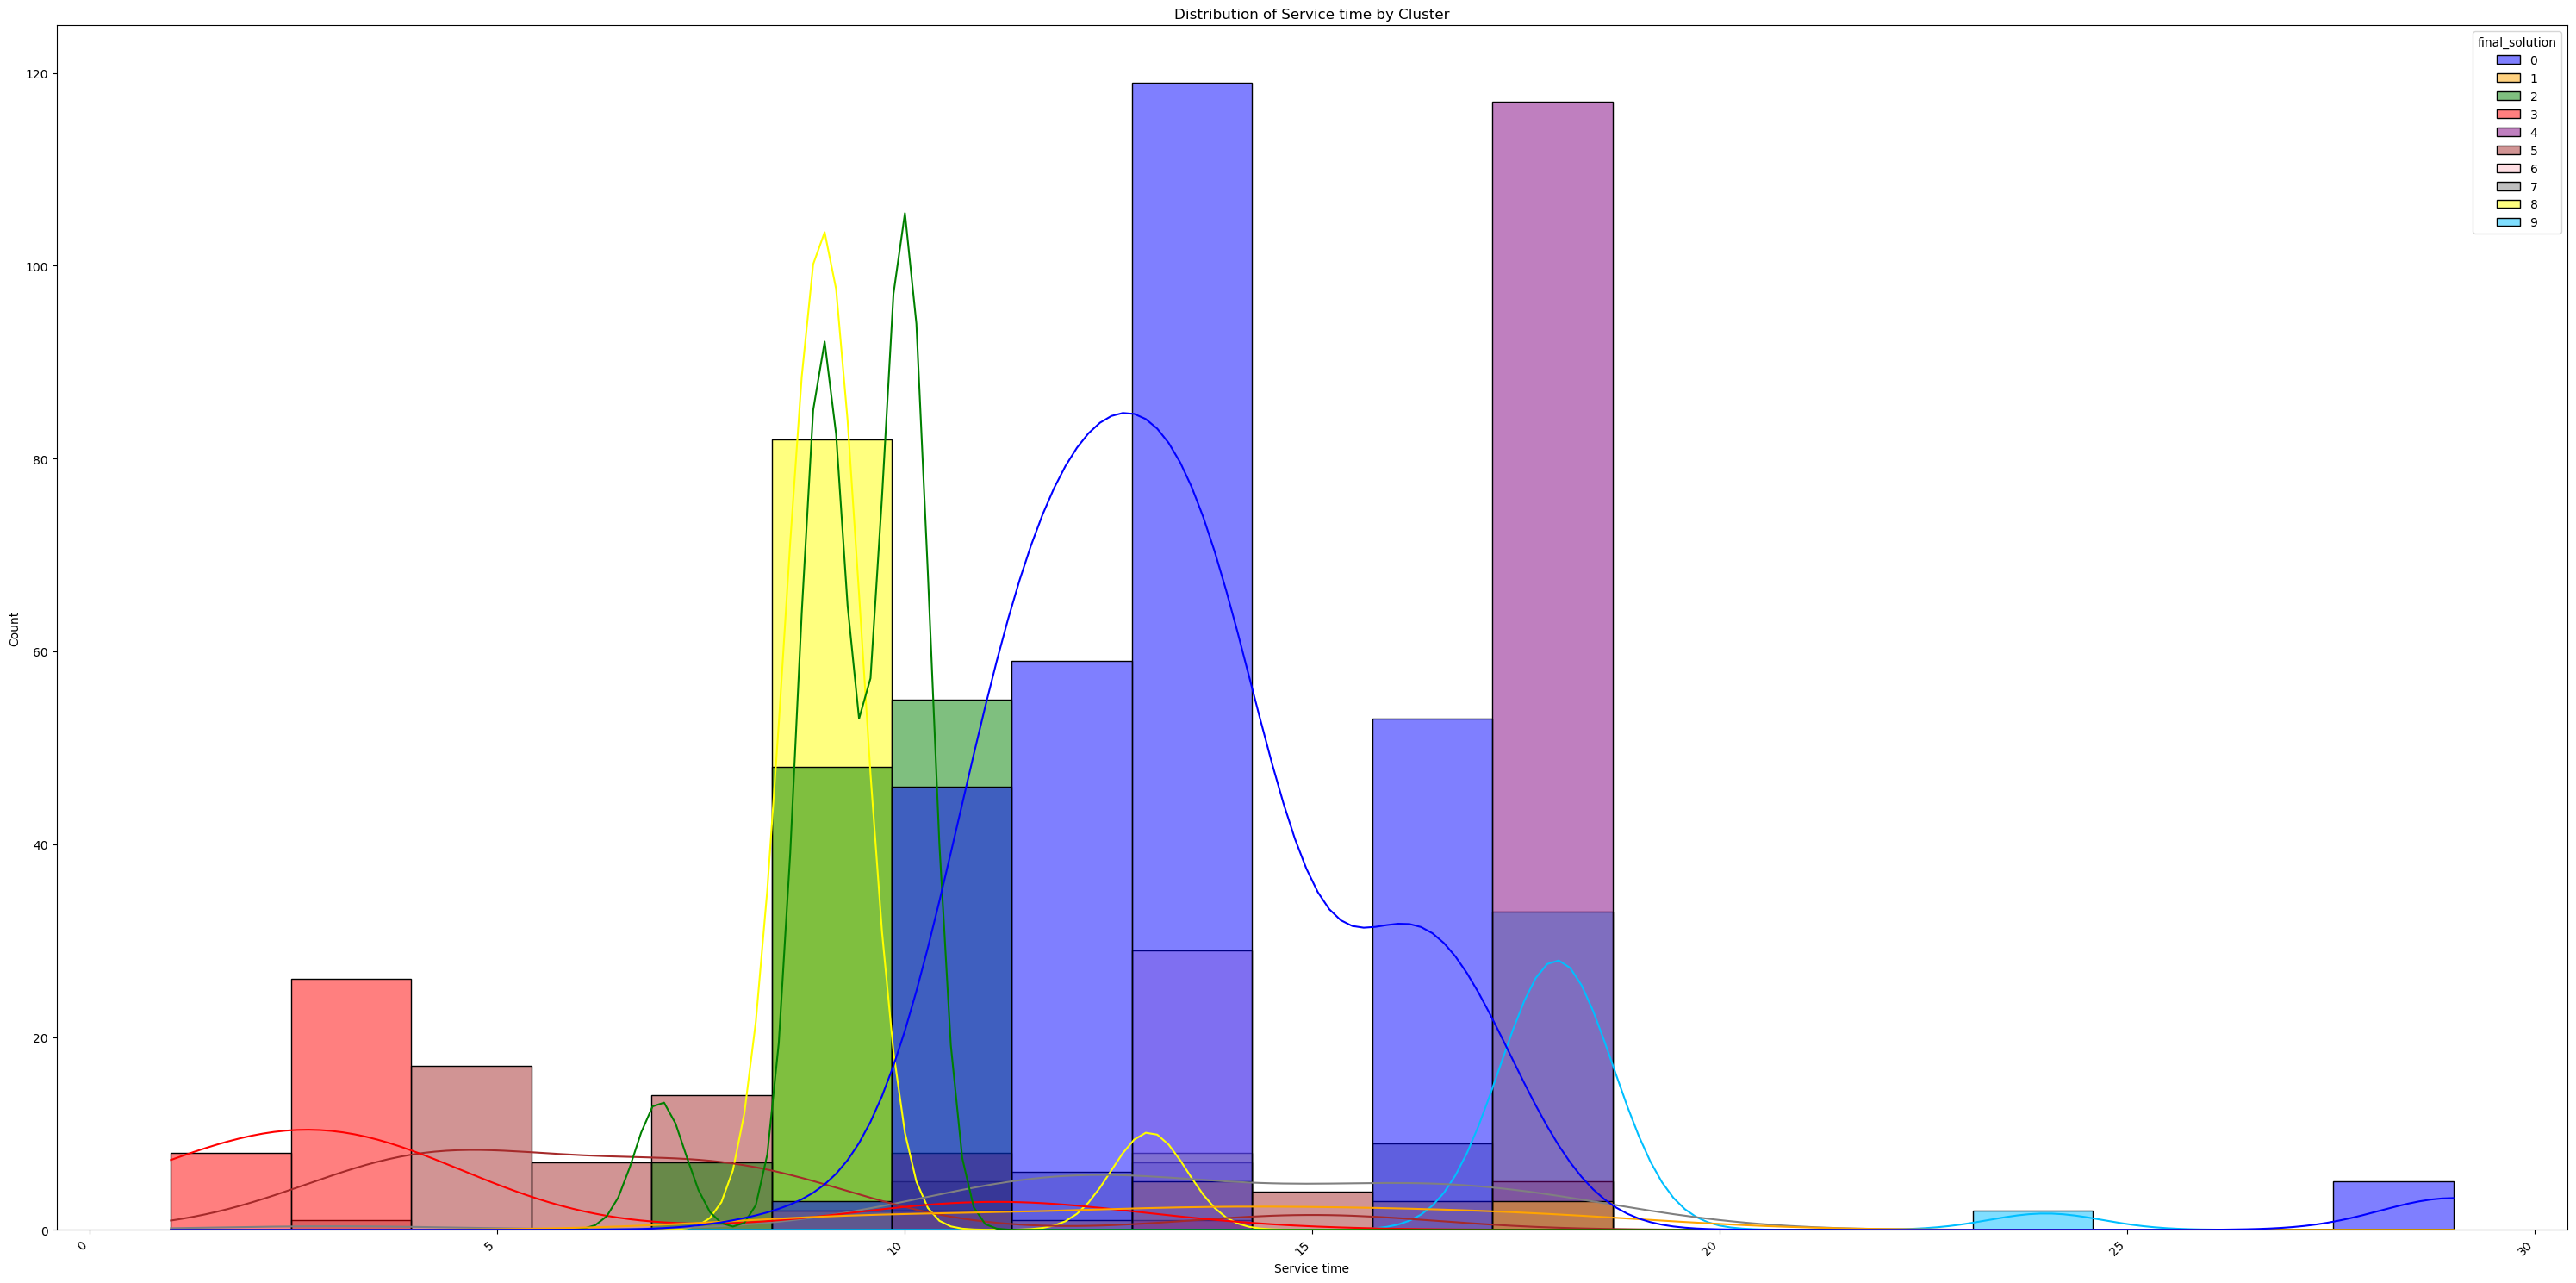

 27%|██▋       | 4/15 [00:01<00:03,  3.63it/s]

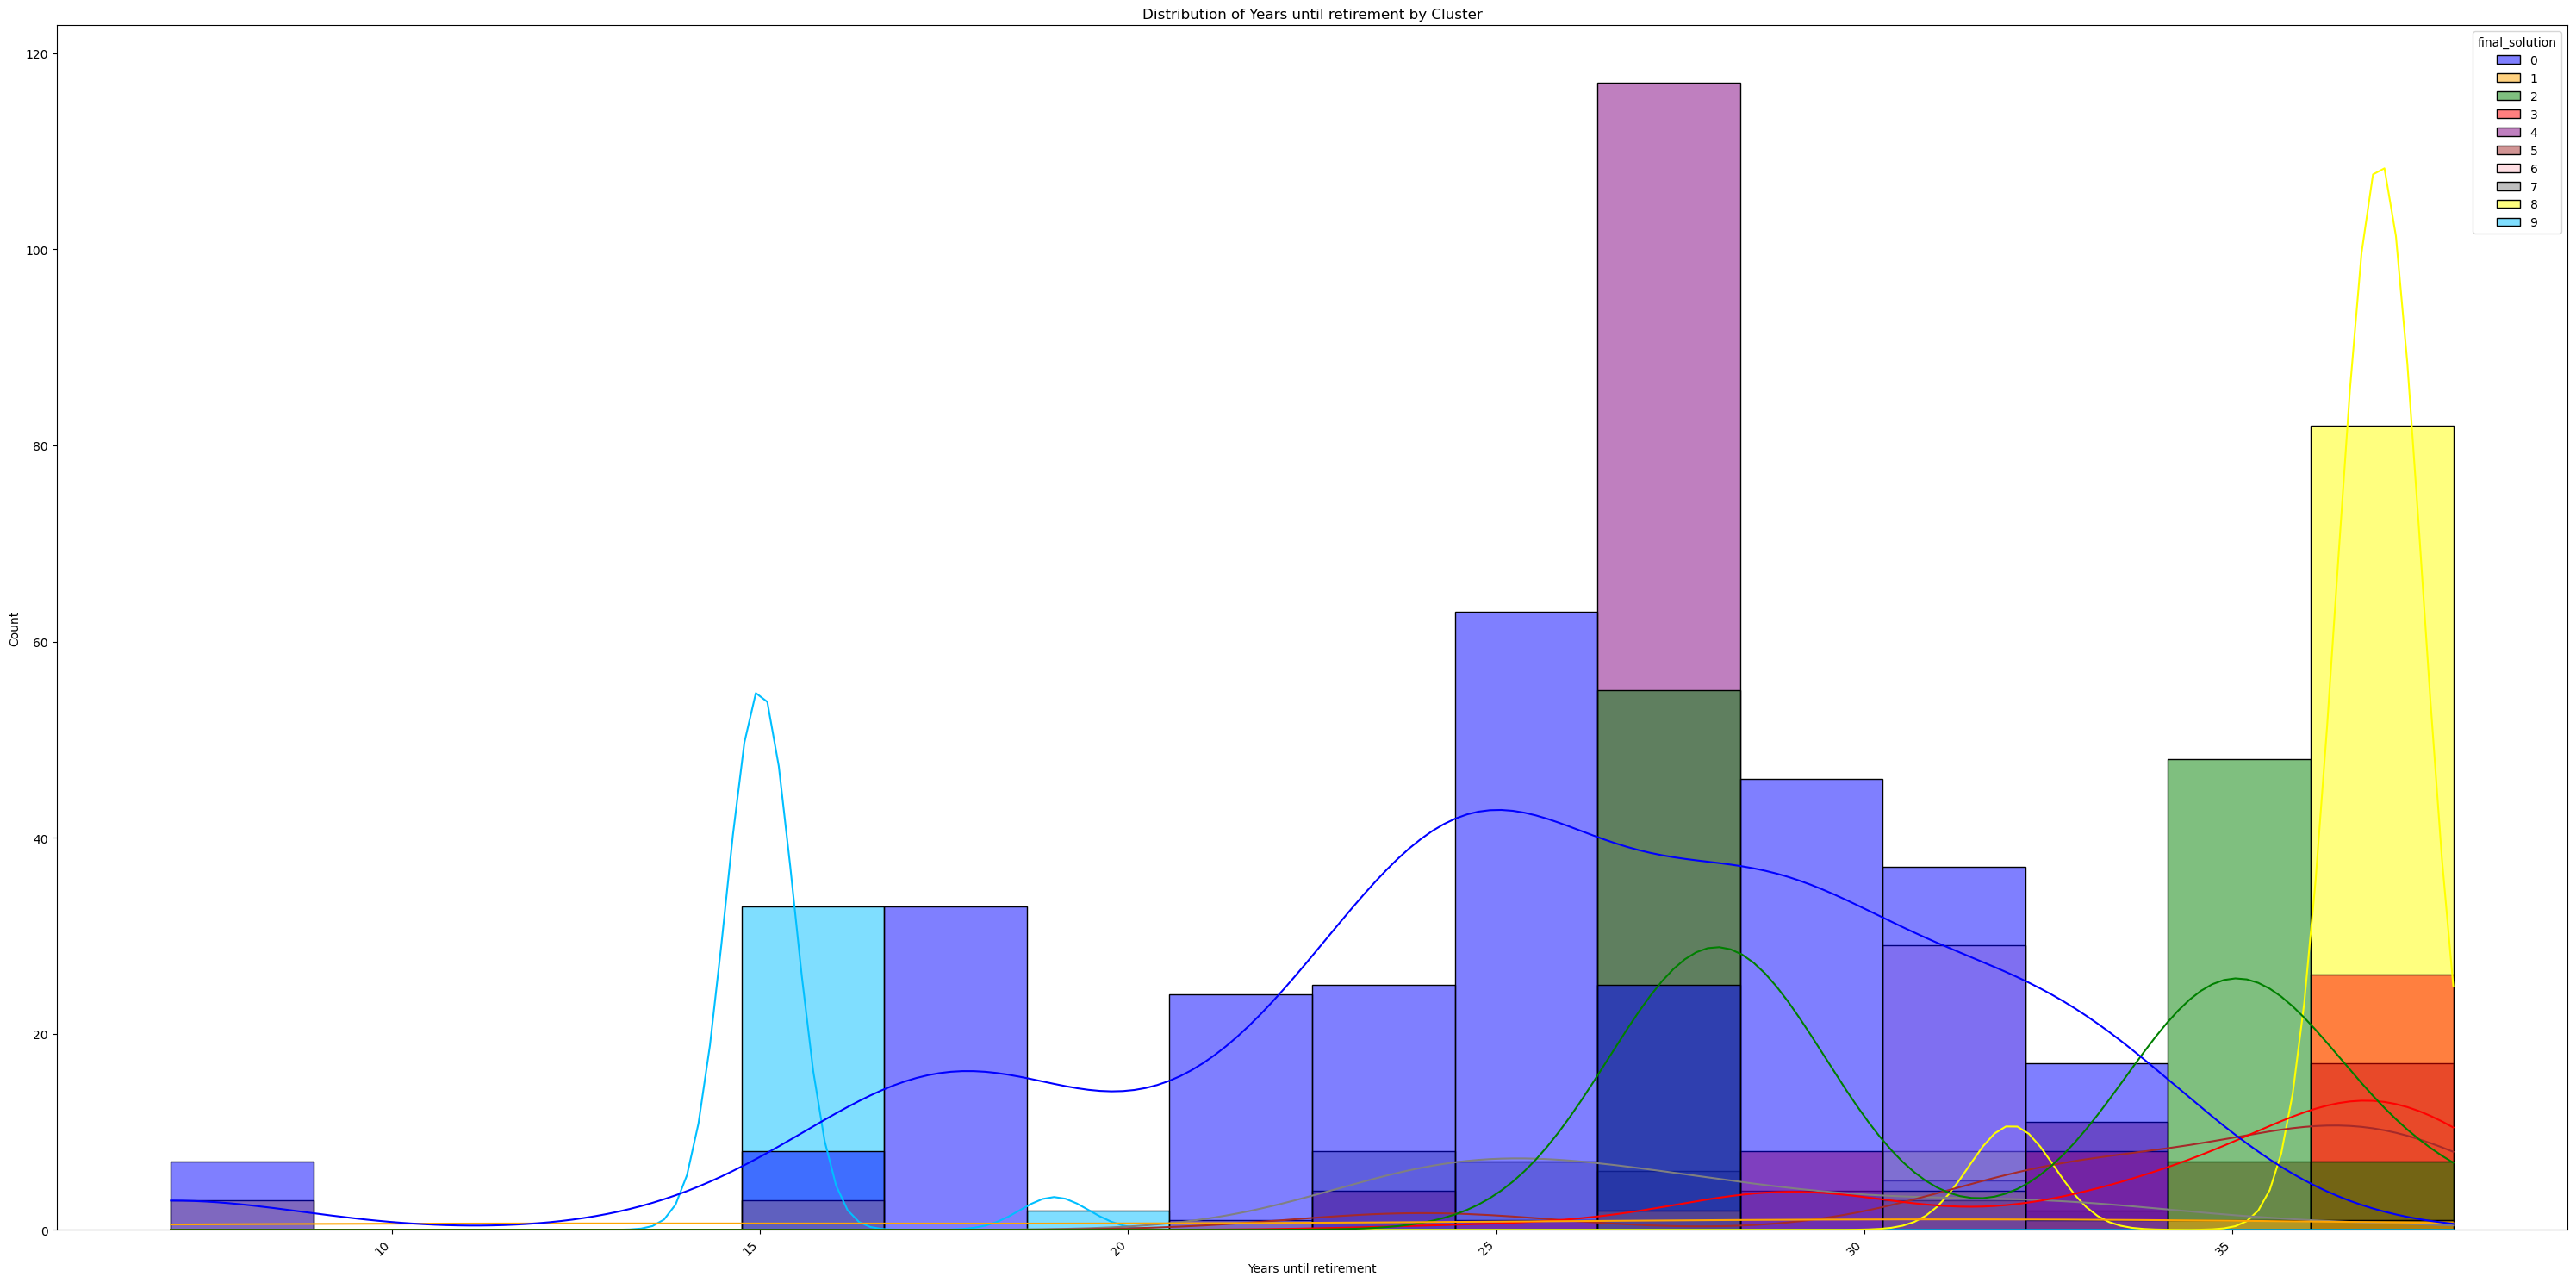

 33%|███▎      | 5/15 [00:01<00:03,  3.27it/s]

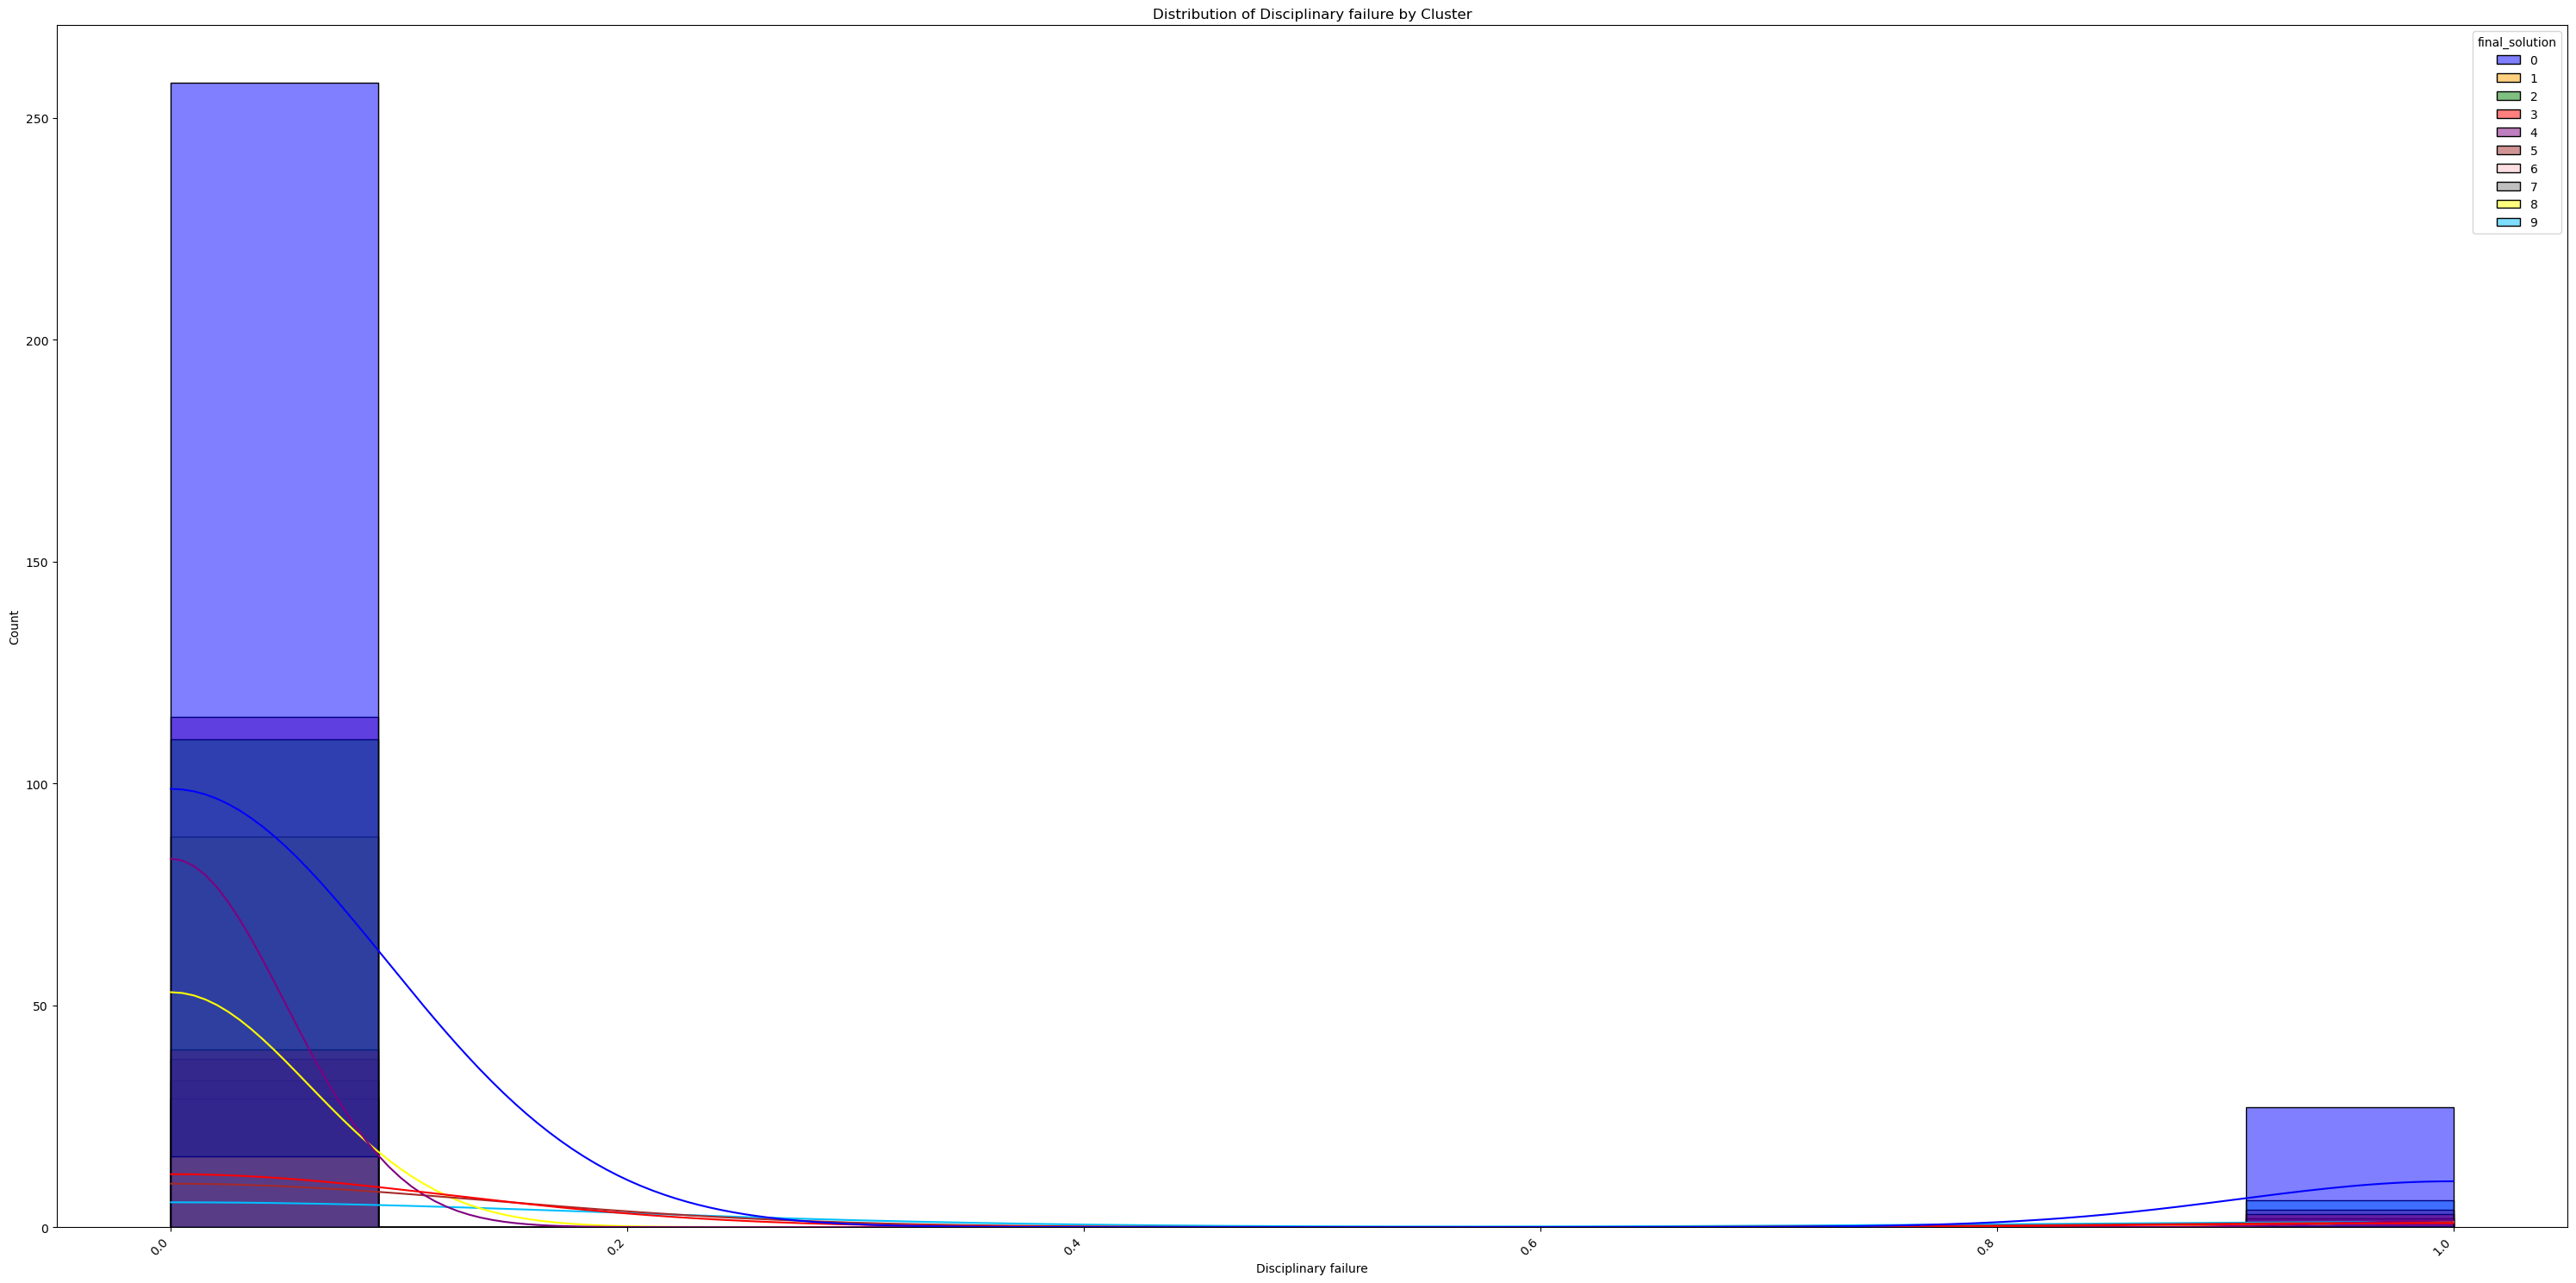

 40%|████      | 6/15 [00:01<00:02,  3.56it/s]

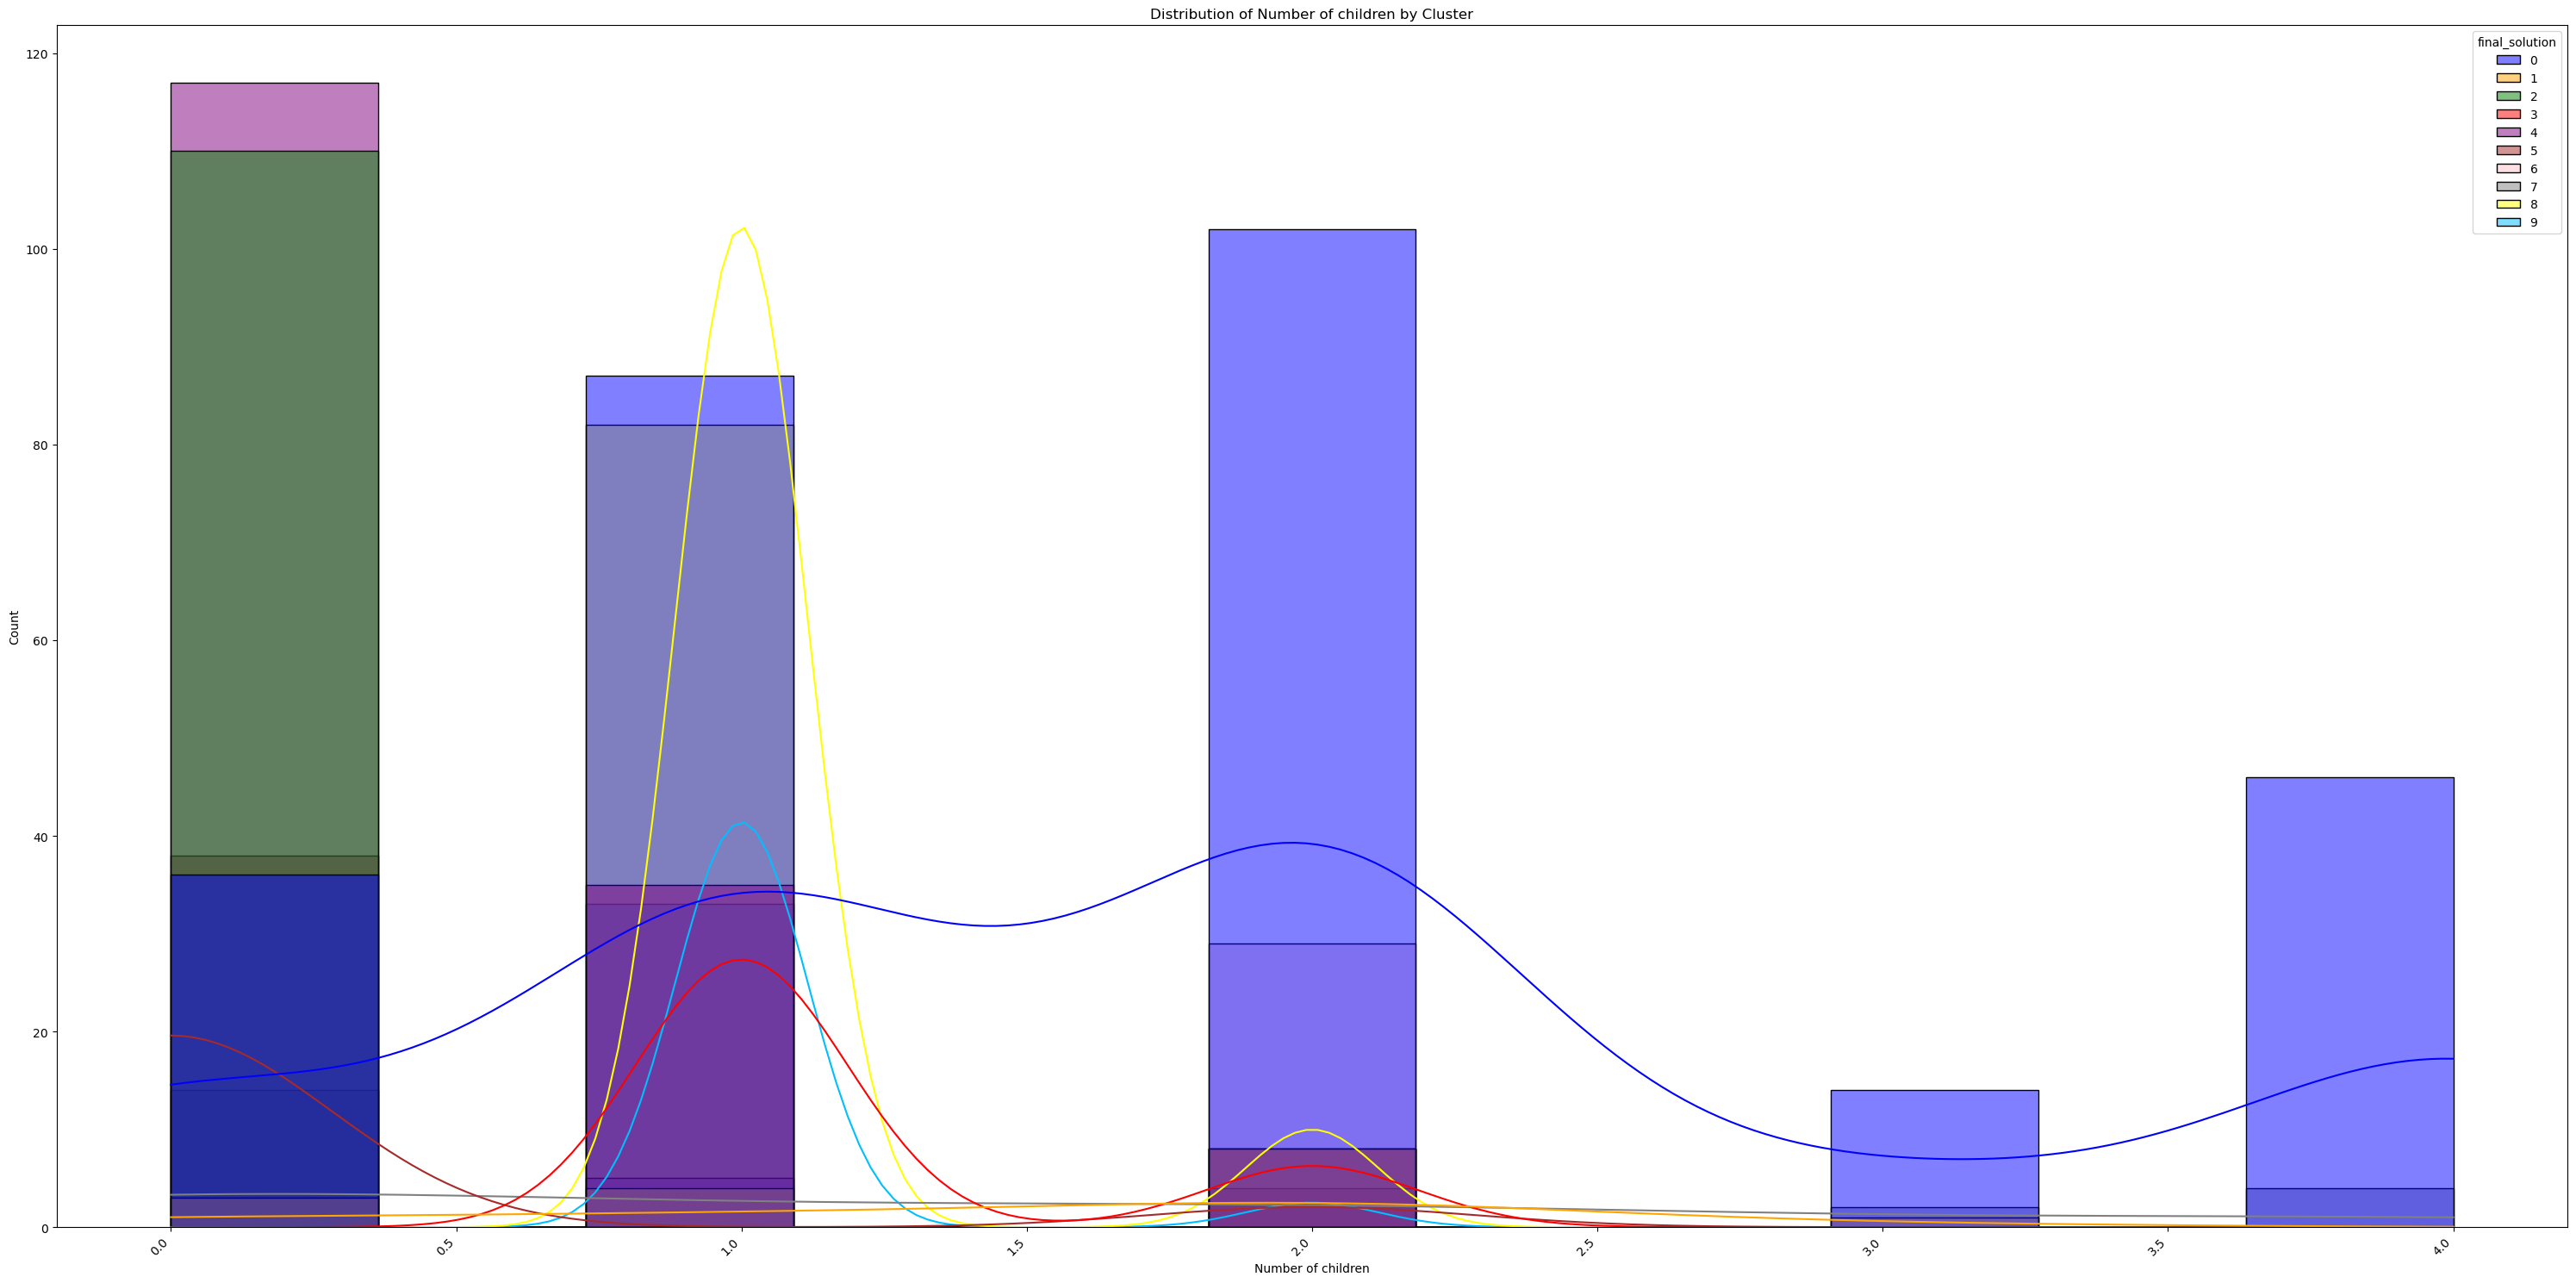

 47%|████▋     | 7/15 [00:01<00:02,  3.72it/s]

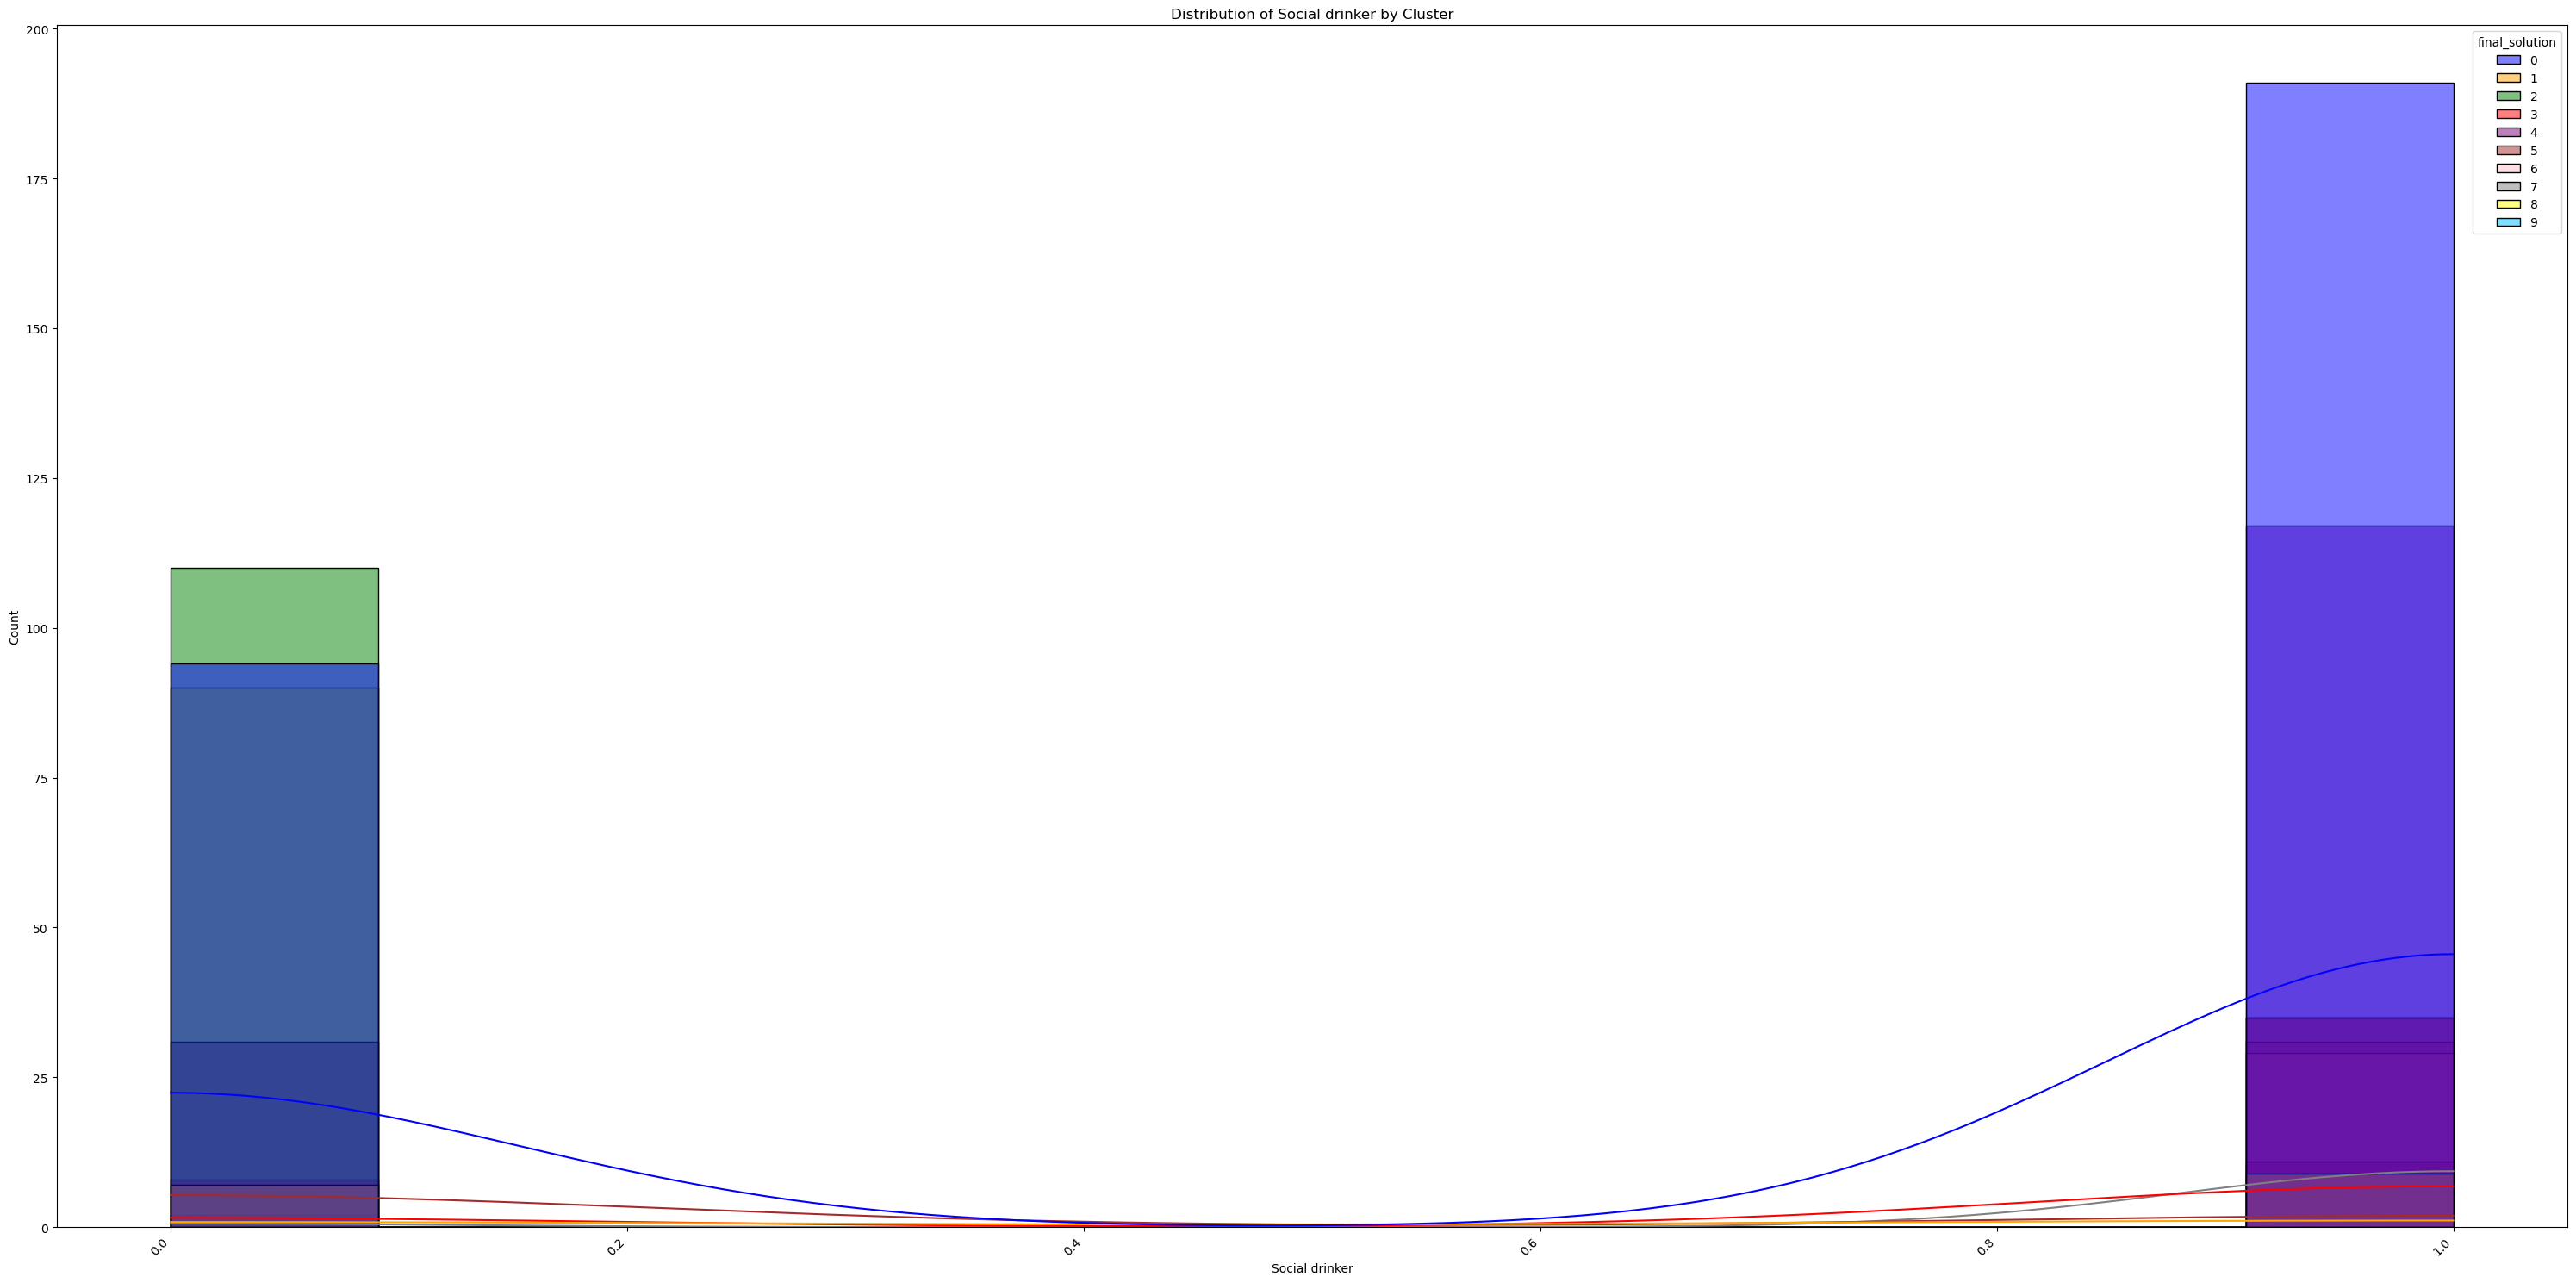

 53%|█████▎    | 8/15 [00:02<00:01,  3.94it/s]

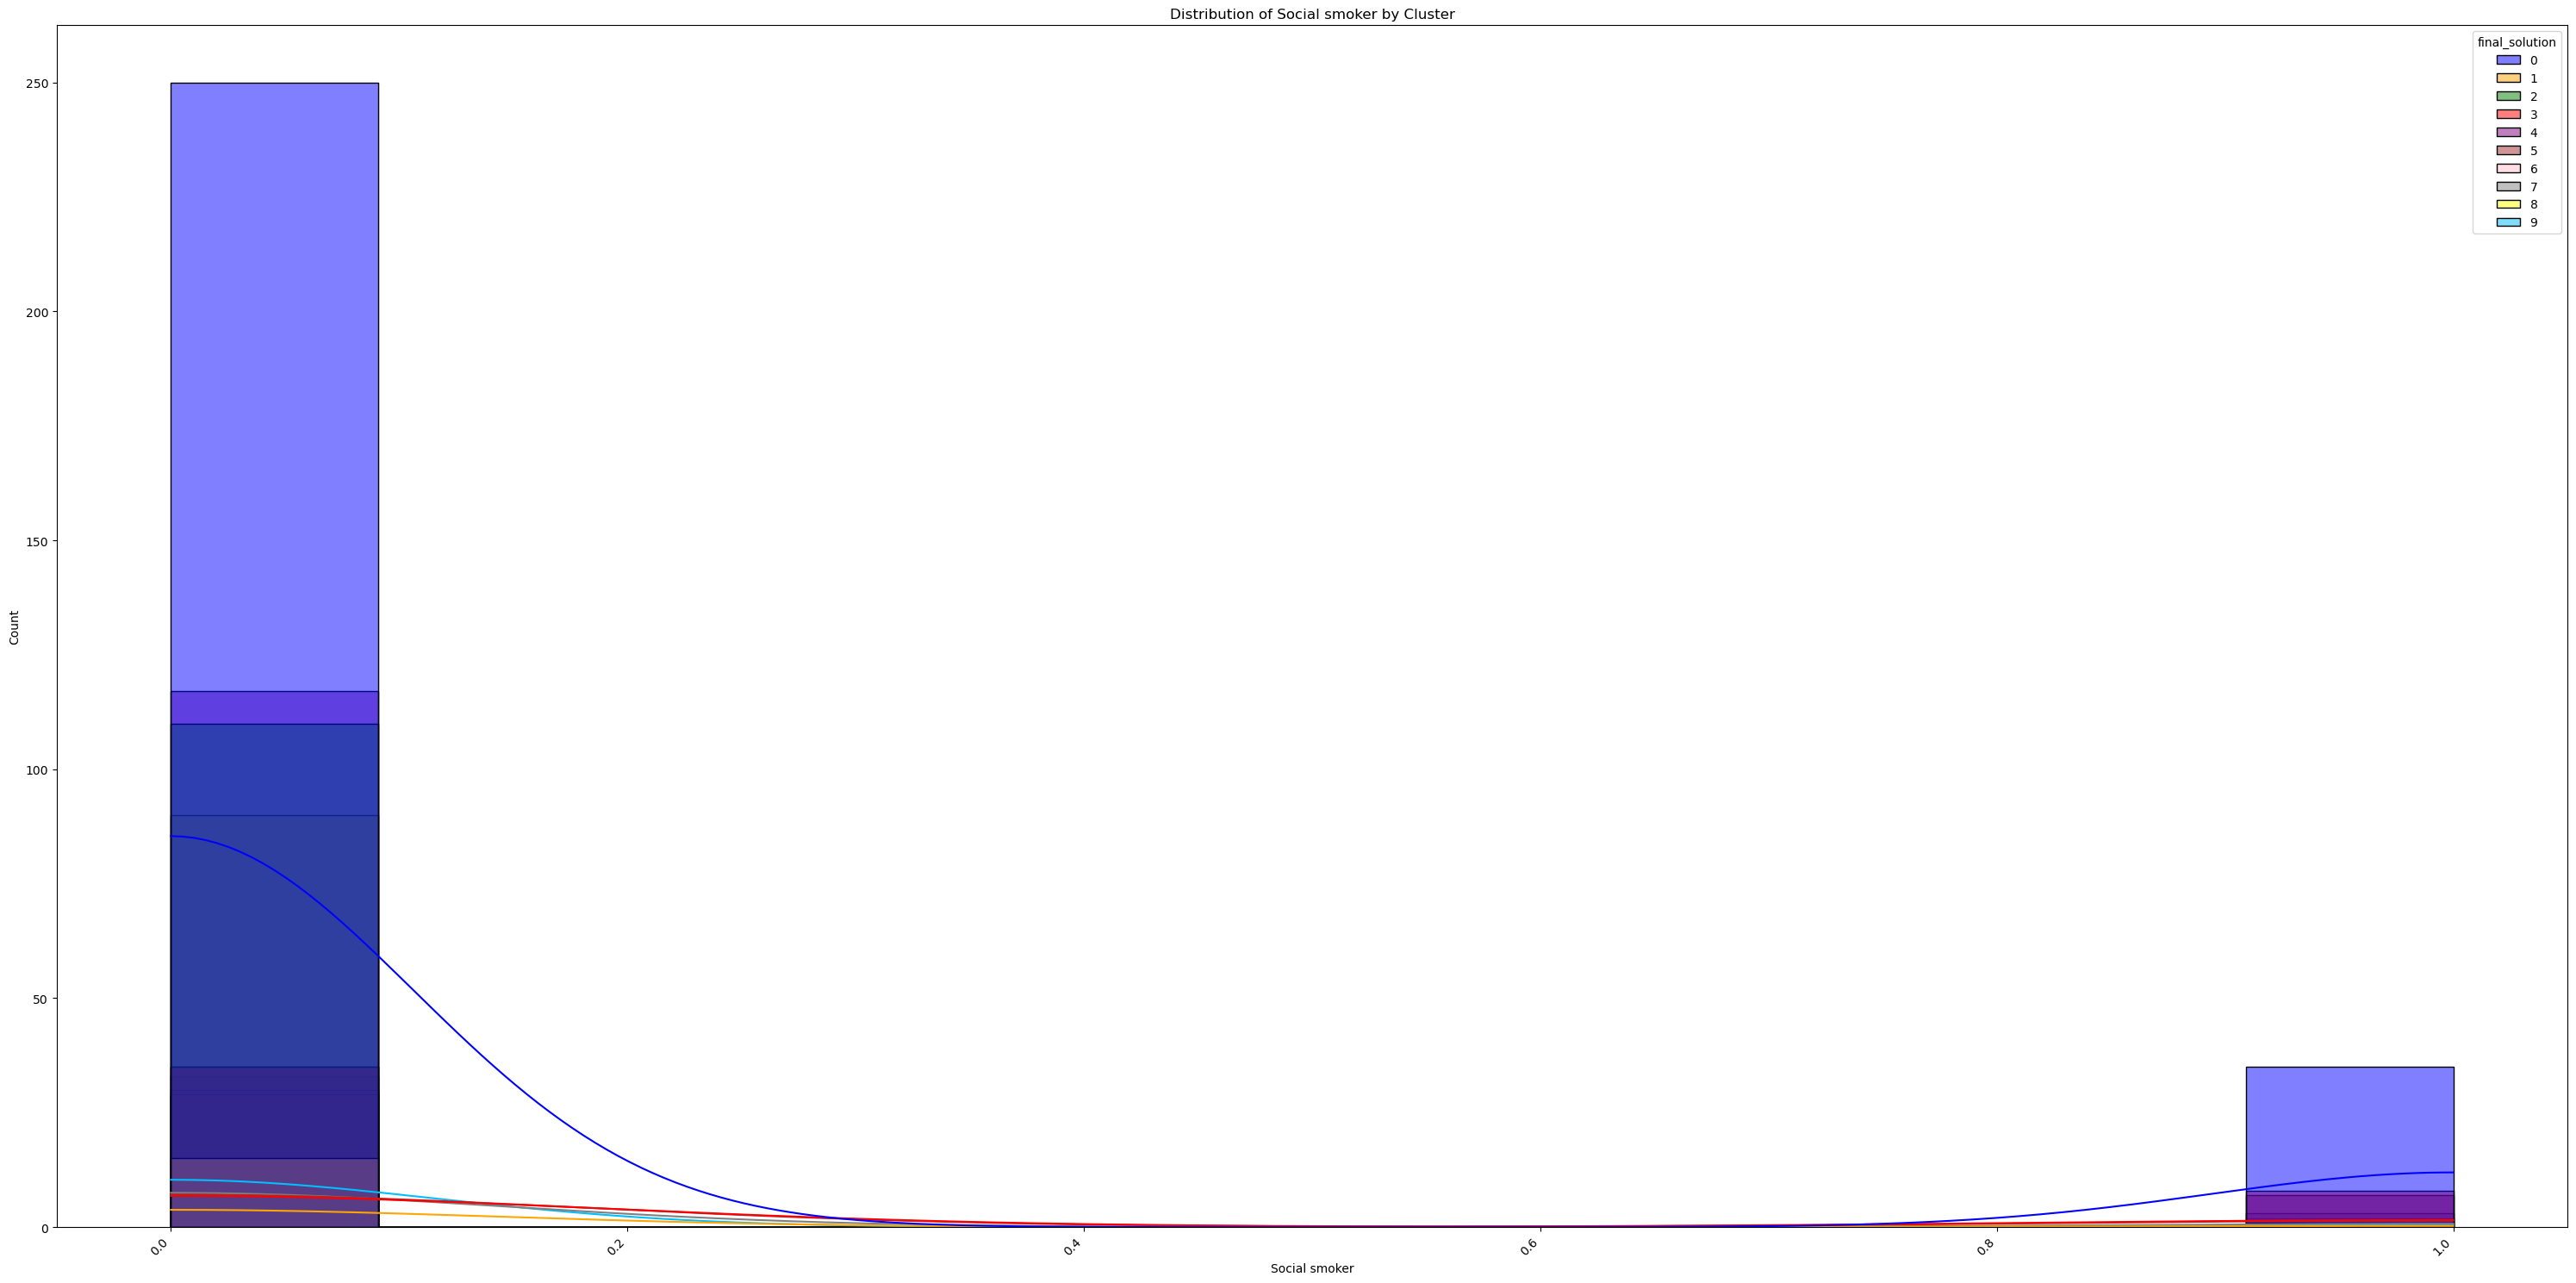

 60%|██████    | 9/15 [00:02<00:01,  4.17it/s]

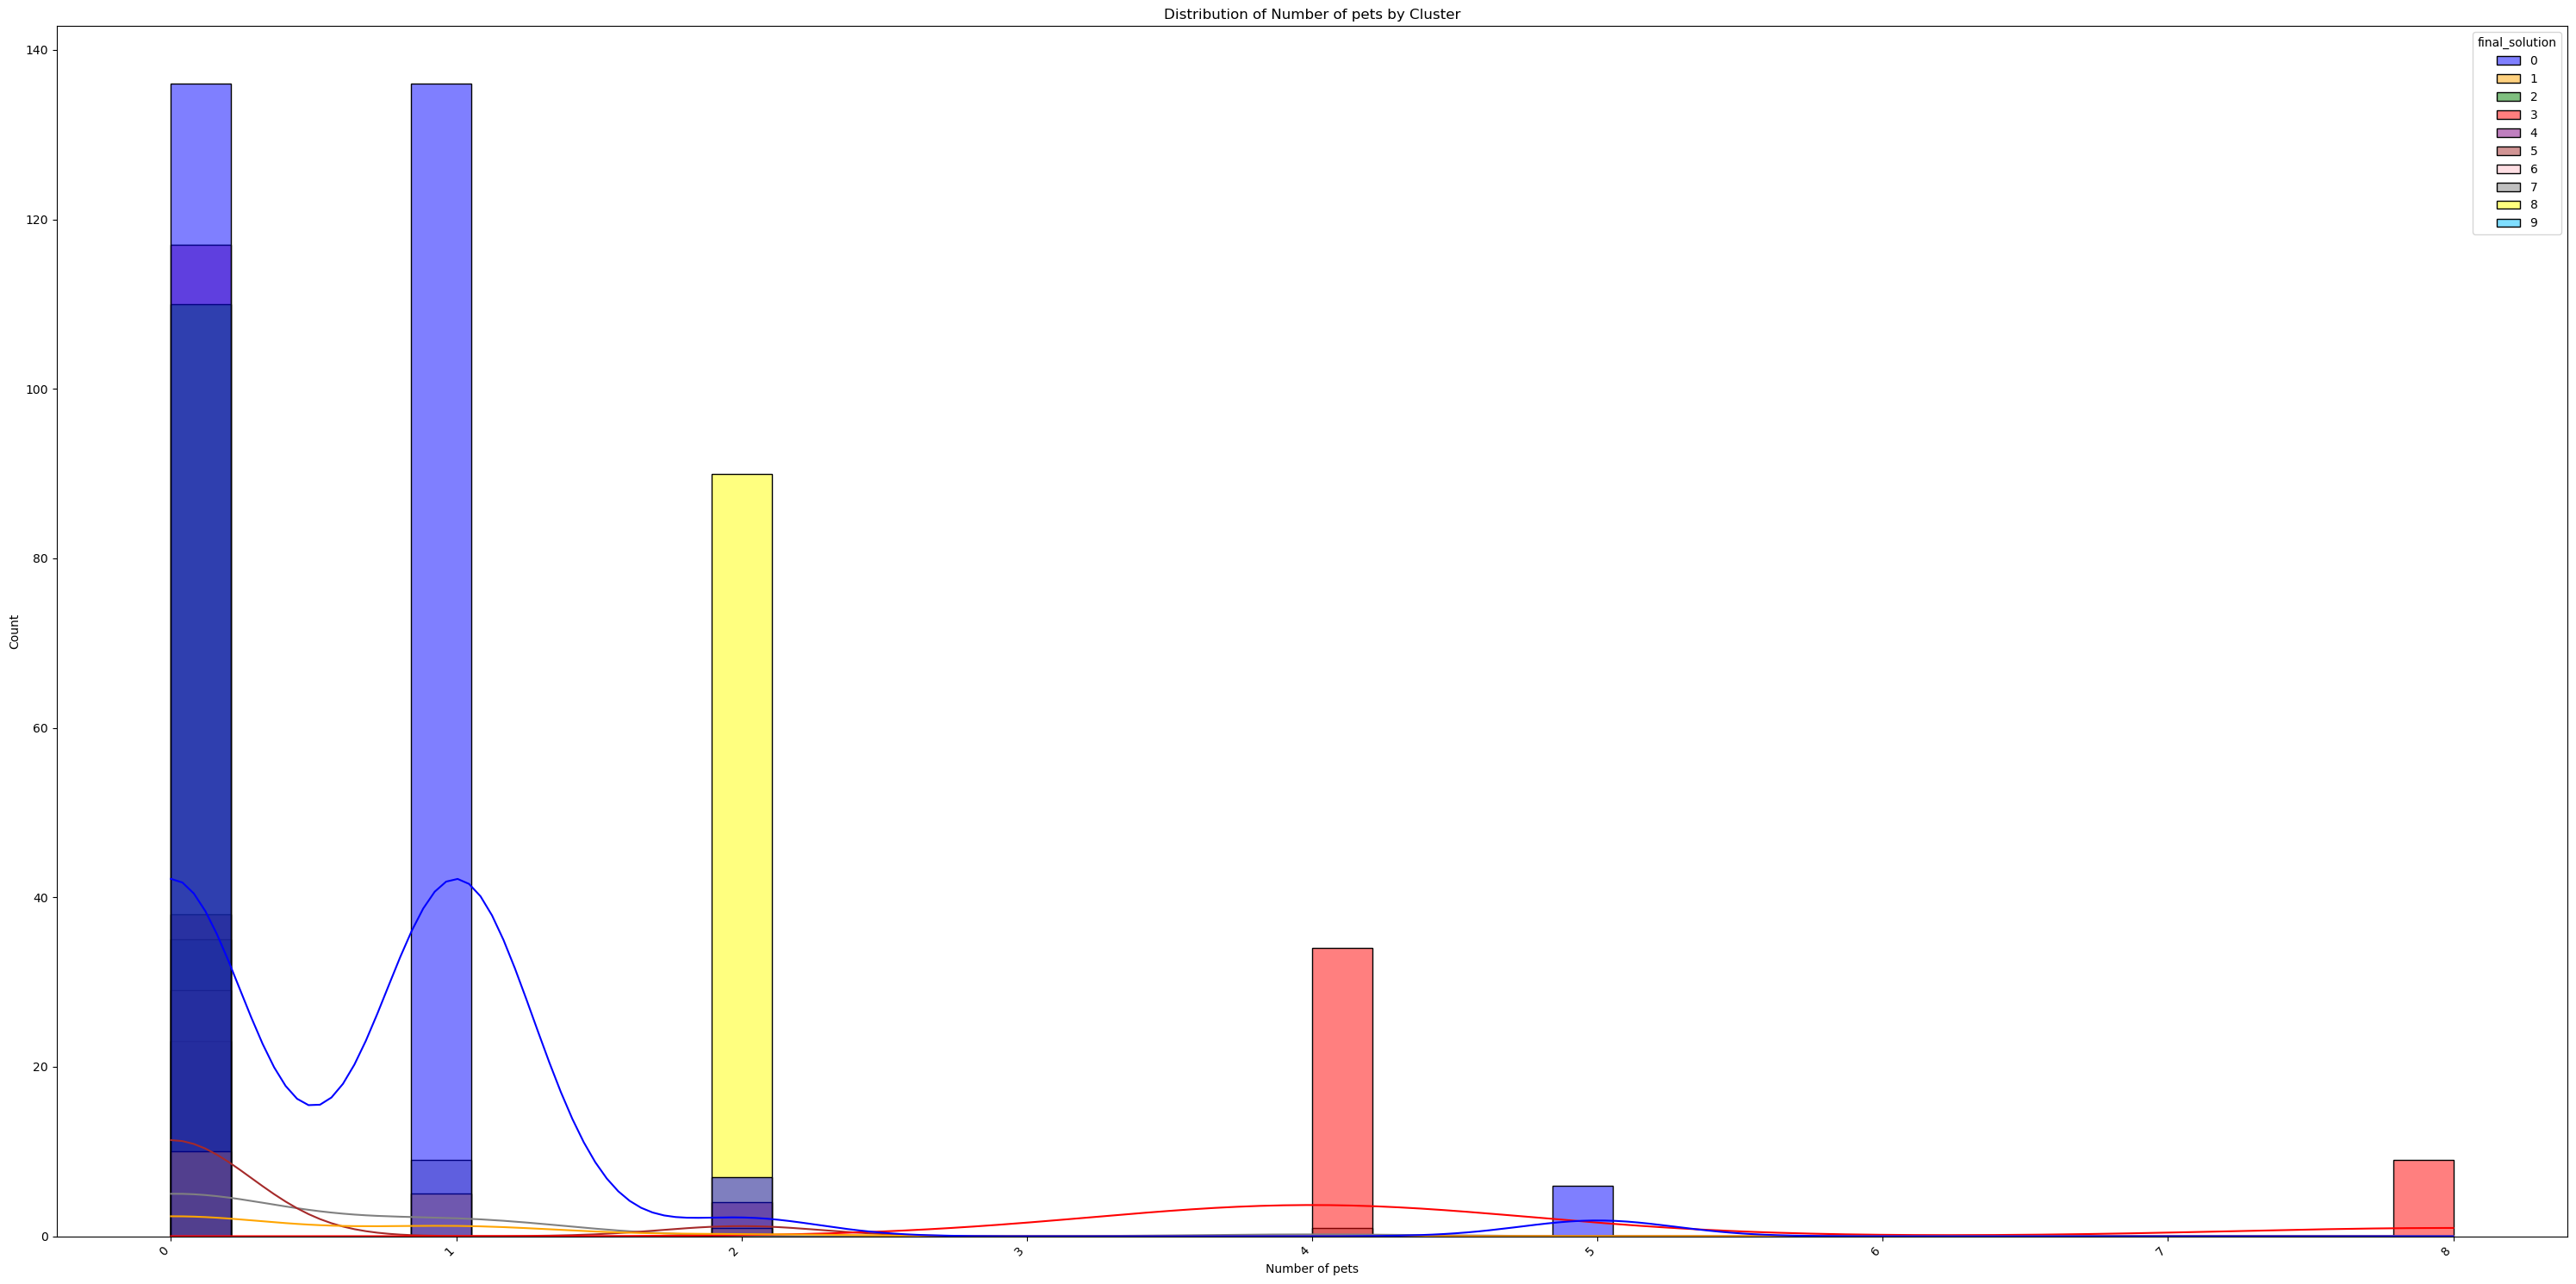

 67%|██████▋   | 10/15 [00:02<00:01,  3.68it/s]

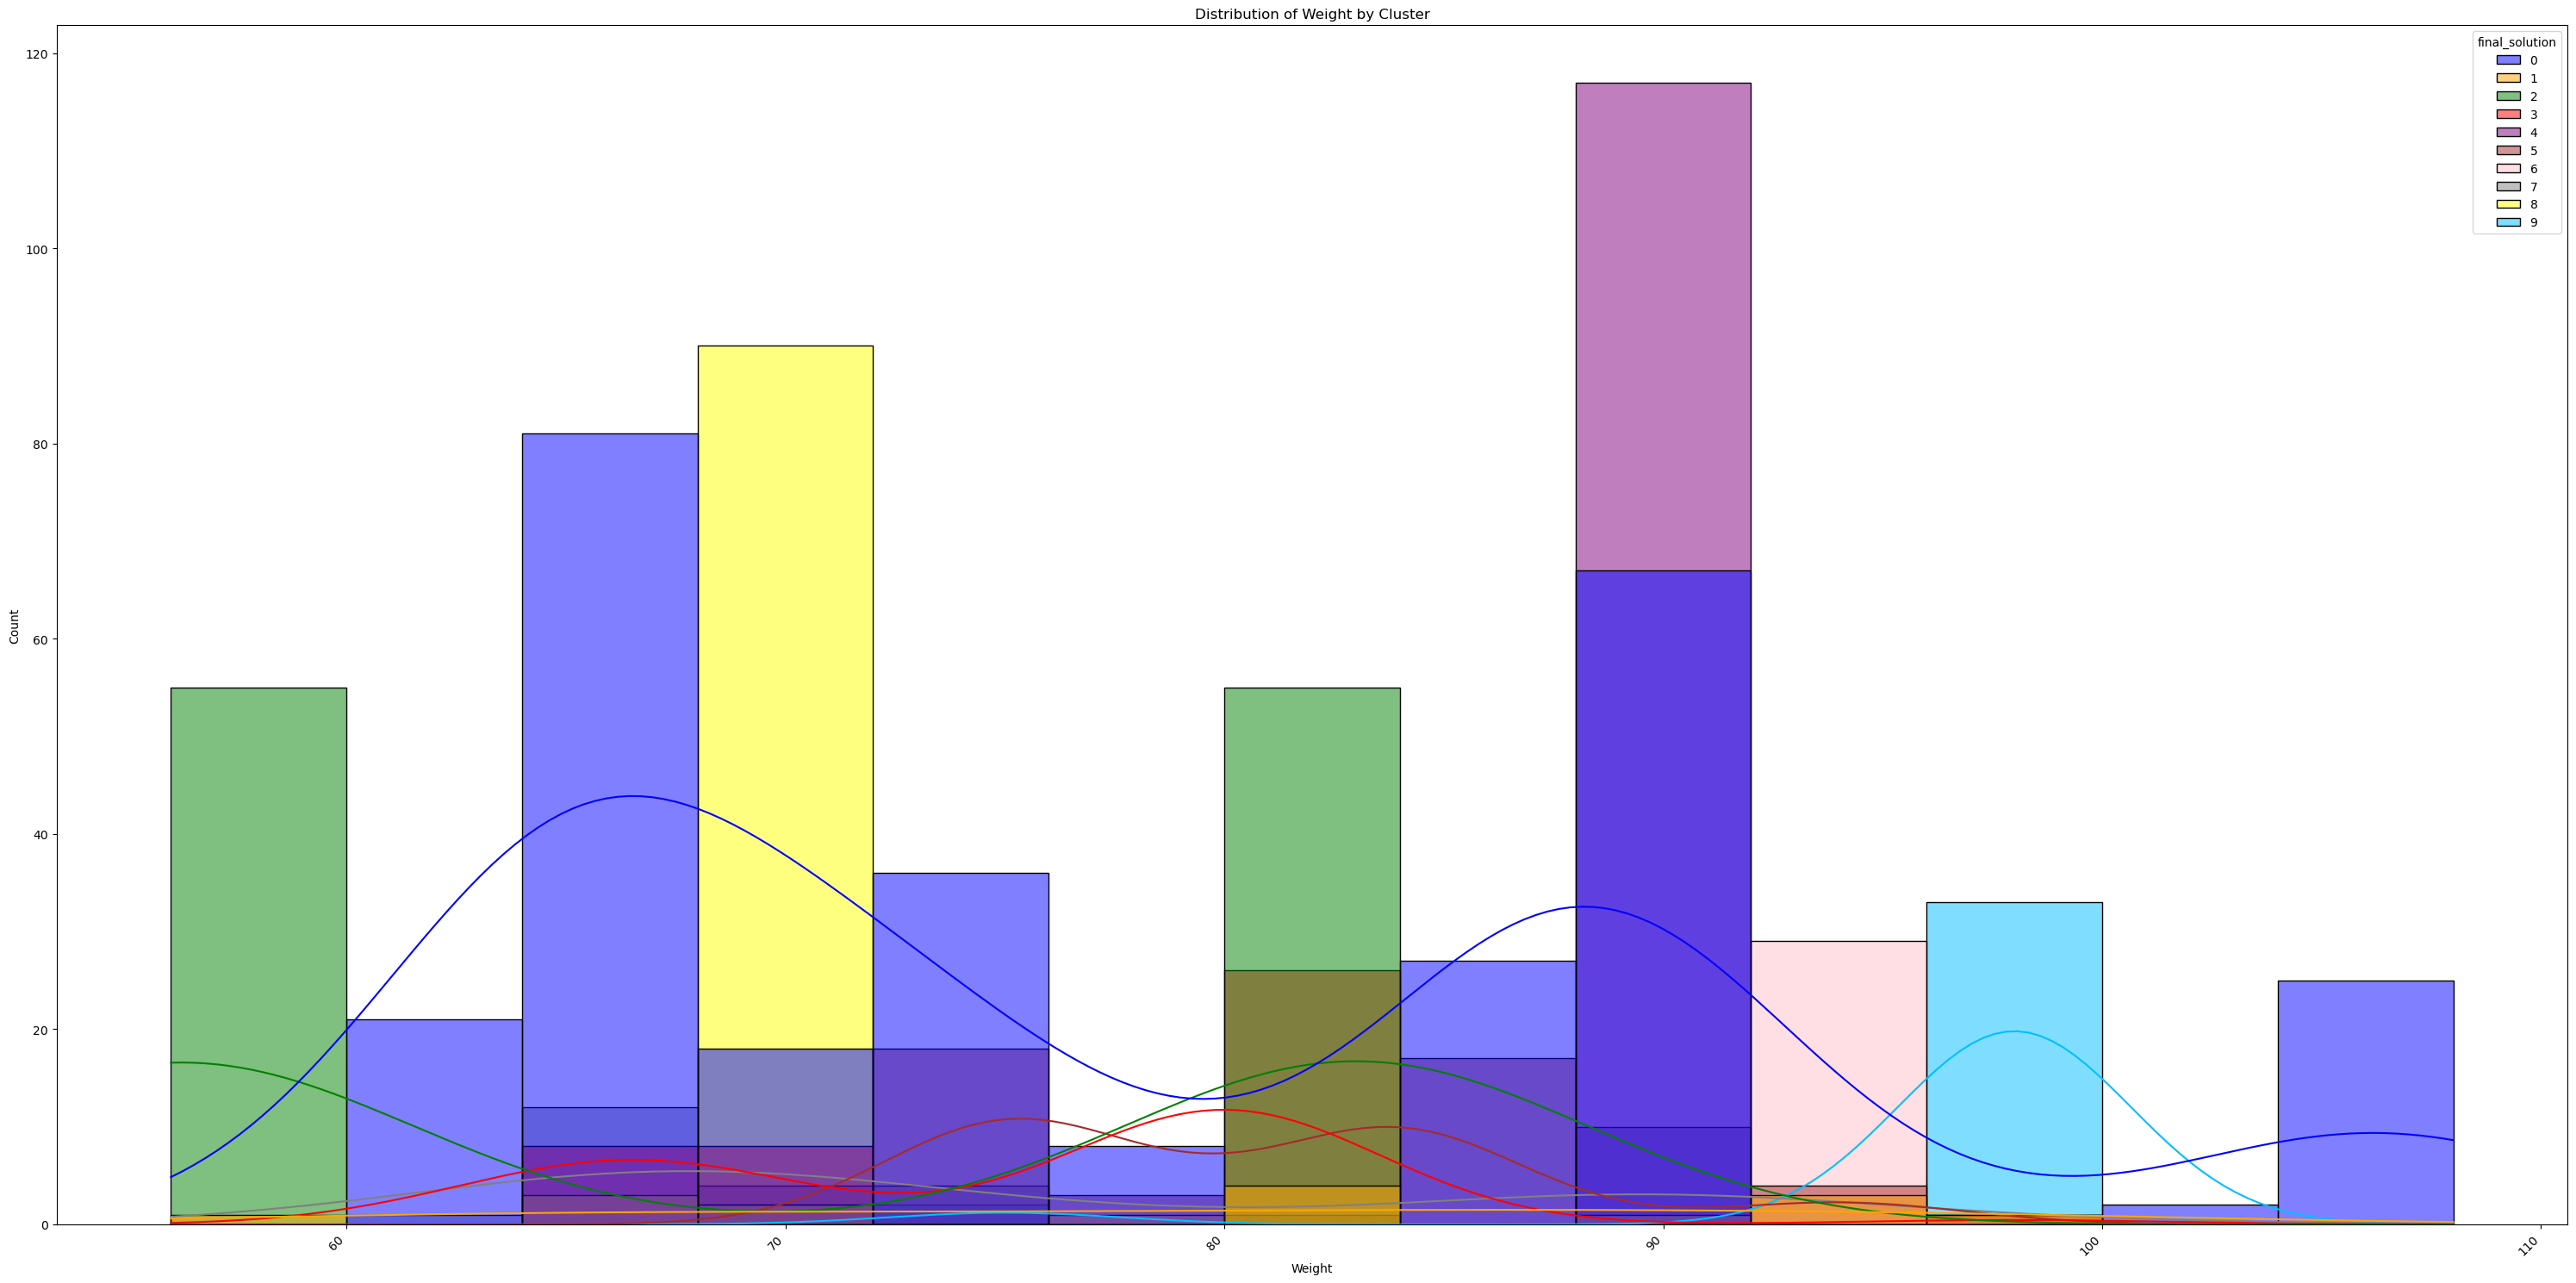

 73%|███████▎  | 11/15 [00:02<00:01,  3.85it/s]

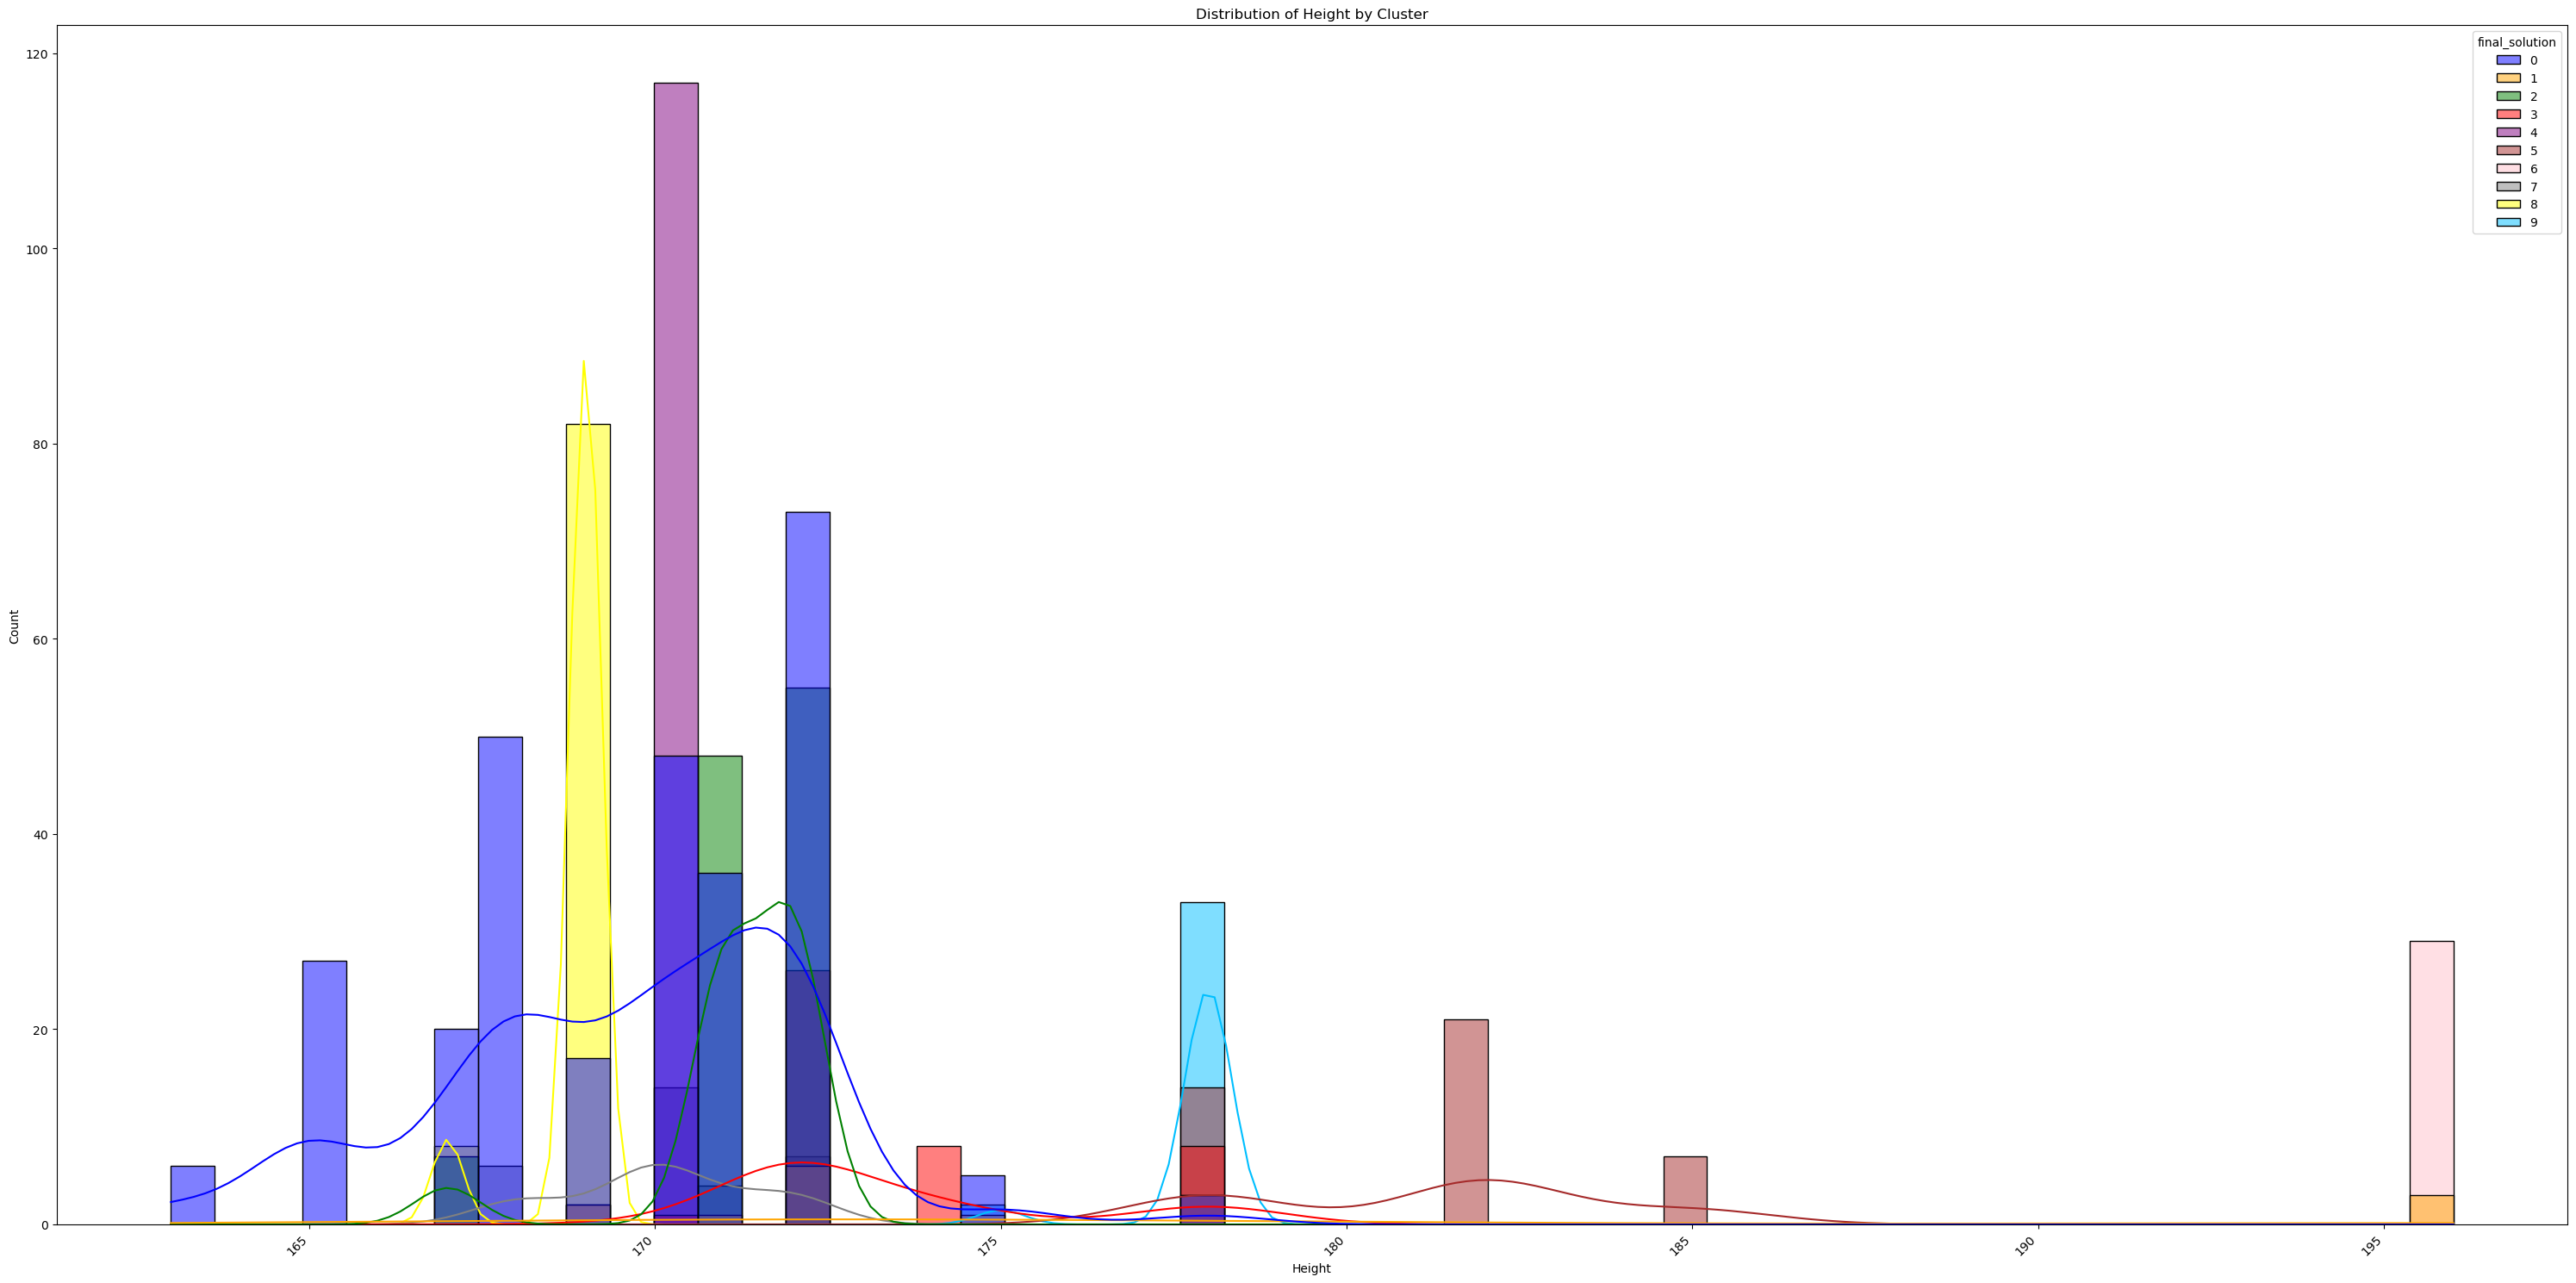

 80%|████████  | 12/15 [00:03<00:01,  2.83it/s]

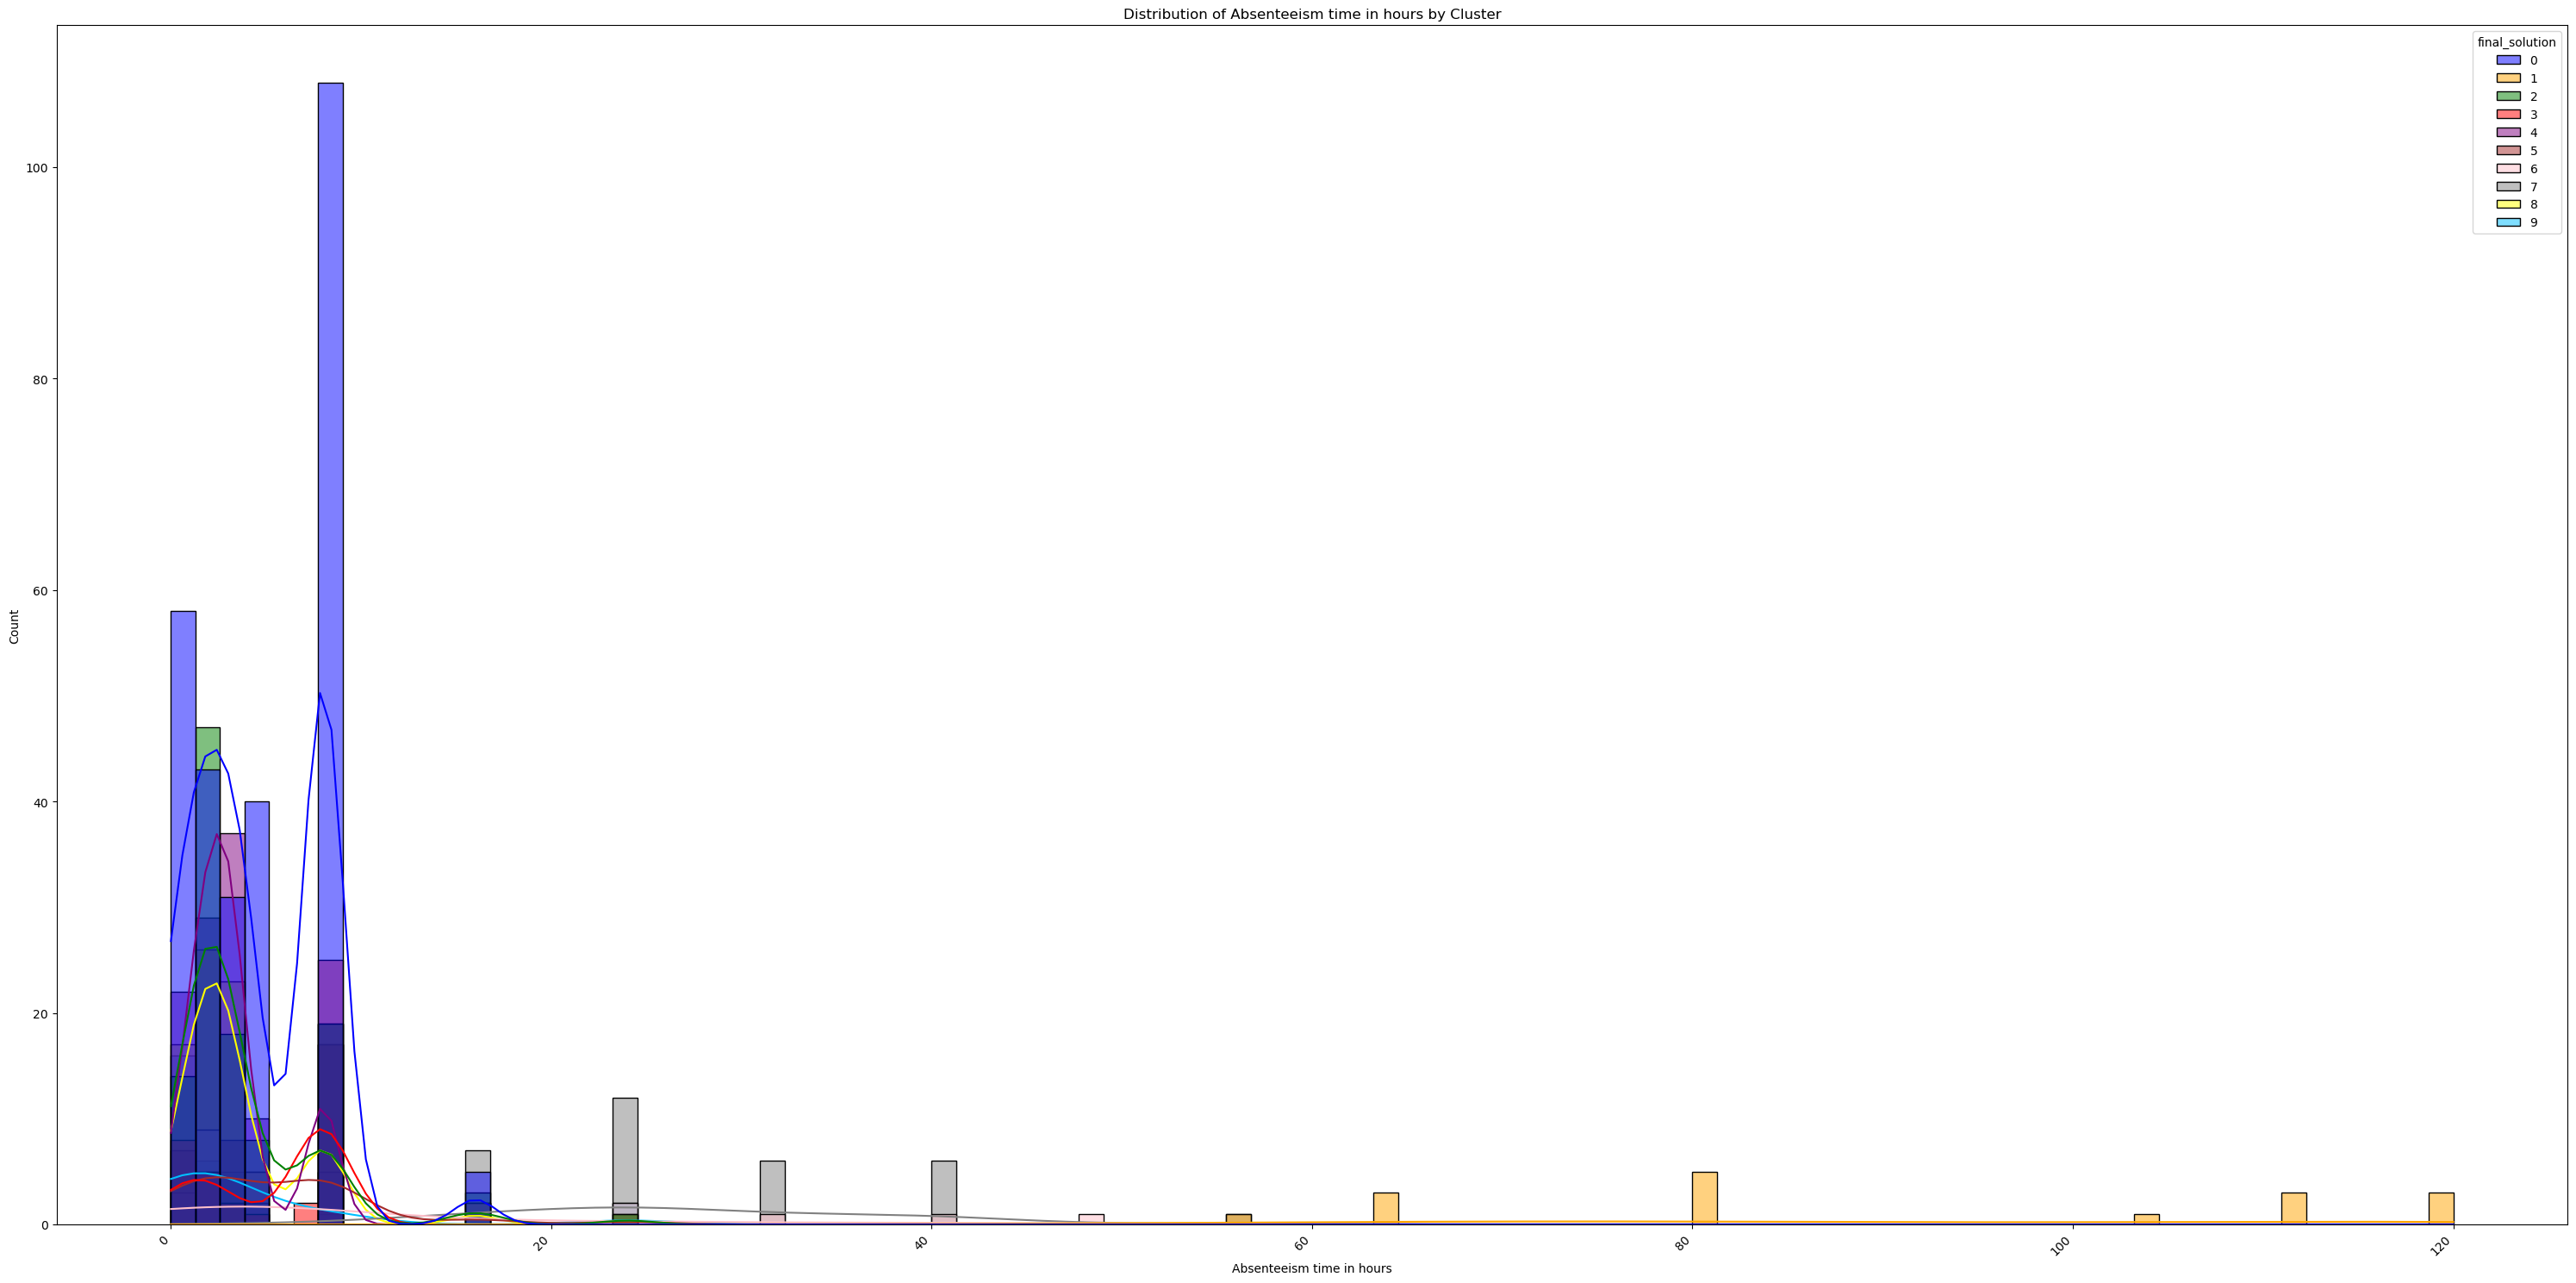

 87%|████████▋ | 13/15 [00:04<00:00,  2.31it/s]

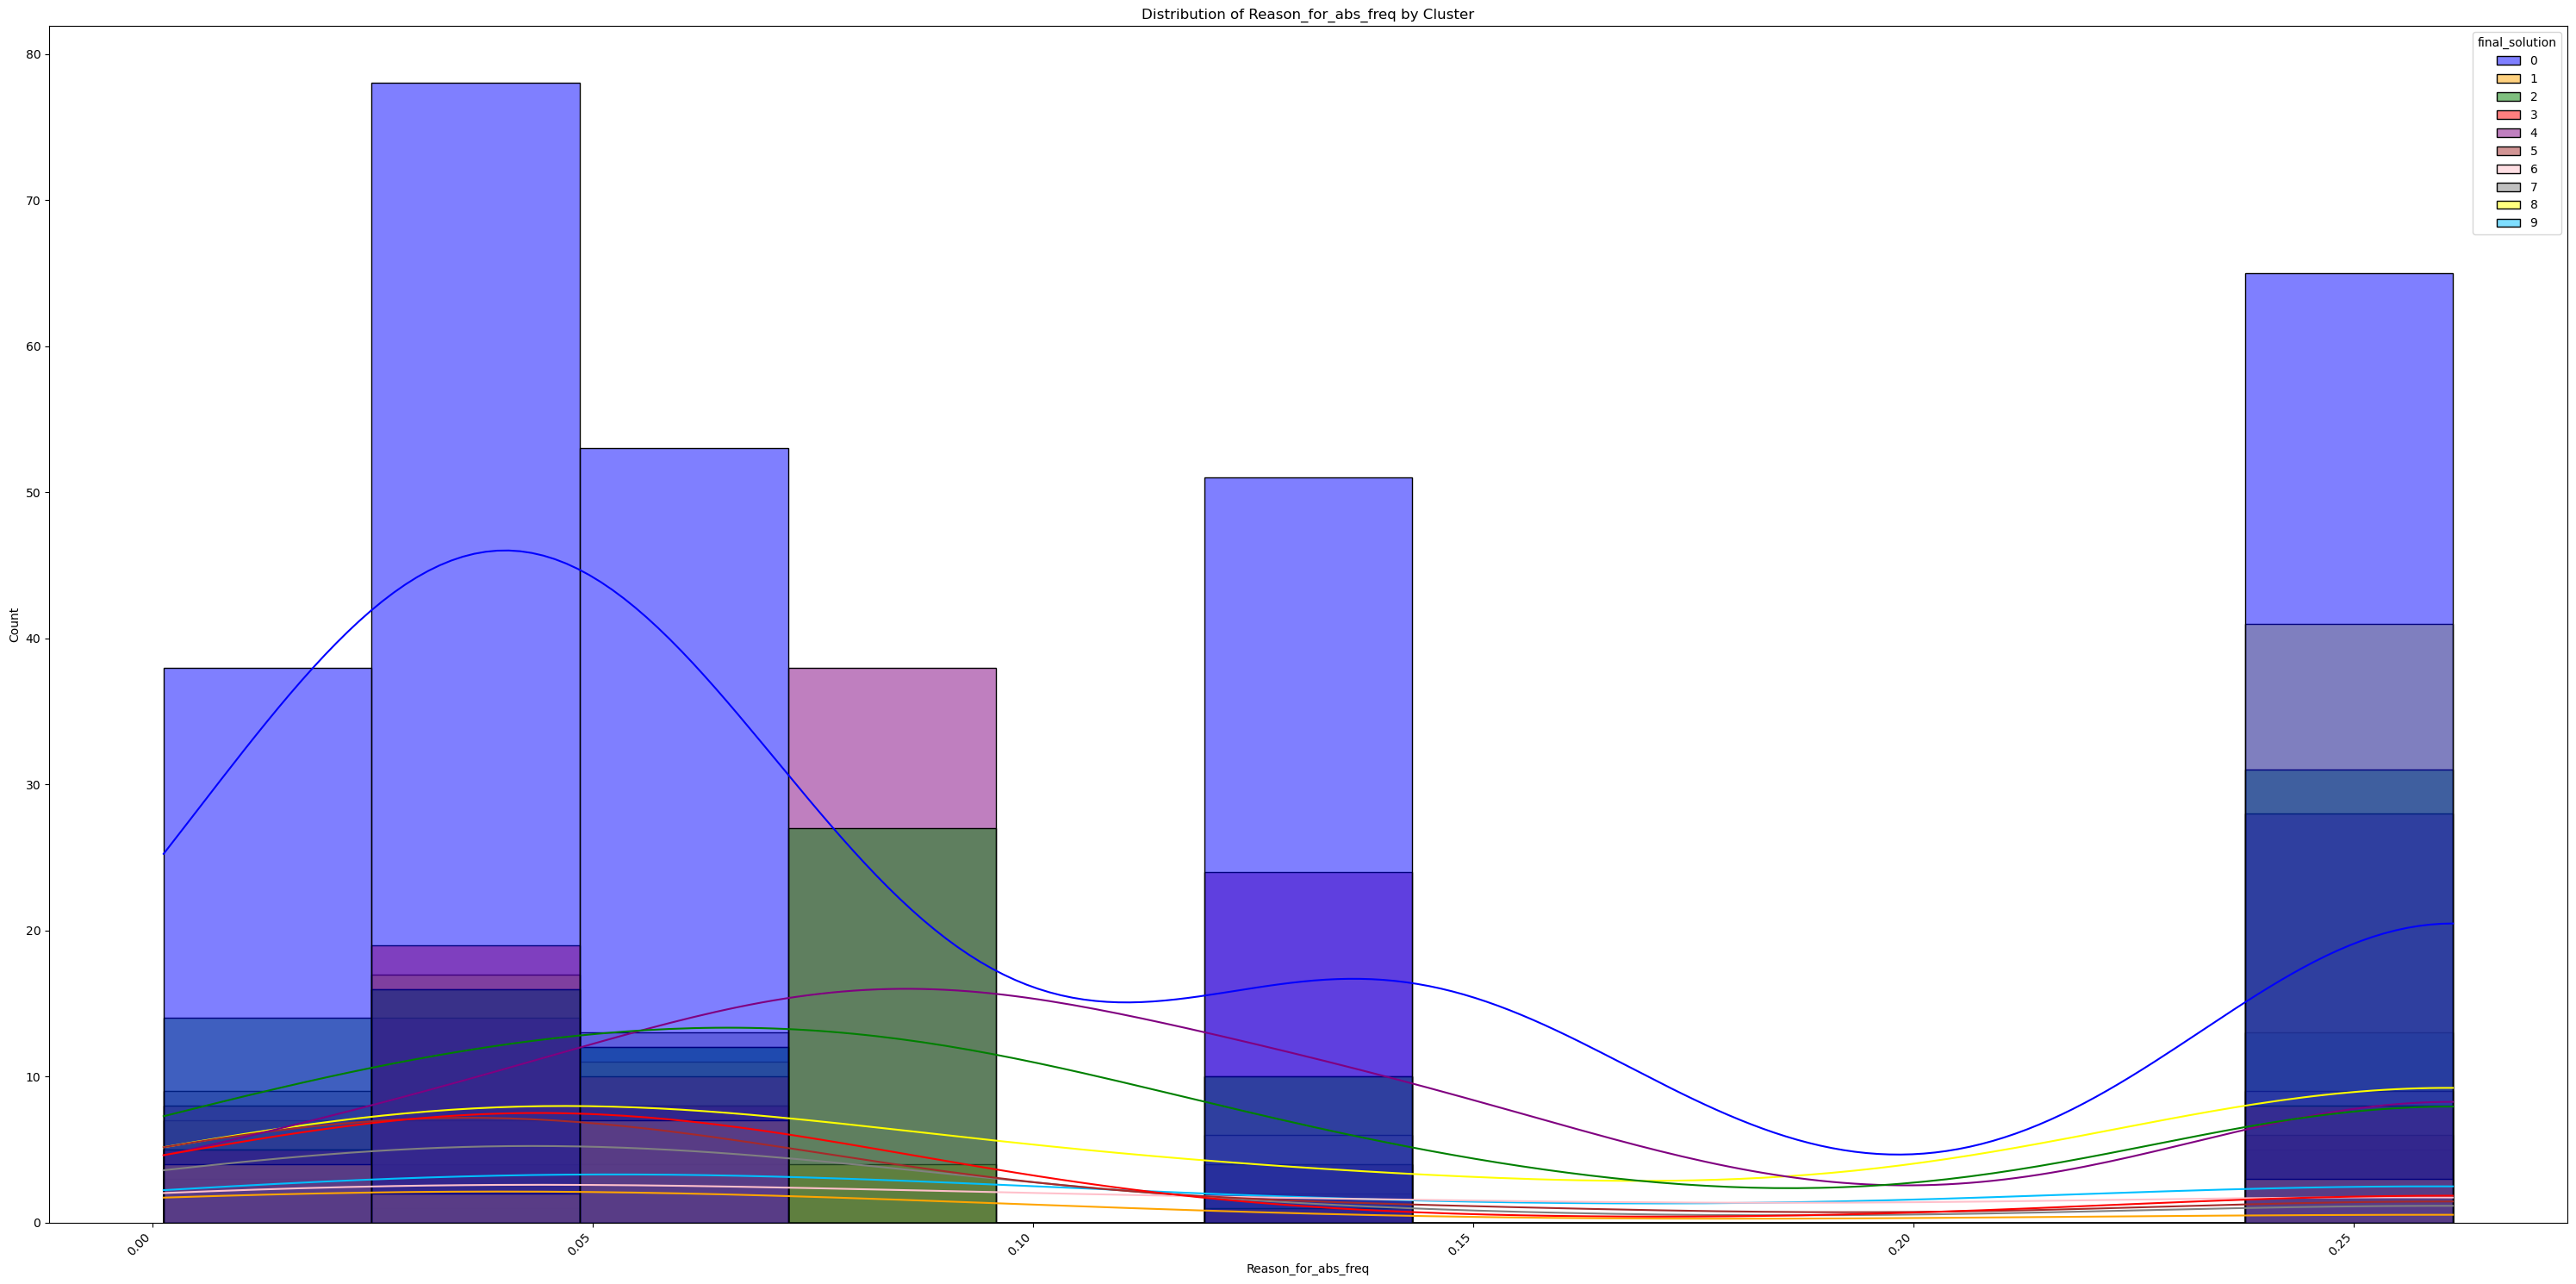

 93%|█████████▎| 14/15 [00:04<00:00,  2.67it/s]

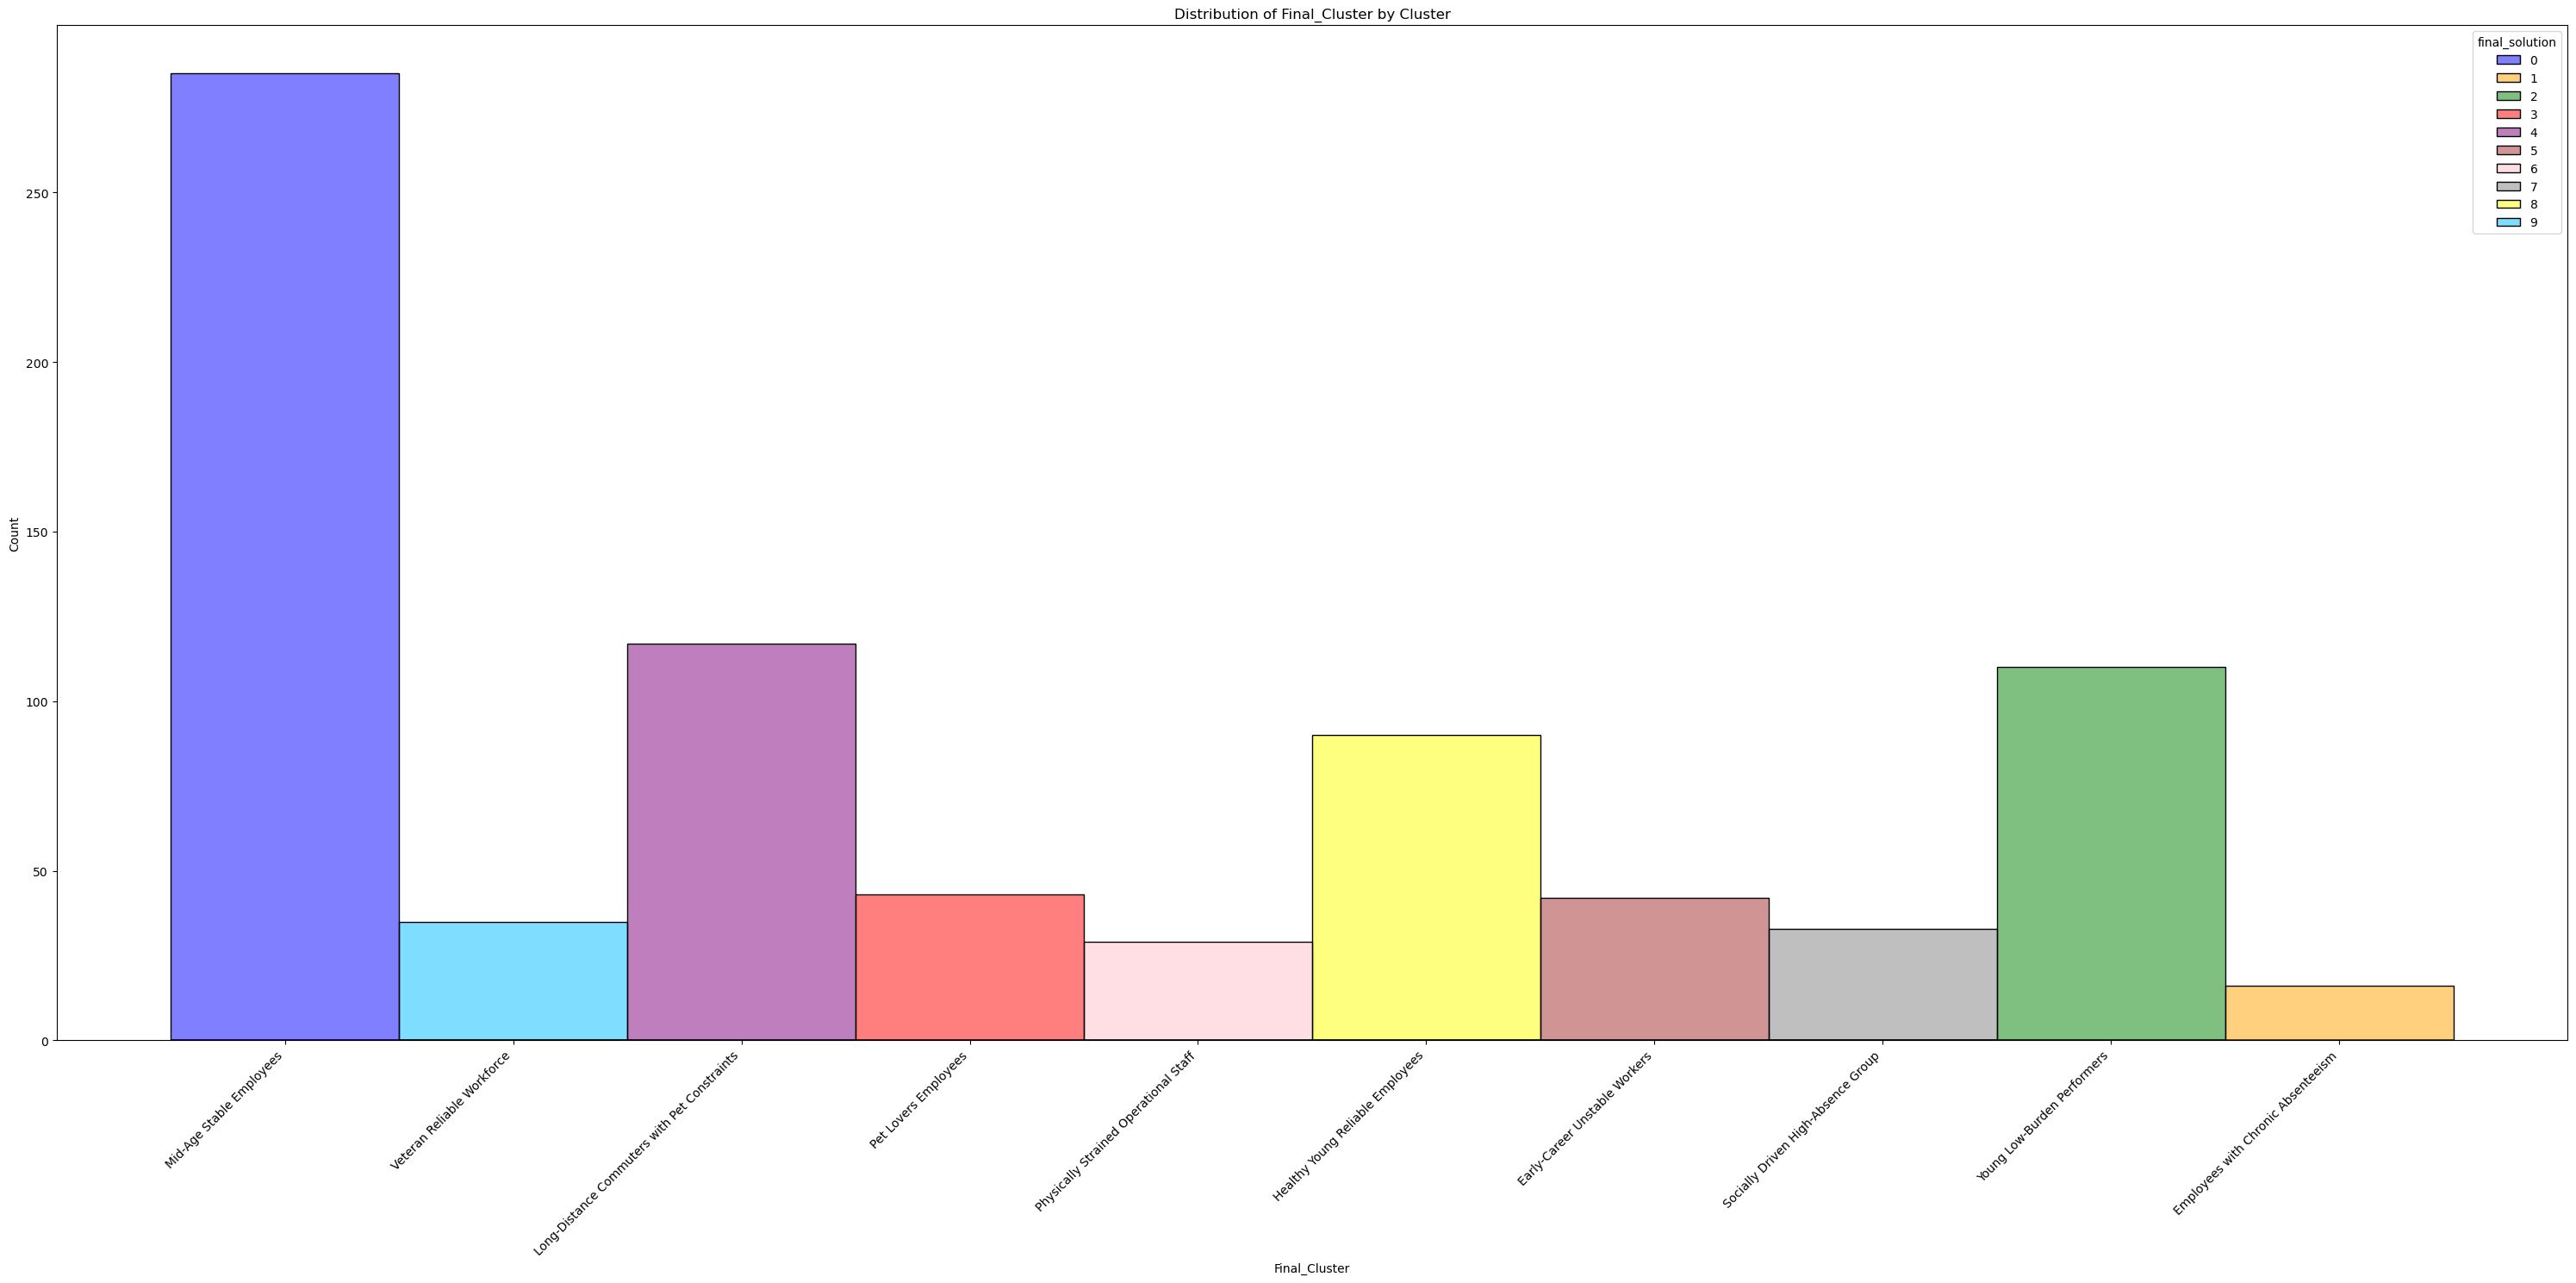

100%|██████████| 15/15 [00:04<00:00,  3.27it/s]


In [32]:
# Loop through all columns except numeric cluster labels
for col in tqdm(cols_to_plot):
    sns.histplot(
        data=worker.dropna(subset=[col]),
        x=col,
        hue='final_solution',
        kde=True,
        palette=cluster_colors,
        hue_order=sorted(cluster_colors.keys()),
        legend=True
    )

    plt.title(f"Distribution of {col} by Cluster")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()